In [ ]:
from pathlib import Path
import json
import urllib.request
import matplotlib.pyplot as plt

_TREBL_FIG_DIR = Path.cwd() / 'saved_figures'
_TREBL_FIG_DIR.mkdir(parents=True, exist_ok=True)


def _trebl_notebook_stem():
    try:
        import ipykernel

        connection_file = Path(ipykernel.get_connection_file()).name
        kernel_id = connection_file.split('-', 1)[1].split('.', 1)[0]

        try:
            from notebook import notebookapp

            servers = list(notebookapp.list_running_servers())
        except Exception:
            from jupyter_server import serverapp

            servers = list(serverapp.list_running_servers())

        for srv in servers:
            token = srv.get('token', '')
            api_url = f"{srv['url'].rstrip('/')}/api/sessions"
            if token:
                api_url = f"{api_url}?token={token}"

            with urllib.request.urlopen(api_url, timeout=2) as response:
                sessions = json.loads(response.read().decode('utf-8'))

            for sess in sessions:
                if sess.get('kernel', {}).get('id') == kernel_id:
                    notebook_path = sess.get('notebook', {}).get('path') or sess.get('path', '')
                    raw_stem = Path(notebook_path).stem or 'notebook'
                    safe_stem = ''.join(ch if (ch.isalnum() or ch in {'_', '-'}) else '_' for ch in raw_stem)
                    return safe_stem.strip('_') or 'notebook'
    except Exception:
        pass

    return 'notebook'


if not hasattr(plt, '_trebl_autosave_original_show'):
    plt._trebl_autosave_original_show = plt.show
    plt._trebl_autosave_counter = 1
    plt._trebl_notebook_stem = _trebl_notebook_stem()

    def _trebl_autosave_show(*args, **kwargs):
        for fig_num in plt.get_fignums():
            fig = plt.figure(fig_num)
            stem = f"{plt._trebl_notebook_stem}_figure_{plt._trebl_autosave_counter:04d}"
            fig.savefig(_TREBL_FIG_DIR / f'{stem}.png', dpi=300, bbox_inches='tight')
            fig.savefig(_TREBL_FIG_DIR / f'{stem}.pdf', dpi=300, bbox_inches='tight')
            plt._trebl_autosave_counter += 1
        return plt._trebl_autosave_original_show(*args, **kwargs)

    plt.show = _trebl_autosave_show


In [1]:
%load_ext autoreload
%autoreload 2
import speed_plotting_helpers
import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy
import seaborn as sns

# Exploring speed fits
1. Exponential (here)
2. Hill
3. Time first active

## Loading in activities

In [2]:
active_tile_activities_count_filtered = pd.read_csv("../../../output/ChopTFs_pipeline/speed/activities_to_fit.csv", index_col = 0)
active_tile_activities_count_filtered

,ADseq,time,activity,ci_low,ci_hi,class,mean_diff,pval_fdr,error,activity_norm,ci_low_norm,ci_hi_norm
142,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,0,-0.402631,-0.569555,-0.165864,ns,NaN,NaN,0.102982,0.000000,-0.166925,0.236767
143,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,2,0.067719,-0.086268,0.196101,ns,0.470349,0.009113,0.072033,0.470349,0.316362,0.598732
144,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,10,0.423909,0.019486,0.796737,activator,0.826539,0.001168,0.198278,0.826539,0.422117,1.199367
145,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,15,0.786642,0.691610,0.871152,activator,1.189273,0.000881,0.045801,1.189273,1.094241,1.273783
146,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,20,0.567249,0.388742,0.736468,activator,0.969880,0.000730,0.088706,0.969880,0.791373,1.139099
...,...,...,...,...,...,...,...,...,...,...,...,...
118600,YVPTRNTFNYDVKISNDFFDNGDNLYGNDEEVLFYEDNYN,20,1.560700,1.399946,1.635293,activator,1.430020,0.000730,0.060037,1.430020,1.269266,1.504612
118601,YVPTRNTFNYDVKISNDFFDNGDNLYGNDEEVLFYEDNYN,30,1.707046,1.668821,1.736109,activator,1.576366,0.000621,0.017165,1.576366,1.538140,1.605428
118602,YVPTRNTFNYDVKISNDFFDNGDNLYGNDEEVLFYEDNYN,40,1.721909,1.702173,1.740391,activator,1.591228,0.000550,0.009749,1.591228,1.571493,1.609710
118603,YVPTRNTFNYDVKISNDFFDNGDNLYGNDEEVLFYEDNYN,50,1.650853,1.592250,1.699947,activator,1.520173,0.000548,0.027474,1.520173,1.461570,1.569266


## Trying exponential fit

In [3]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
from tqdm import tqdm

def rising_exponential(t, A, k, C):
    """Rising exponential: A*(1-exp(-k*t)) + C"""
    return A * (1 - np.exp(-k * t)) + C

def fit_rising_exponentials(df, time_col="time", activity_col="activity", error_col="error",
                            min_points=4, subtract_baseline=True, verbose=True):
    """
    Fit a rising exponential to each ADseq in the DataFrame and return fit metrics including R².
    """
    results = []
    grouped = df.groupby("ADseq")
    iterator = grouped.items() if not verbose else tqdm(grouped, desc="Fitting")
    
    for adseq, grp in iterator:
        grp = grp.sort_values(time_col)
        
        t = grp[time_col].values
        y = grp[activity_col].values
        sigma = grp[error_col].values if error_col in grp else None

        # subtract baseline if requested
        if subtract_baseline:
            baseline = y[0]
            y = y - baseline
            y = np.clip(y, 0, None)
        
        if len(t) < min_points:
            results.append({
                "ADseq": adseq,
                "A": np.nan, "k": np.nan, "C": np.nan,
                "t_half": np.nan, "t_half_obsmax": np.nan,
                "r_squared": np.nan,
                "flag": "too_few_points"
            })
            continue

        # initial guesses
        C0 = 0 if subtract_baseline else y[0]
        A0 = y[-1] - C0
        k0 = 1 / (t[-1] / 2 if t[-1] != 0 else 1)

        try:
            popt, pcov = curve_fit(
                rising_exponential, t, y,
                p0=[A0, k0, C0],
                sigma=sigma,
                absolute_sigma=True if sigma is not None else False,
                bounds=([0, 0, -np.inf], [np.inf, np.inf, np.inf]),
                maxfev=10000
            )
            perr = np.sqrt(np.diag(pcov))

            A, k, C = popt
            A_err, k_err, C_err = perr

            # half-life
            t_half = np.log(2) / k
            t_half_err = np.log(2) / (k ** 2) * k_err

            # --- model-interpolated half-life (50% of observed max) ---
            t_grid = np.linspace(t.min(), t.max(), 500)
            y_model = rising_exponential(t_grid, A, k, C)
            
            obs_max = np.max(y_model)  # <-- was np.max(y)
            threshold = 0.5 * obs_max
            
            idx = np.argmin(np.abs(y_model - threshold))
            t_half_model_empirical = t_grid[idx]
            
            # dense time grid for smooth inversion
            t_grid = np.linspace(t.min(), t.max(), 500)
            
            y_model = rising_exponential(t_grid, A, k, C)
            

            # compute R²
            y_fit = rising_exponential(t, A, k, C)
            ss_res = np.sum((y - y_fit) ** 2)
            ss_tot = np.sum((y - np.mean(y)) ** 2)
            r_squared = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan

            results.append({
                "ADseq": adseq,
                "A": A, "A_err": A_err,
                "k": k, "k_err": k_err,
                "C": C, "C_err": C_err,
                "t_half": t_half,
                "t_half_err": t_half_err,
                "obs_max": obs_max,
                "t_half_model_empirical": t_half_model_empirical,
                "r_squared": r_squared,
                "flag": "ok"
            })

        except Exception as e:
            results.append({
                "ADseq": adseq,
                "A": np.nan, "k": np.nan, "C": np.nan,
                "t_half": np.nan, "t_half_obsmax": np.nan,
                "r_squared": np.nan,
                "flag": f"fit_error: {e}"
            })

    return pd.DataFrame(results)

In [4]:
fit_results = fit_rising_exponentials(
    active_tile_activities_count_filtered,
    time_col="time",
    activity_col="activity",
    error_col="error",
    min_points=5,
    subtract_baseline=False,
    verbose=True
)

print(fit_results['flag'].value_counts())

Fitting: 100%|██████████| 857/857 [00:03<00:00, 232.81it/s]

ok    857
Name: flag, dtype: int64


In [5]:
fit_results

,ADseq,A,A_err,k,k_err,C,C_err,t_half,t_half_err,obs_max,t_half_model_empirical,r_squared,flag
0,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,1.156830,0.101060,0.269285,0.069876,-0.408963,0.100999,2.574025,0.667927,0.747866,4.208417,0.924506,ok
1,AASNSYAIPENELLDEDTMNFISSLKNDLSNISNSLPFEY,1.629568,0.079913,0.132274,0.015466,0.342460,0.078549,5.240241,0.612717,1.971445,3.847695,0.988783,ok
2,AAVPQQNIAPPFLNTNSSATDSNPNTNLEDSLFFDHDLLS,1.533139,0.098494,0.128593,0.012426,-0.266570,0.100362,5.390225,0.520850,1.265886,6.853707,0.983280,ok
3,AELHNWEPPLYDSVGNHNHAGTMESHPHTNIHEELKEFLS,1.098801,0.101313,0.096377,0.021066,0.055955,0.096084,7.192037,1.572054,1.151371,6.613226,0.955792,ok
4,AELPRRFMDLESWRIETYNELERWFQVDVPKNFEMMNCKF,1.508101,0.108744,0.117486,0.022559,0.037501,0.095994,5.899836,1.132839,1.544293,5.651303,0.954109,ok
...,...,...,...,...,...,...,...,...,...,...,...,...,...
852,YNFQNARLLIRKIWQNEADGISEHDLVHMIDELDYNINFA,1.563304,0.073382,0.093508,0.008916,-0.208122,0.073789,7.412734,0.706836,1.349461,8.897796,0.966920,ok
853,YPQDLVSSPAMSHLTANNDDFDDLLSVASMNSNYLLPVNS,1.120782,0.082873,0.080102,0.017744,0.010666,0.080531,8.653300,1.916833,1.122281,8.416834,0.969677,ok
854,YSLVTGKQPLIPHEMTSCLFPKDVVGLGVDDSMDCFTLIN,1.598856,0.100220,0.111316,0.014868,-0.181693,0.102116,6.226831,0.831686,1.415154,7.334669,0.977314,ok
855,YSNARGSDPSSYAIEGEYKTLATDDLGNILNLNYGETNEV,1.245690,0.098534,0.084823,0.012658,0.000967,0.104688,8.171657,1.219457,1.238982,8.056112,0.970036,ok


## Filtering to reasonable fits and plotting

In [15]:
fit_results["A+C"] = fit_results["A"] + fit_results["C"]
fit_results["A*k"] = fit_results["A"] * fit_results["k"]
fit_results["1/k"] = 1 / fit_results["k"]
fit_results

,ADseq,A,A_err,k,k_err,C,C_err,t_half,t_half_err,obs_max,t_half_model_empirical,r_squared,flag,A+C,A*k,1/k
0,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,1.156830,0.101060,0.269285,0.069876,-0.408963,0.100999,2.574025,0.667927,0.747866,4.208417,0.924506,ok,0.747866,0.311517,3.713533
1,AASNSYAIPENELLDEDTMNFISSLKNDLSNISNSLPFEY,1.629568,0.079913,0.132274,0.015466,0.342460,0.078549,5.240241,0.612717,1.971445,3.847695,0.988783,ok,1.972028,0.215549,7.560070
2,AAVPQQNIAPPFLNTNSSATDSNPNTNLEDSLFFDHDLLS,1.533139,0.098494,0.128593,0.012426,-0.266570,0.100362,5.390225,0.520850,1.265886,6.853707,0.983280,ok,1.266569,0.197152,7.776451
3,AELHNWEPPLYDSVGNHNHAGTMESHPHTNIHEELKEFLS,1.098801,0.101313,0.096377,0.021066,0.055955,0.096084,7.192037,1.572054,1.151371,6.613226,0.955792,ok,1.154756,0.105899,10.375916
4,AELPRRFMDLESWRIETYNELERWFQVDVPKNFEMMNCKF,1.508101,0.108744,0.117486,0.022559,0.037501,0.095994,5.899836,1.132839,1.544293,5.651303,0.954109,ok,1.545602,0.177181,8.511664
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
852,YNFQNARLLIRKIWQNEADGISEHDLVHMIDELDYNINFA,1.563304,0.073382,0.093508,0.008916,-0.208122,0.073789,7.412734,0.706836,1.349461,8.897796,0.966920,ok,1.355182,0.146181,10.694315
853,YPQDLVSSPAMSHLTANNDDFDDLLSVASMNSNYLLPVNS,1.120782,0.082873,0.080102,0.017744,0.010666,0.080531,8.653300,1.916833,1.122281,8.416834,0.969677,ok,1.131448,0.089777,12.484073
854,YSLVTGKQPLIPHEMTSCLFPKDVVGLGVDDSMDCFTLIN,1.598856,0.100220,0.111316,0.014868,-0.181693,0.102116,6.226831,0.831686,1.415154,7.334669,0.977314,ok,1.417164,0.177979,8.983418
855,YSNARGSDPSSYAIEGEYKTLATDDLGNILNLNYGETNEV,1.245690,0.098534,0.084823,0.012658,0.000967,0.104688,8.171657,1.219457,1.238982,8.056112,0.970036,ok,1.246658,0.105664,11.789209


In [16]:
#max_time = activities['time'].max()

ok = fit_results[
    (fit_results['flag'] == 'ok') &
    (fit_results["A_err"] < fit_results["A"]) &
    (fit_results["k_err"].astype(float) < fit_results["k"]) &
    (fit_results['r_squared'] > 0.7) & 
    (fit_results["A+C"] < 2 * fit_results["obs_max"])
].copy()

print(f"Keeping {len(ok)} / {len(fit_results)} sequences ({100*len(ok)/len(fit_results):.1f}%)")

Keeping 852 / 857 sequences (99.4%)


In [17]:
ok.to_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/ChopTFs_pipeline/speed/exponential_fit.csv")

In [18]:
not_ok = fit_results[~fit_results["ADseq"].isin(ok["ADseq"])]
not_ok

,ADseq,A,A_err,k,k_err,C,C_err,t_half,t_half_err,obs_max,t_half_model_empirical,r_squared,flag,A+C,A*k,1/k
18,ALDRKSSKKLLPLKYFLEQDELIFCLCLEYFERSLFSTMY,1451.271602,6.446200e+06,0.000006,0.026388,-0.007407,0.099352,116697.163395,5.184379e+08,0.509709,30.420842,0.733637,ok,1451.264195,0.008620,168358.418916
63,DDLDKNSEPNGYMCPICLTKYTQLEAVQLLNFDRTEFLCS,1.274008,8.150130e-01,0.022438,0.024394,-0.010079,0.105739,30.892218,3.358618e+01,0.932417,20.921844,0.906432,ok,1.263930,0.028586,44.568050
314,ILNEYNMNFNDNLGTSTSGKNKSACPSSFDANAMTKINPS,0.758350,5.694393e-01,0.028479,0.045705,-0.018371,0.139471,24.339028,3.906076e+01,0.602645,19.238477,0.284402,ok,0.739979,0.021597,35.113795
589,QKTMCRELGLLDESDWQPDPLIKQICRFLPSYNKALSILD,1.416404,2.078532e+00,0.010295,0.020403,0.027268,0.088021,67.326778,1.334251e+02,0.679983,24.288577,0.816765,ok,1.443672,0.014582,97.132009
810,VKEVYNPEDLYHLRILNSLTACYLEYSISYGDIREQDDML,2.003100,1.430729e+00,0.011327,0.011967,-0.222372,0.087019,61.196787,6.465639e+01,0.765509,31.743487,0.905020,ok,1.780728,0.022688,88.288301


In [19]:
active_tile_activities_count_filtered

,ADseq,time,activity,ci_low,ci_hi,class,mean_diff,pval_fdr,error,activity_norm,ci_low_norm,ci_hi_norm
142,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,0,-0.402631,-0.569555,-0.165864,ns,NaN,NaN,0.102982,0.000000,-0.166925,0.236767
143,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,2,0.067719,-0.086268,0.196101,ns,0.470349,0.009113,0.072033,0.470349,0.316362,0.598732
144,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,10,0.423909,0.019486,0.796737,activator,0.826539,0.001168,0.198278,0.826539,0.422117,1.199367
145,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,15,0.786642,0.691610,0.871152,activator,1.189273,0.000881,0.045801,1.189273,1.094241,1.273783
146,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,20,0.567249,0.388742,0.736468,activator,0.969880,0.000730,0.088706,0.969880,0.791373,1.139099
...,...,...,...,...,...,...,...,...,...,...,...,...
118600,YVPTRNTFNYDVKISNDFFDNGDNLYGNDEEVLFYEDNYN,20,1.560700,1.399946,1.635293,activator,1.430020,0.000730,0.060037,1.430020,1.269266,1.504612
118601,YVPTRNTFNYDVKISNDFFDNGDNLYGNDEEVLFYEDNYN,30,1.707046,1.668821,1.736109,activator,1.576366,0.000621,0.017165,1.576366,1.538140,1.605428
118602,YVPTRNTFNYDVKISNDFFDNGDNLYGNDEEVLFYEDNYN,40,1.721909,1.702173,1.740391,activator,1.591228,0.000550,0.009749,1.591228,1.571493,1.609710
118603,YVPTRNTFNYDVKISNDFFDNGDNLYGNDEEVLFYEDNYN,50,1.650853,1.592250,1.699947,activator,1.520173,0.000548,0.027474,1.520173,1.461570,1.569266


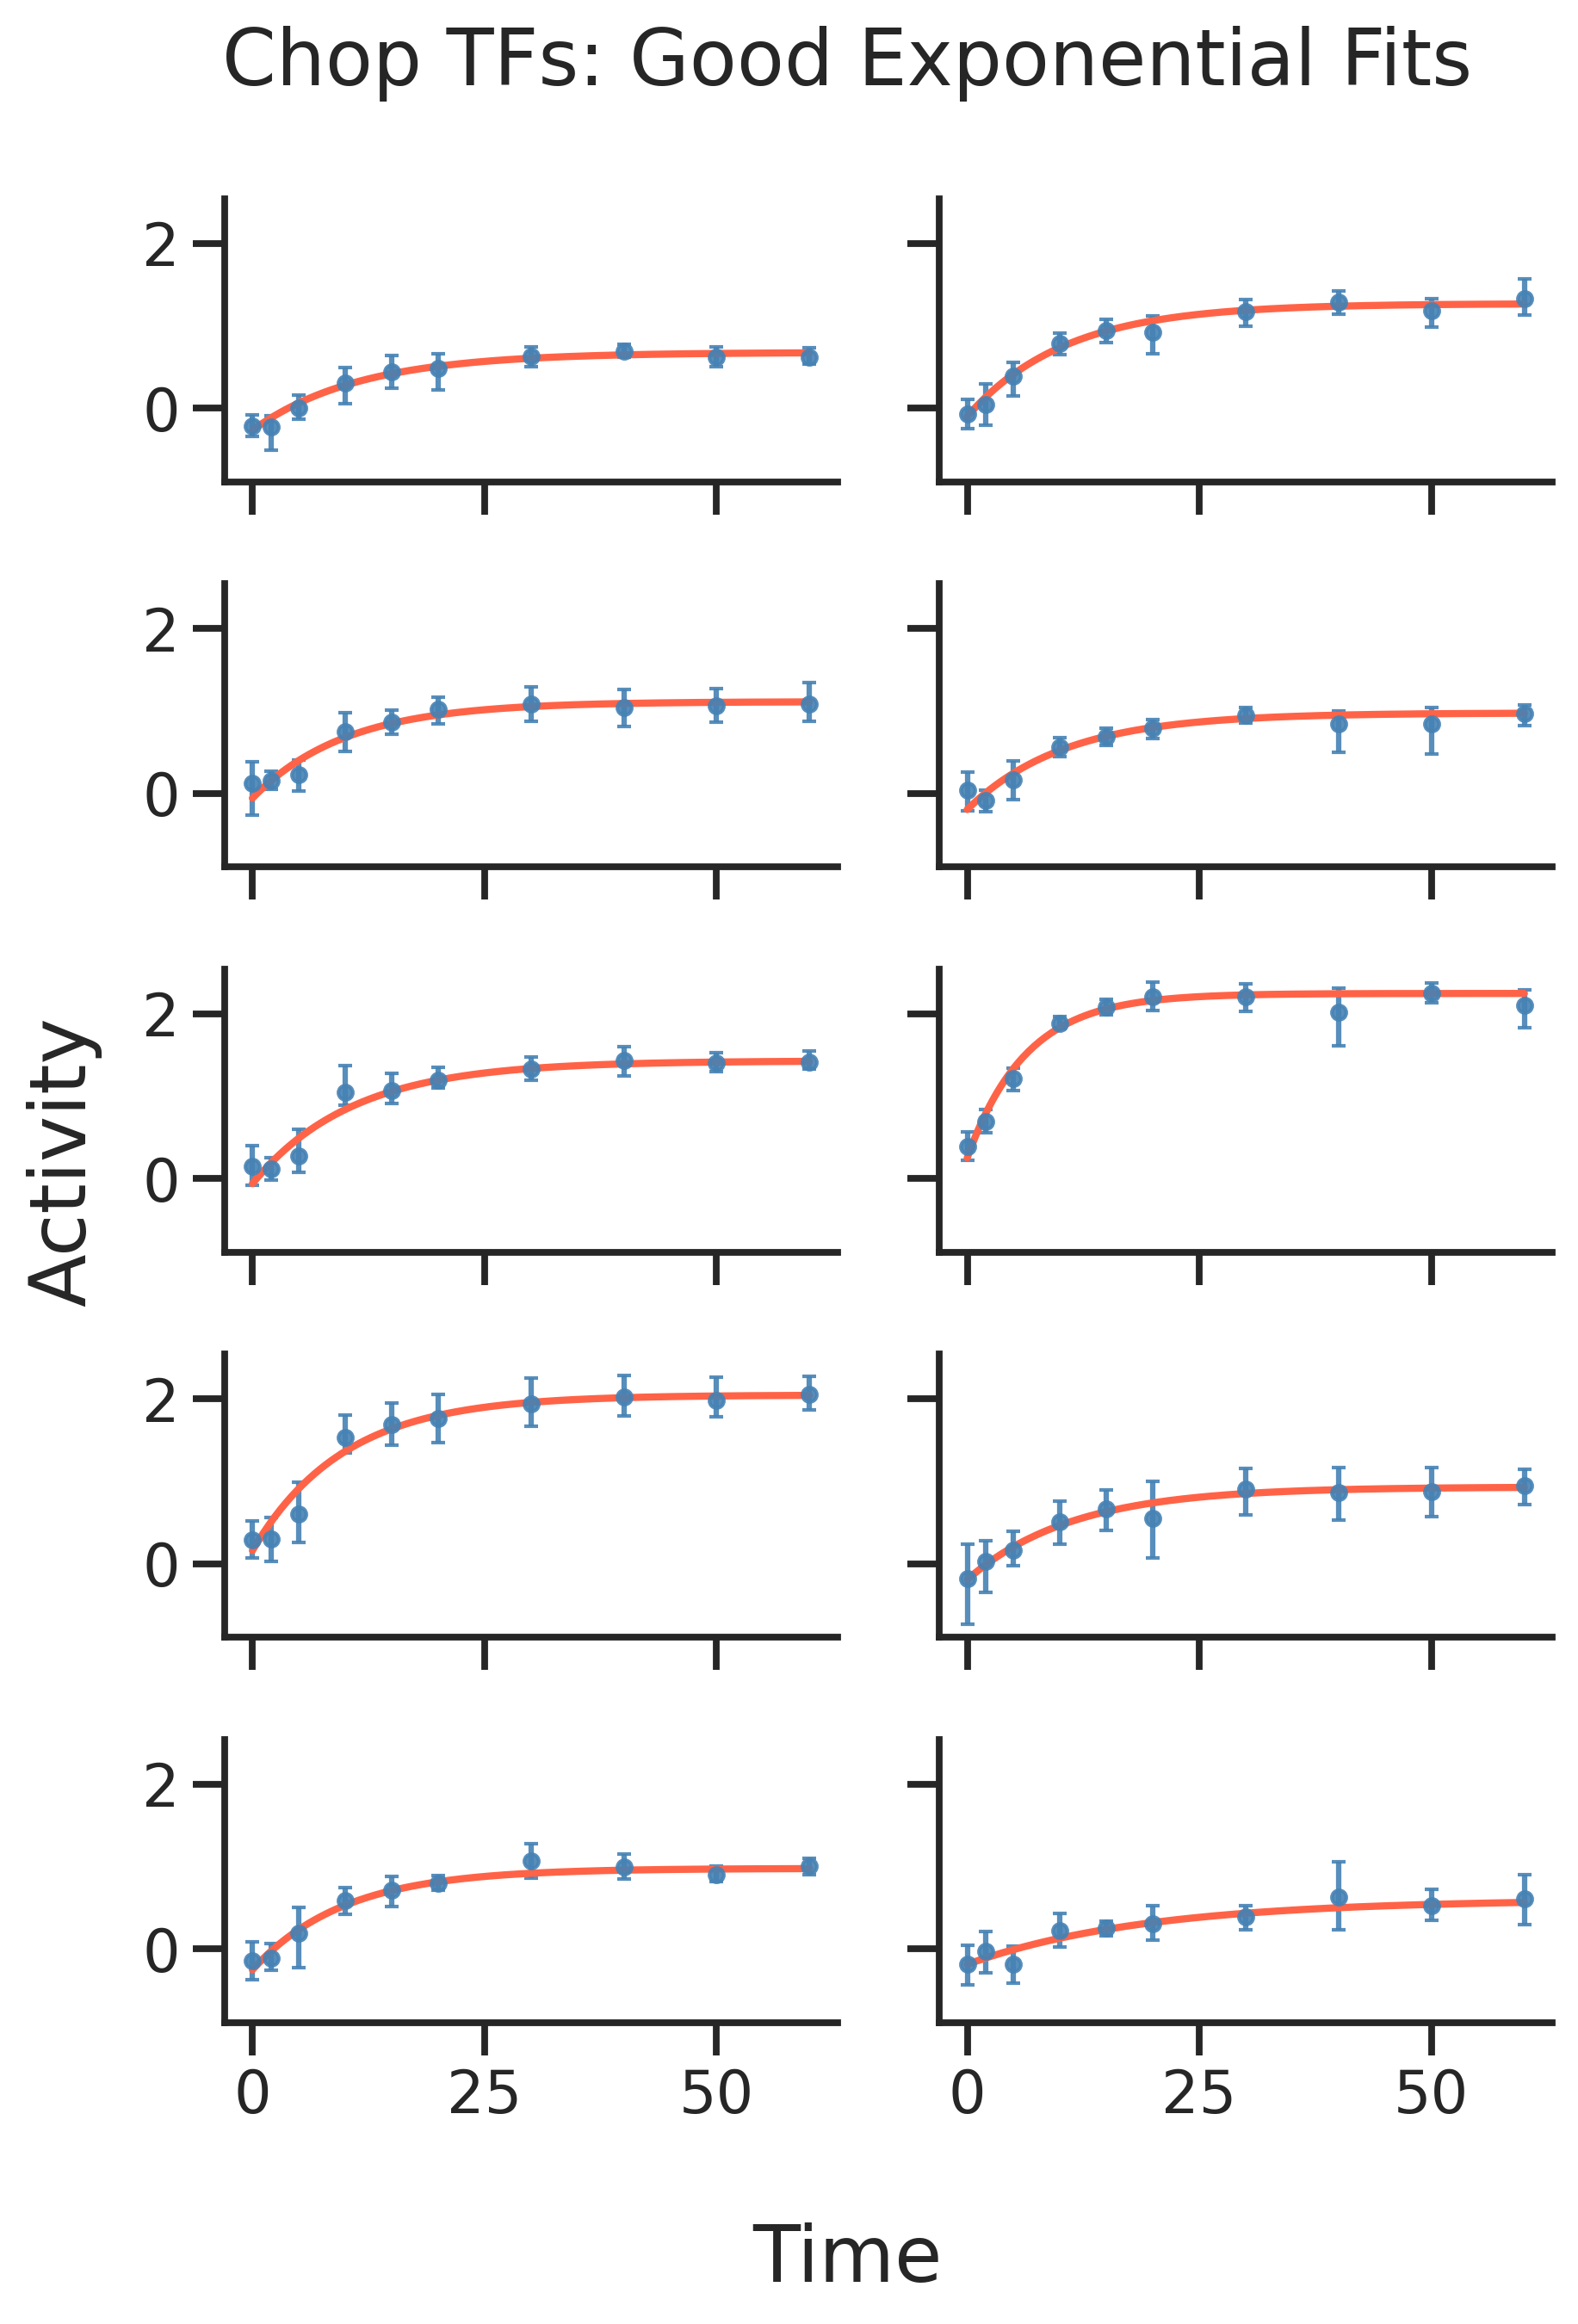

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns

def rising_exponential(t, A, k, C):
    return A * (1 - np.exp(-k * t)) + C

sample_adseqs = ok.sample(16, random_state=42)["ADseq"].values

speed_plotting_helpers.plot_model_fits(
    activities=active_tile_activities_count_filtered,
    fit_results=fit_results,
    sample_adseqs=sample_adseqs,
    model_fn=rising_exponential,
    model_params=["A", "k", "C"],
    y_col="activity",
    title="Chop TFs: Good Exponential Fits",
)

In [21]:
# sample_adseqs = not_ok.sample(16, random_state=42)["ADseq"].values

# speed_plotting_helpers.plot_model_fits(
#     activities=active_tile_activities_count_filtered,
#     fit_results=fit_results,
#     sample_adseqs=sample_adseqs,
#     model_fn=rising_exponential,
#     model_params=["A", "k", "C"],
#     y_col="activity",
#     title="Chop TFs: Poor Exponential Fits",
# )

In [22]:
import numpy as np
import pandas as pd

# --- filter the valid range first ---
filtered = ok[
    (ok['k'] >= 0) & (ok['k'] <= 0.2) &
    (ok['obs_max'] >= 0) & (ok['obs_max'] <= 5)
].copy()

# --- 1. Similar A, different k ---
A_target = filtered['obs_max'].median()
A_tol = filtered['obs_max'].std() * 0.2  # ±0.3 SD around median

similar_A = filtered[(filtered['obs_max'] >= A_target - A_tol) & (filtered['obs_max'] <= A_target + A_tol)].copy()
similar_A_sorted = similar_A.sort_values('k')

# Pick two sequences with widely separated k
seq_simA_diffk = similar_A_sorted.iloc[[0, -1]]  # first and last k

# --- 2. Similar k, different A ---
k_target = filtered['k'].median()
k_tol = filtered['k'].std() * 0.2  # ±0.3 SD around median

similar_k = filtered[(filtered['k'] >= k_target - k_tol) & (filtered['k'] <= k_target + k_tol)].copy()
similar_k_sorted = similar_k.sort_values('obs_max')

# Pick two sequences with widely separated A
seq_simk_diffA = similar_k_sorted.iloc[[0, -1]]  # lowest and highest A

# --- Combine for inspection ---
to_plot = pd.concat([seq_simA_diffk, seq_simk_diffA])
to_plot

,ADseq,A,A_err,k,k_err,C,C_err,t_half,t_half_err,obs_max,t_half_model_empirical,r_squared,flag,A+C,A*k,1/k
350,KINVEGLAMFINEILVNSFNDTSFLNMEDPIRNEFSFDNG,1.194898,0.114467,0.043594,0.012596,0.141235,0.084860,15.900237,4.594322,1.248759,11.903808,0.968219,ok,1.336133,0.052090,22.939193
710,SSTWFEPLENIISSASSSSIGSPIEDQFISSNNEESALFP,0.914166,0.133391,0.180109,0.061256,0.303136,0.128948,3.848481,1.308886,1.217283,2.284569,0.819200,ok,1.217301,0.164650,5.552185
73,DFFNDGACNEINVILDKAKVRRDFLDYFMPEKEVKAEGDR,0.847291,0.104075,0.098594,0.027638,-0.279054,0.097839,7.030313,1.970769,0.565952,11.062124,0.943691,ok,0.568237,0.083538,10.142598
770,TNSVNGSYTEDSLKRIWNELHISSLDIEPYSYGYIDYLFS,1.996661,0.167667,0.094893,0.017568,0.115527,0.162110,7.304547,1.352311,2.105464,6.733467,0.973787,ok,2.112188,0.189468,10.538233


In [23]:
ok["A+C"] = ok["A"] + ok["C"]
ok

,ADseq,A,A_err,k,k_err,C,C_err,t_half,t_half_err,obs_max,t_half_model_empirical,r_squared,flag,A+C,A*k,1/k
0,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,1.156830,0.101060,0.269285,0.069876,-0.408963,0.100999,2.574025,0.667927,0.747866,4.208417,0.924506,ok,0.747866,0.311517,3.713533
1,AASNSYAIPENELLDEDTMNFISSLKNDLSNISNSLPFEY,1.629568,0.079913,0.132274,0.015466,0.342460,0.078549,5.240241,0.612717,1.971445,3.847695,0.988783,ok,1.972028,0.215549,7.560070
2,AAVPQQNIAPPFLNTNSSATDSNPNTNLEDSLFFDHDLLS,1.533139,0.098494,0.128593,0.012426,-0.266570,0.100362,5.390225,0.520850,1.265886,6.853707,0.983280,ok,1.266569,0.197152,7.776451
3,AELHNWEPPLYDSVGNHNHAGTMESHPHTNIHEELKEFLS,1.098801,0.101313,0.096377,0.021066,0.055955,0.096084,7.192037,1.572054,1.151371,6.613226,0.955792,ok,1.154756,0.105899,10.375916
4,AELPRRFMDLESWRIETYNELERWFQVDVPKNFEMMNCKF,1.508101,0.108744,0.117486,0.022559,0.037501,0.095994,5.899836,1.132839,1.544293,5.651303,0.954109,ok,1.545602,0.177181,8.511664
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
852,YNFQNARLLIRKIWQNEADGISEHDLVHMIDELDYNINFA,1.563304,0.073382,0.093508,0.008916,-0.208122,0.073789,7.412734,0.706836,1.349461,8.897796,0.966920,ok,1.355182,0.146181,10.694315
853,YPQDLVSSPAMSHLTANNDDFDDLLSVASMNSNYLLPVNS,1.120782,0.082873,0.080102,0.017744,0.010666,0.080531,8.653300,1.916833,1.122281,8.416834,0.969677,ok,1.131448,0.089777,12.484073
854,YSLVTGKQPLIPHEMTSCLFPKDVVGLGVDDSMDCFTLIN,1.598856,0.100220,0.111316,0.014868,-0.181693,0.102116,6.226831,0.831686,1.415154,7.334669,0.977314,ok,1.417164,0.177979,8.983418
855,YSNARGSDPSSYAIEGEYKTLATDDLGNILNLNYGETNEV,1.245690,0.098534,0.084823,0.012658,0.000967,0.104688,8.171657,1.219457,1.238982,8.056112,0.970036,ok,1.246658,0.105664,11.789209


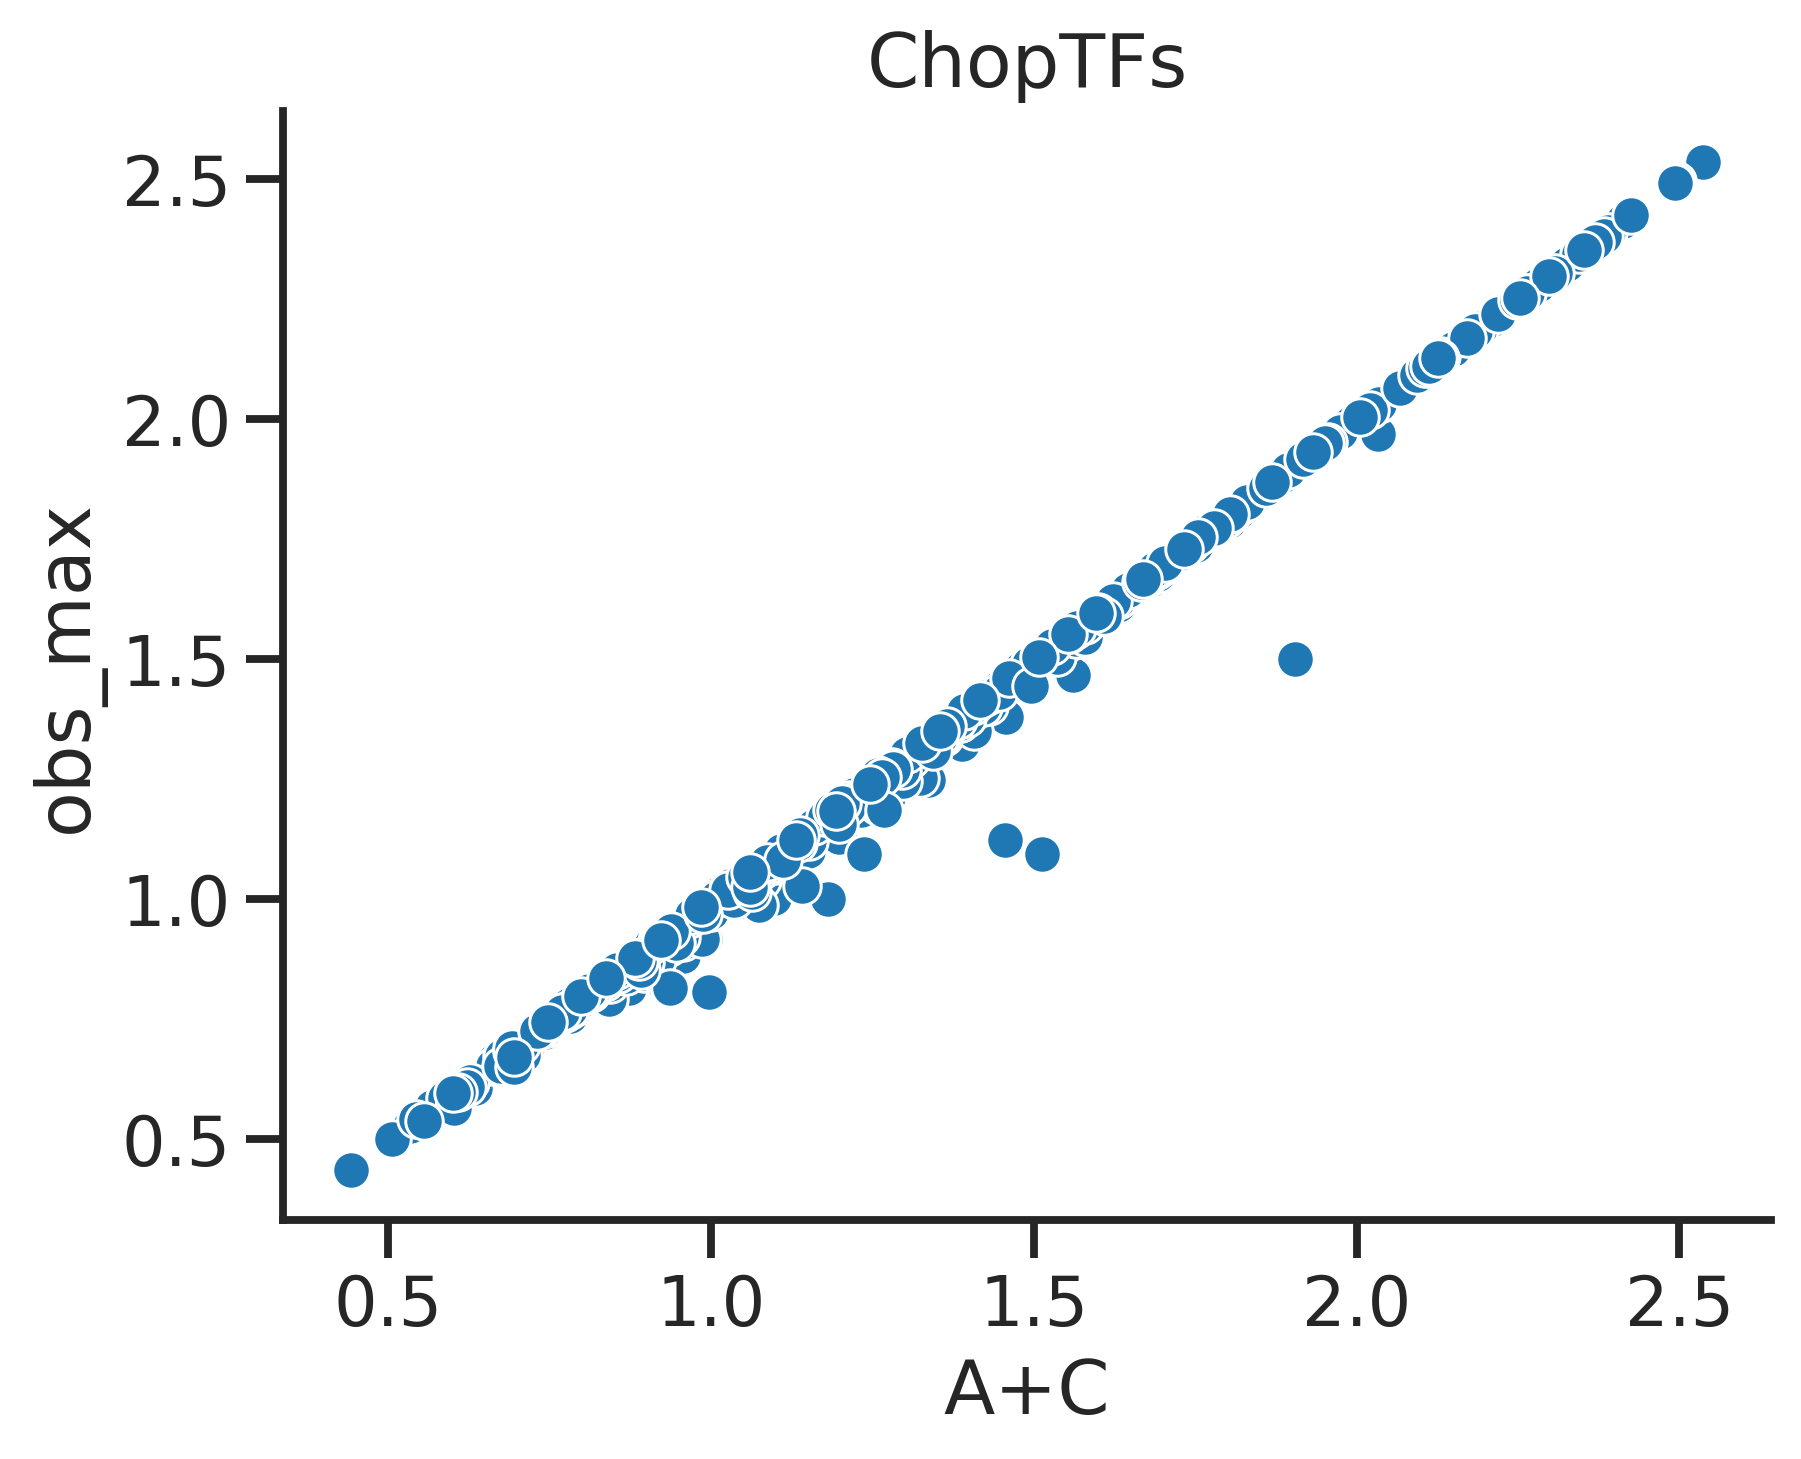

In [24]:
# Does the observed maximum correlate with the maximum from the model parameter?
plt.figure(dpi = 300)
sns.scatterplot(data = ok, x = "A+C", y = "obs_max")
plt.title("ChopTFs")
sns.despine()

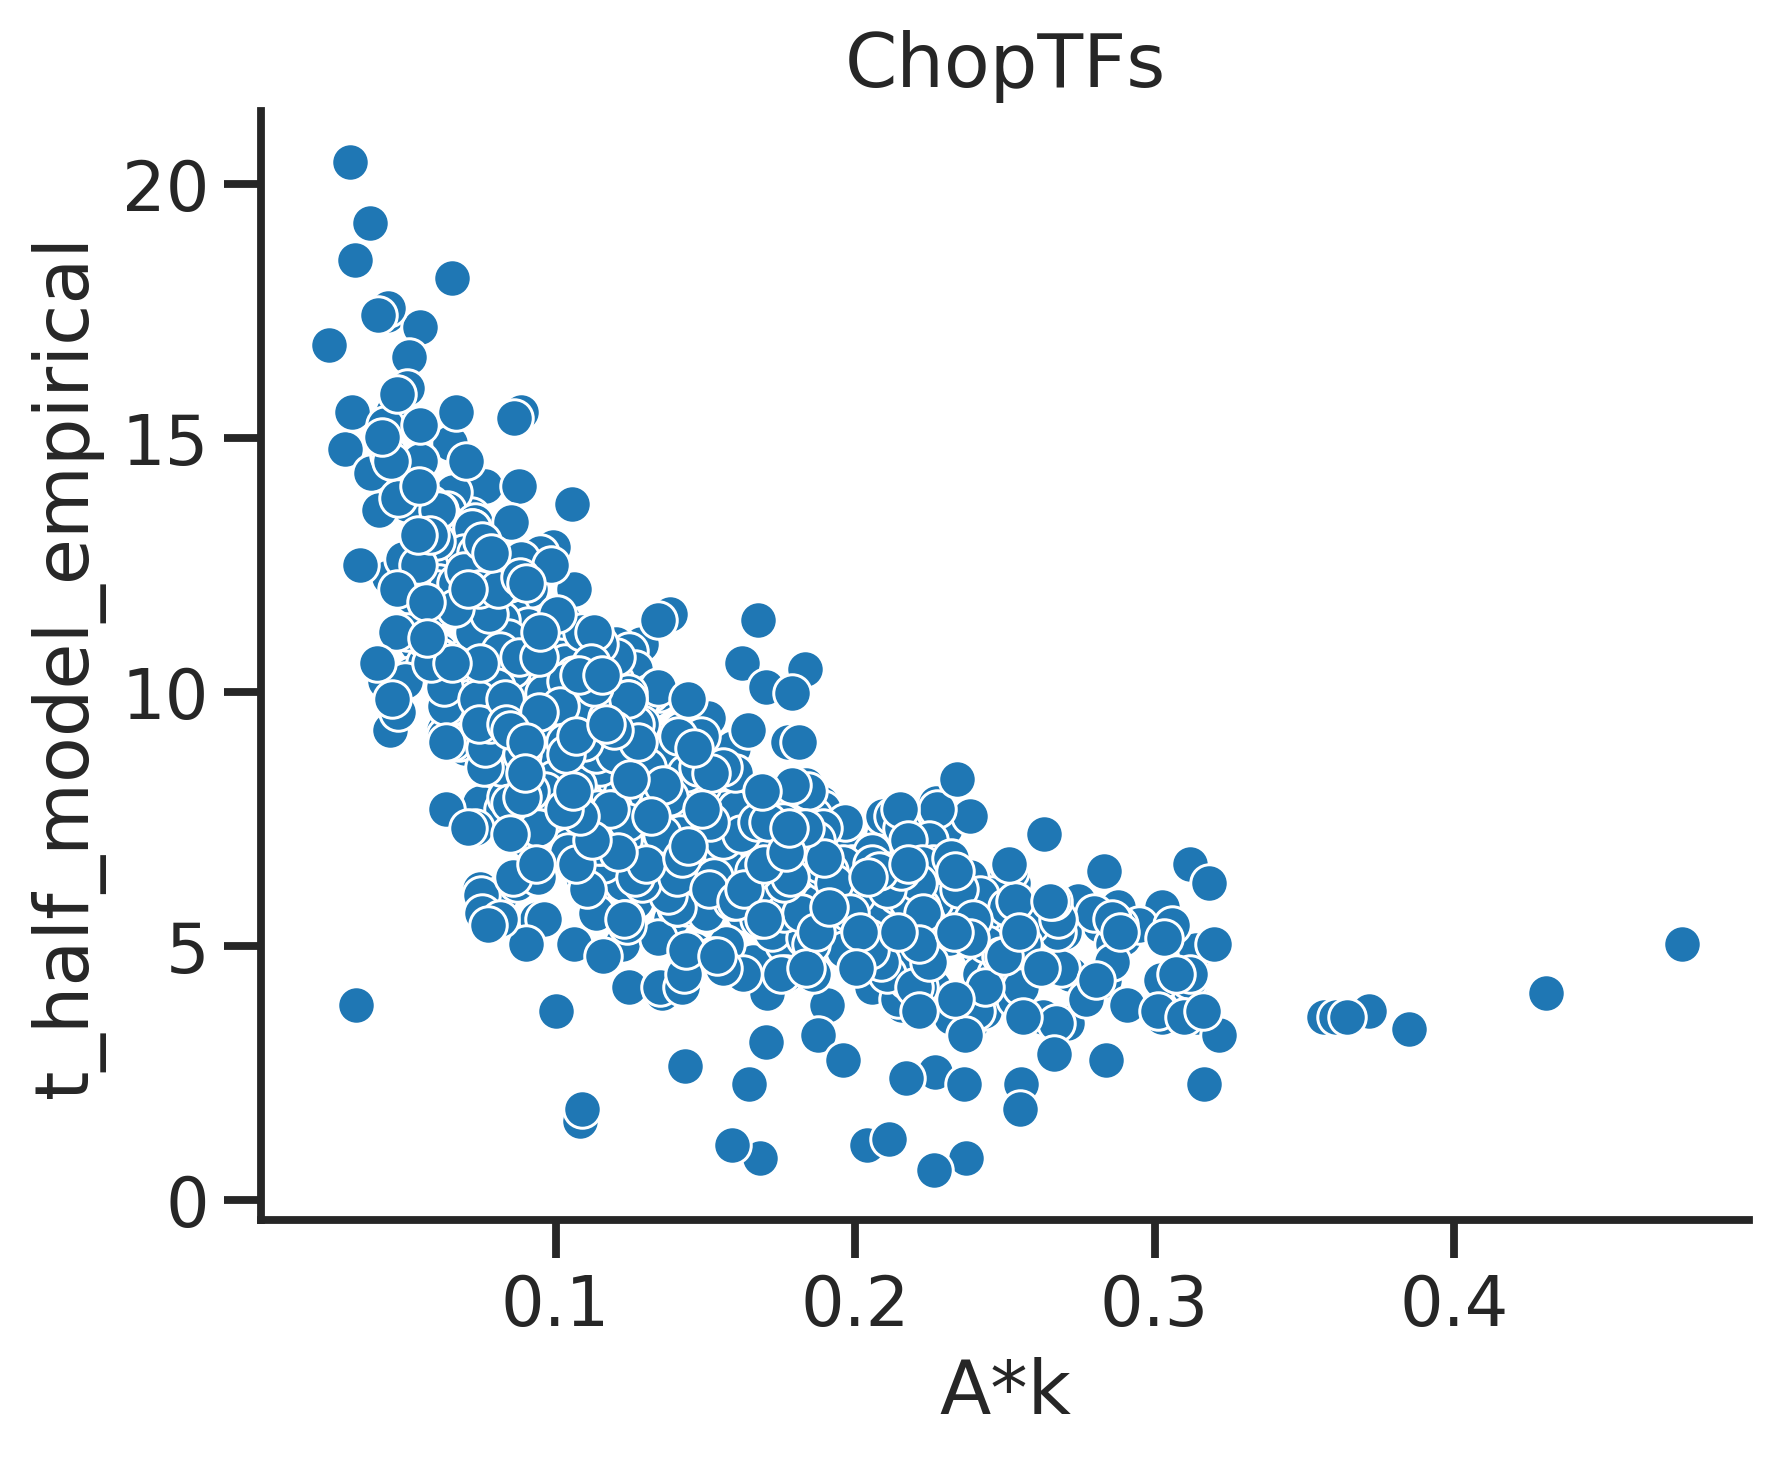

In [25]:
# Does the observed maximum correlate with the maximum from the model parameter?
plt.figure(dpi = 300)
sns.scatterplot(data = ok, x = "A*k", y = "t_half_model_empirical")
plt.title("ChopTFs")
sns.despine()

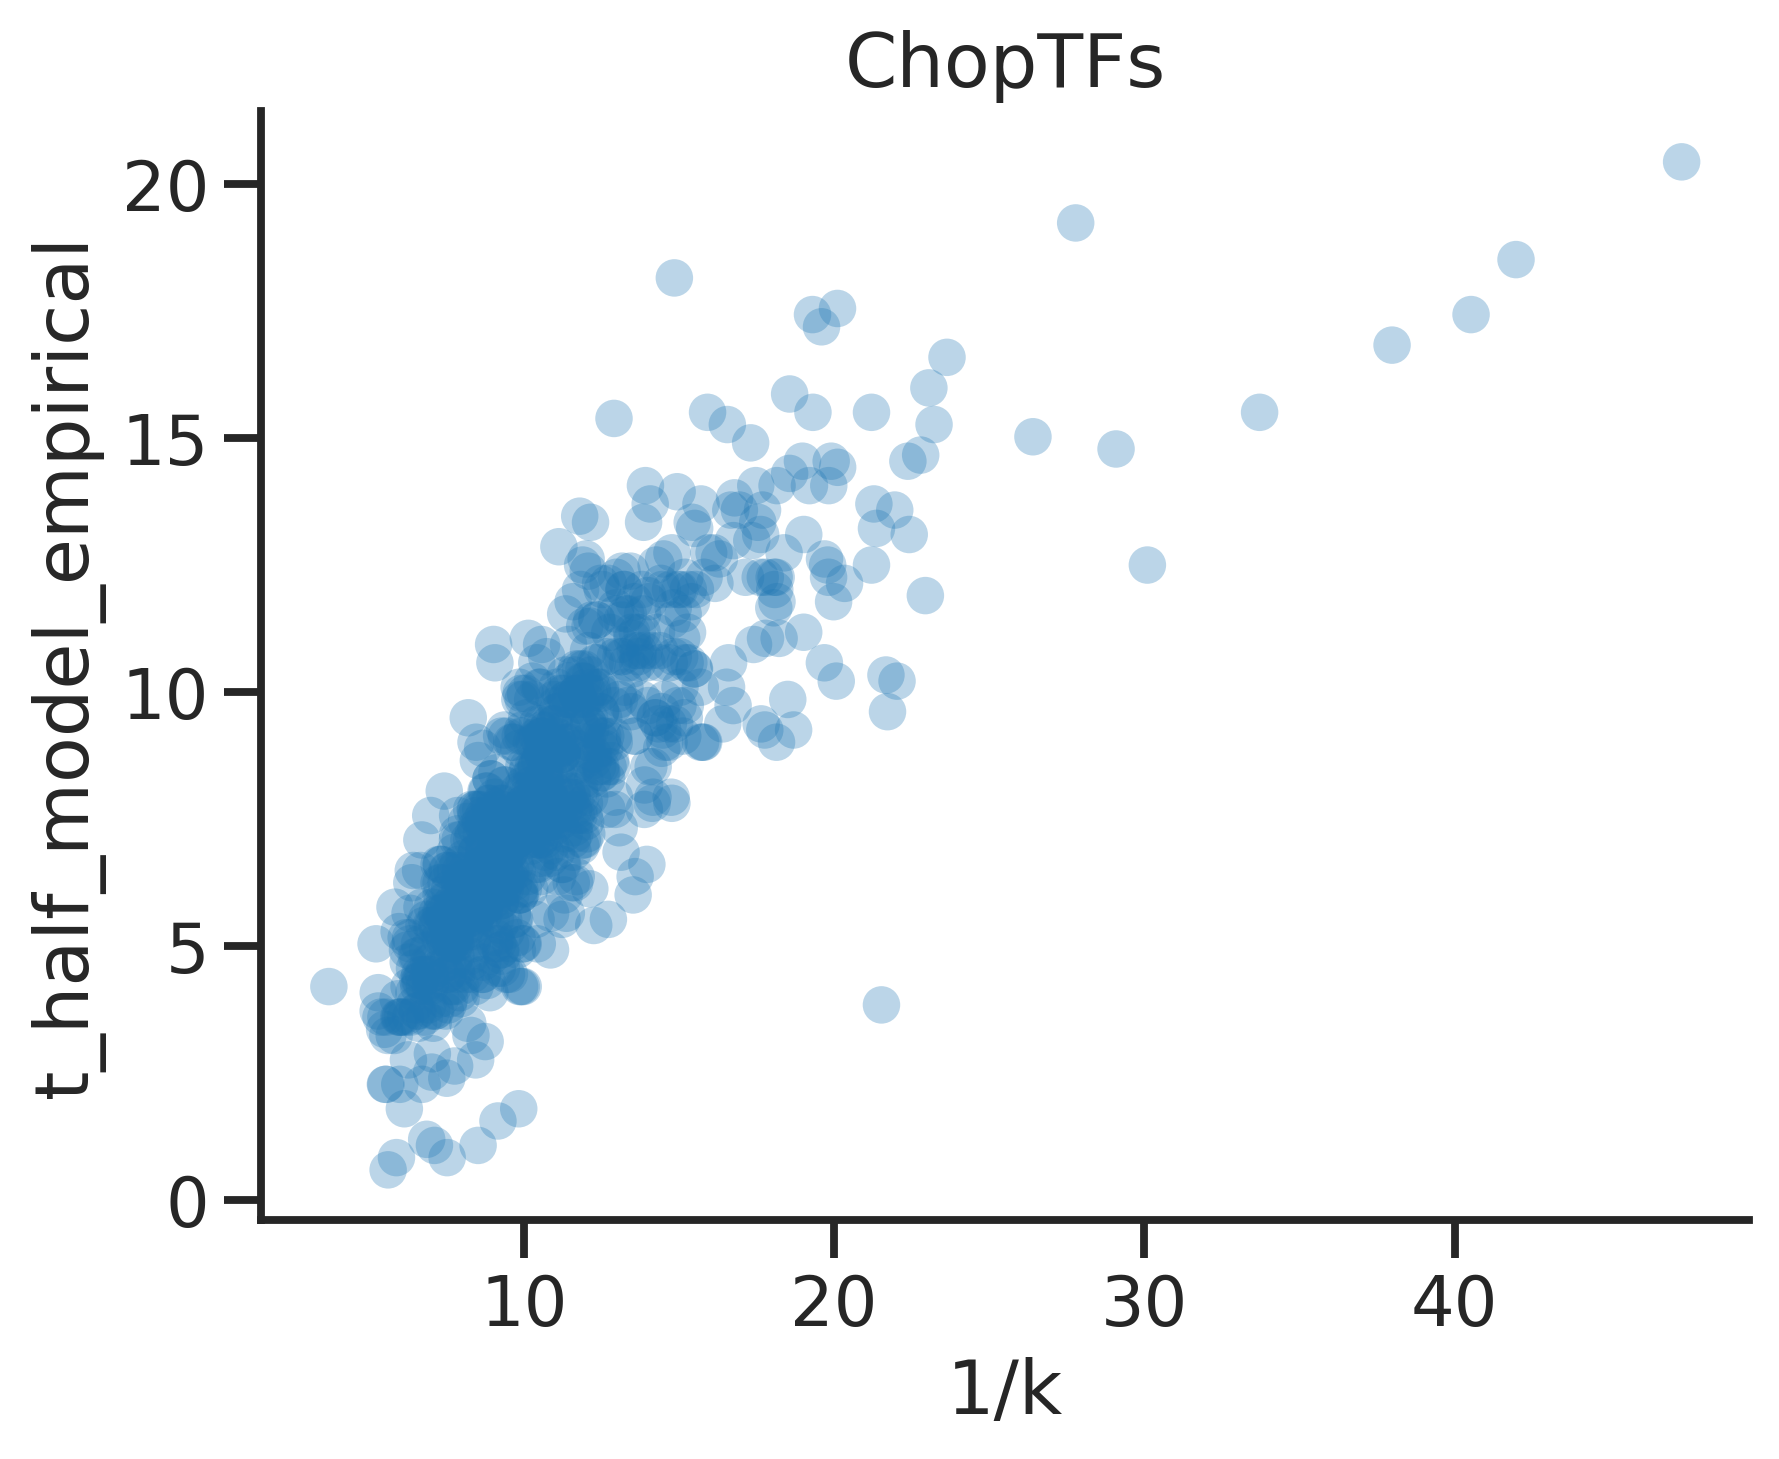

In [27]:
# Does the observed maximum correlate with the maximum from the model parameter?
plt.figure(dpi = 300)
sns.scatterplot(data = ok, x = "1/k", y = "t_half_model_empirical", edgecolor = 'none', alpha = 0.3)
plt.title("ChopTFs")
sns.despine()

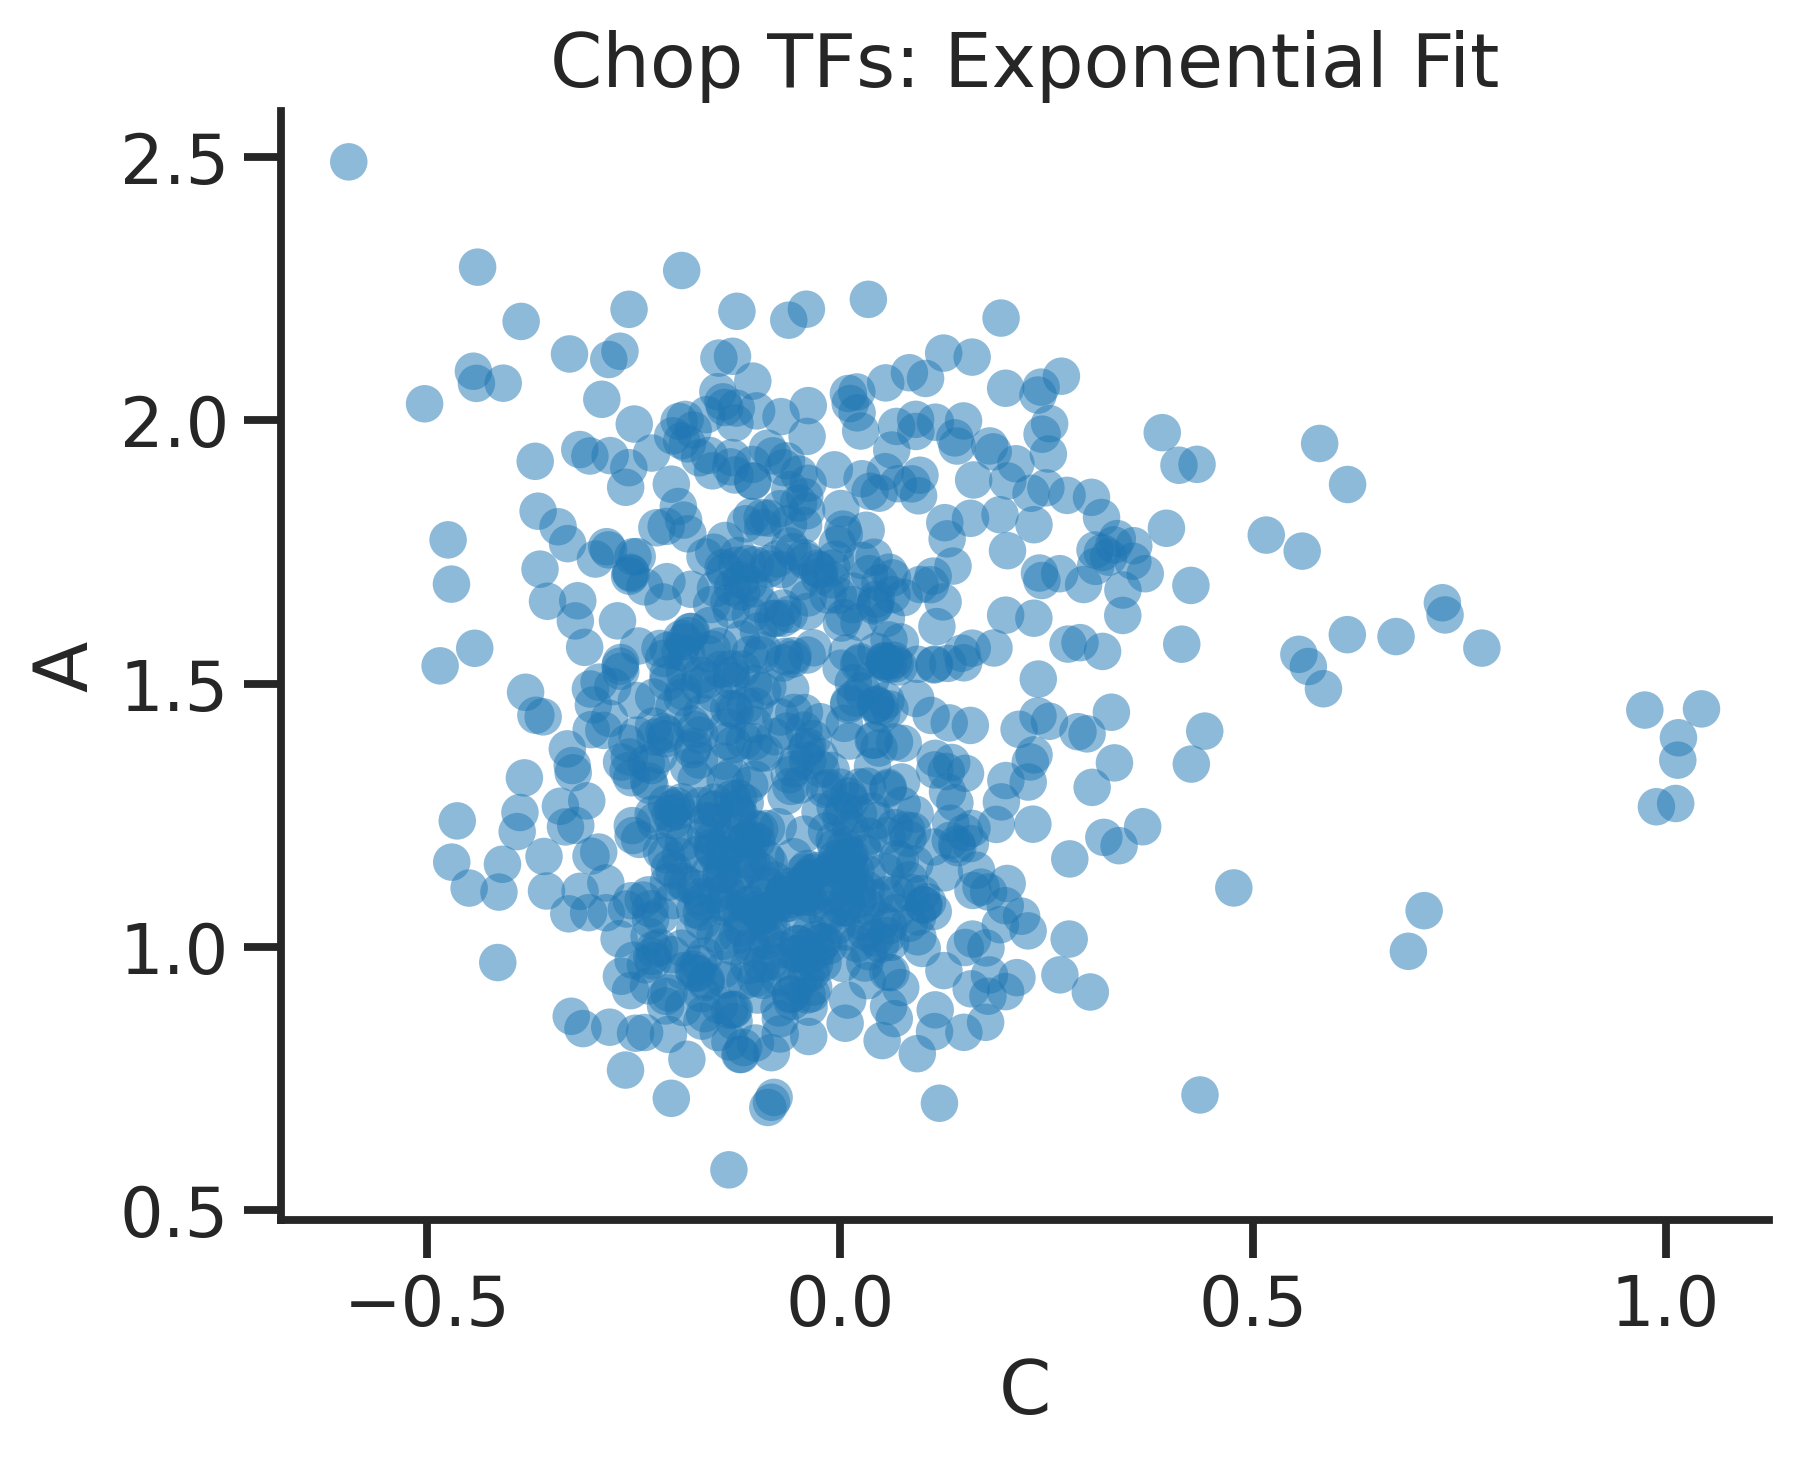

In [17]:
# The rise from baseline does not correlate with the starting activity
plt.figure(dpi = 300)
sns.scatterplot(data = ok, x = "C", y = "A", edgecolor = 'none', alpha = 0.5)
plt.title("Chop TFs: Exponential Fit")
sns.despine()

Pearson r = 0.543, p = 1.34e-66
Spearman rho = 0.562, p = 4.69e-72


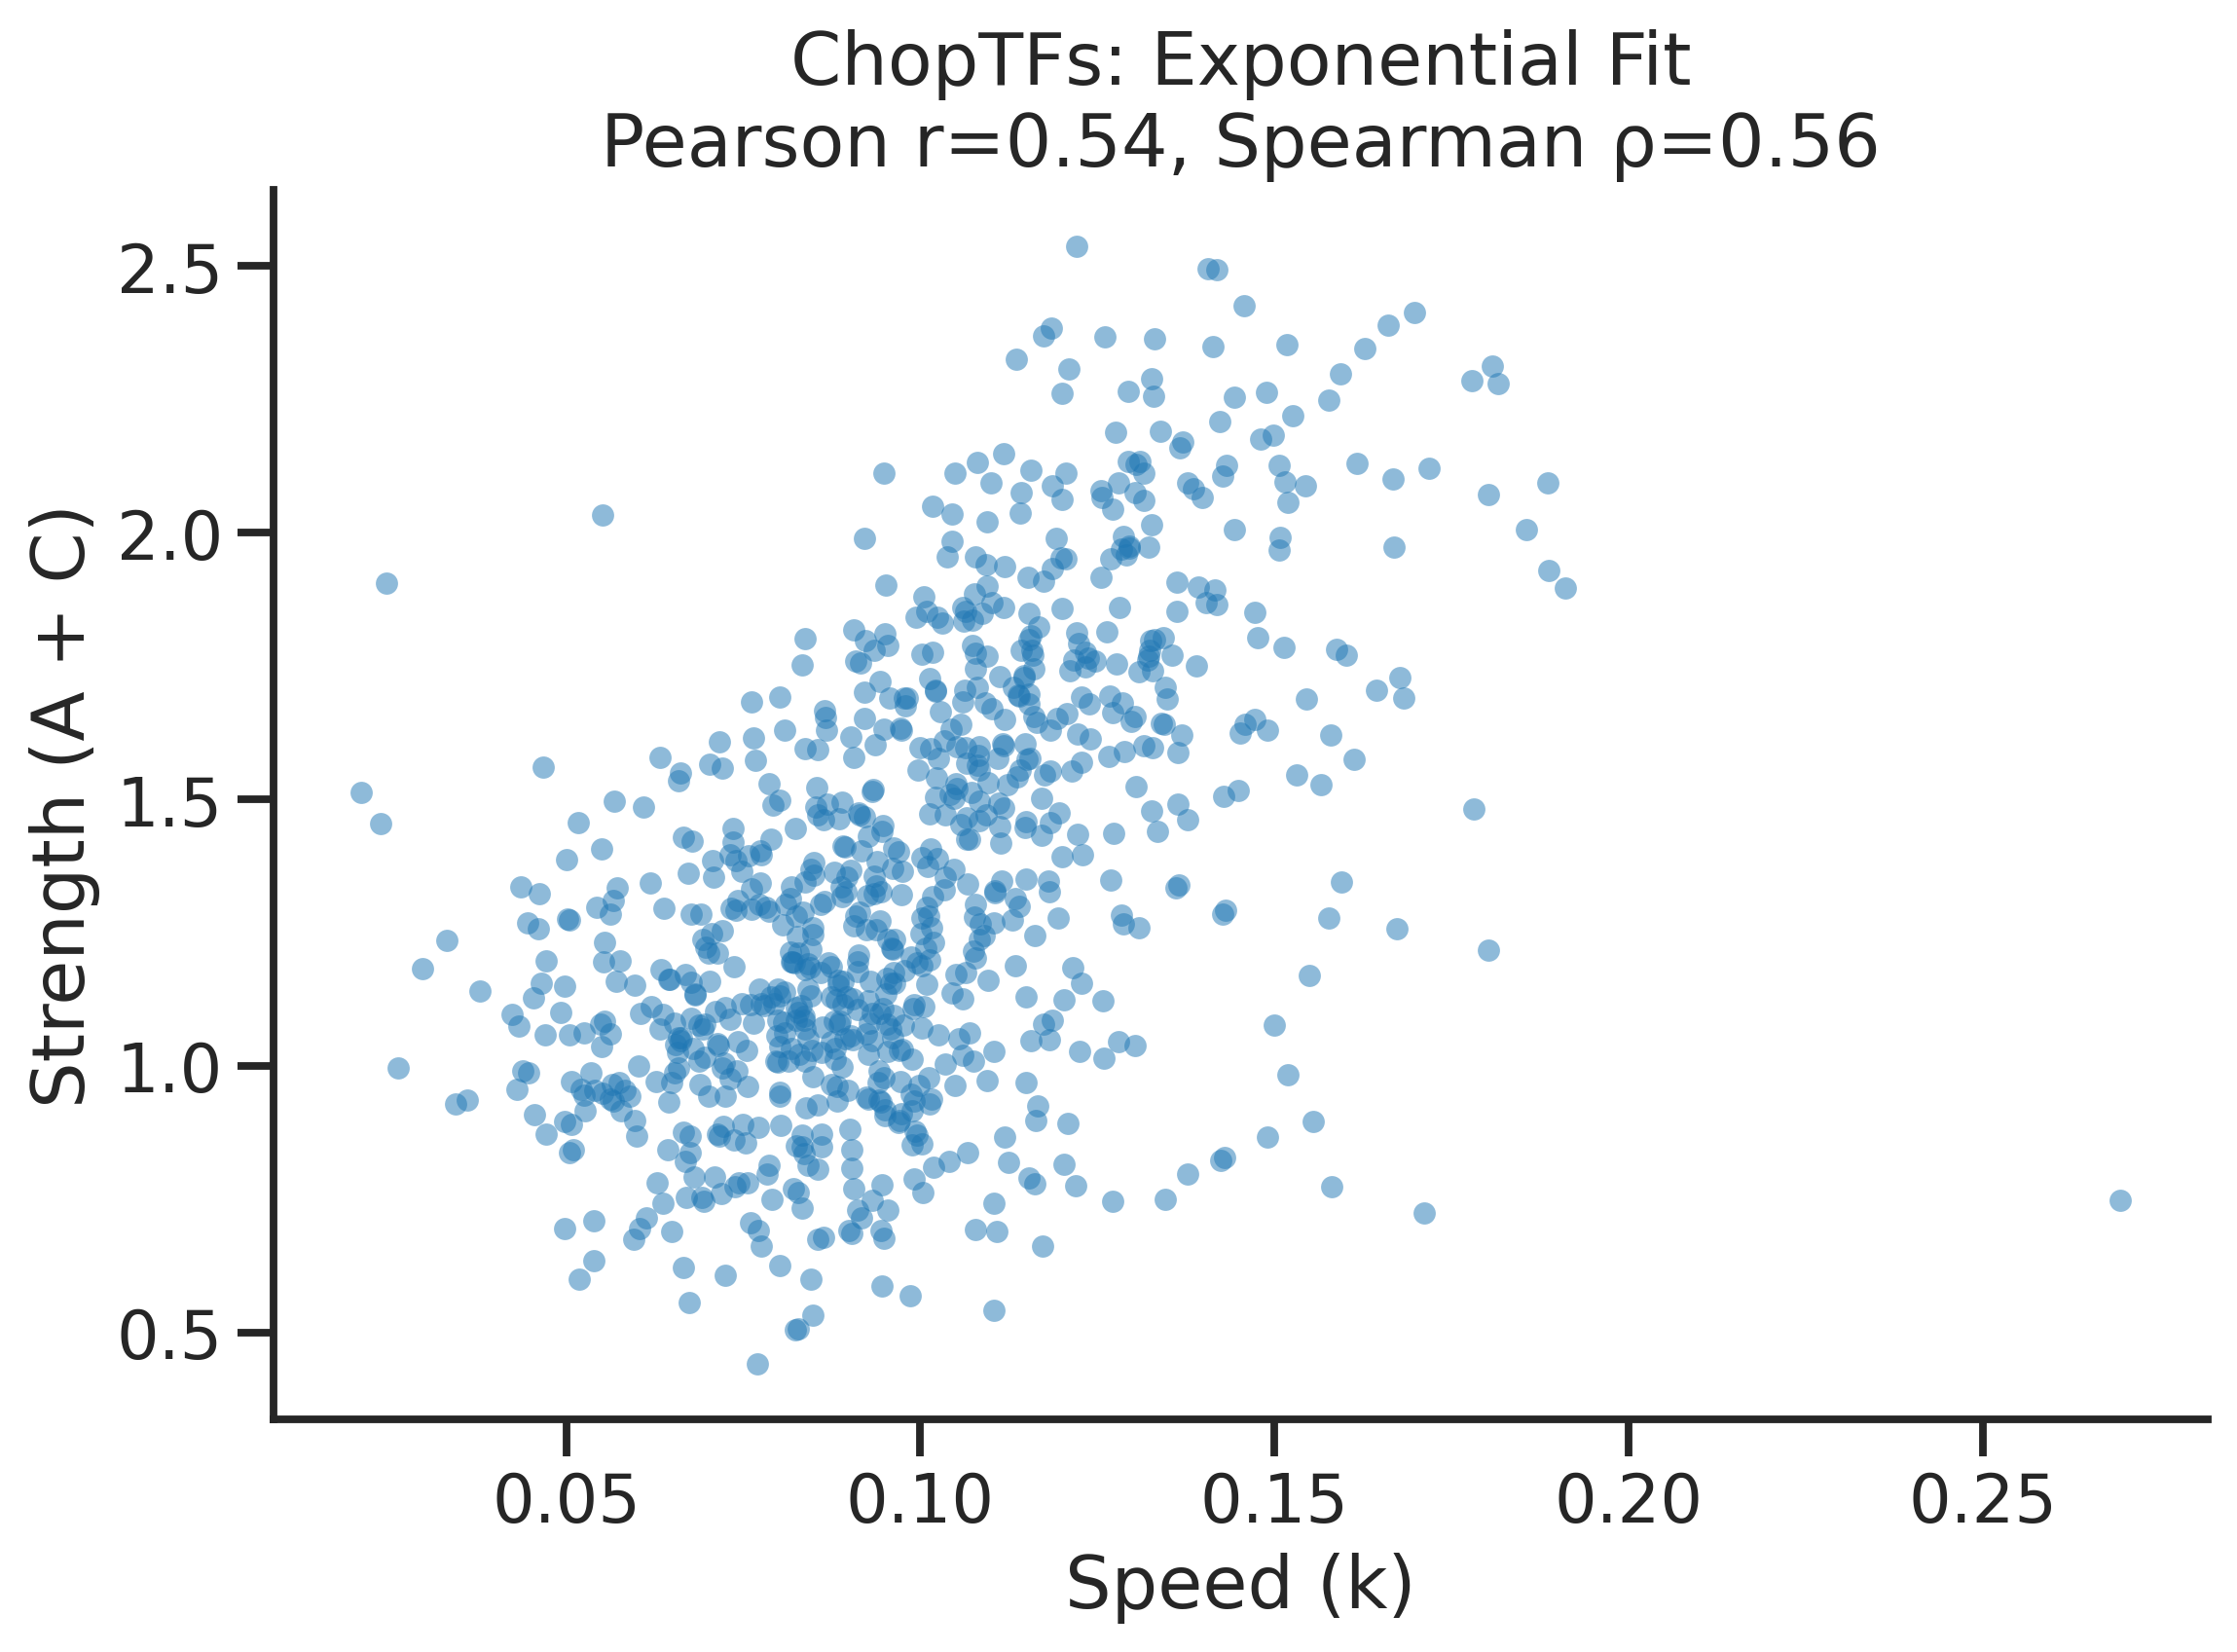

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

sns.set_context('talk')

# --- calculate correlations ---
pearson_corr, pearson_p = pearsonr(ok['k'], ok ['A+C'])
spearman_corr, spearman_p = spearmanr(ok['k'], ok ['A+C'])

print(f"Pearson r = {pearson_corr:.3f}, p = {pearson_p:.3g}")
print(f"Spearman rho = {spearman_corr:.3f}, p = {spearman_p:.3g}")

# --- plot ---
fig, ax = plt.subplots(figsize=(8, 6), dpi = 300)

sc = ax.scatter(
    ok['k'], ok['A+C'],
    alpha=0.5,
    s=30,
    linewidths=0
)


ax.set_xlabel('Speed (k)')
ax.set_ylabel('Strength (A + C)')
ax.set_title(f'ChopTFs: Exponential Fit\nPearson r={pearson_corr:.2f}, Spearman ρ={spearman_corr:.2f}')

#ax.set_xlim(-0.01, 0.2)
#ax.set_ylim(0.5,2.7)

plt.tight_layout()
sns.despine()
plt.show()

Pearson r = 0.543, p = 1.34e-66
Spearman rho = 0.562, p = 4.69e-72


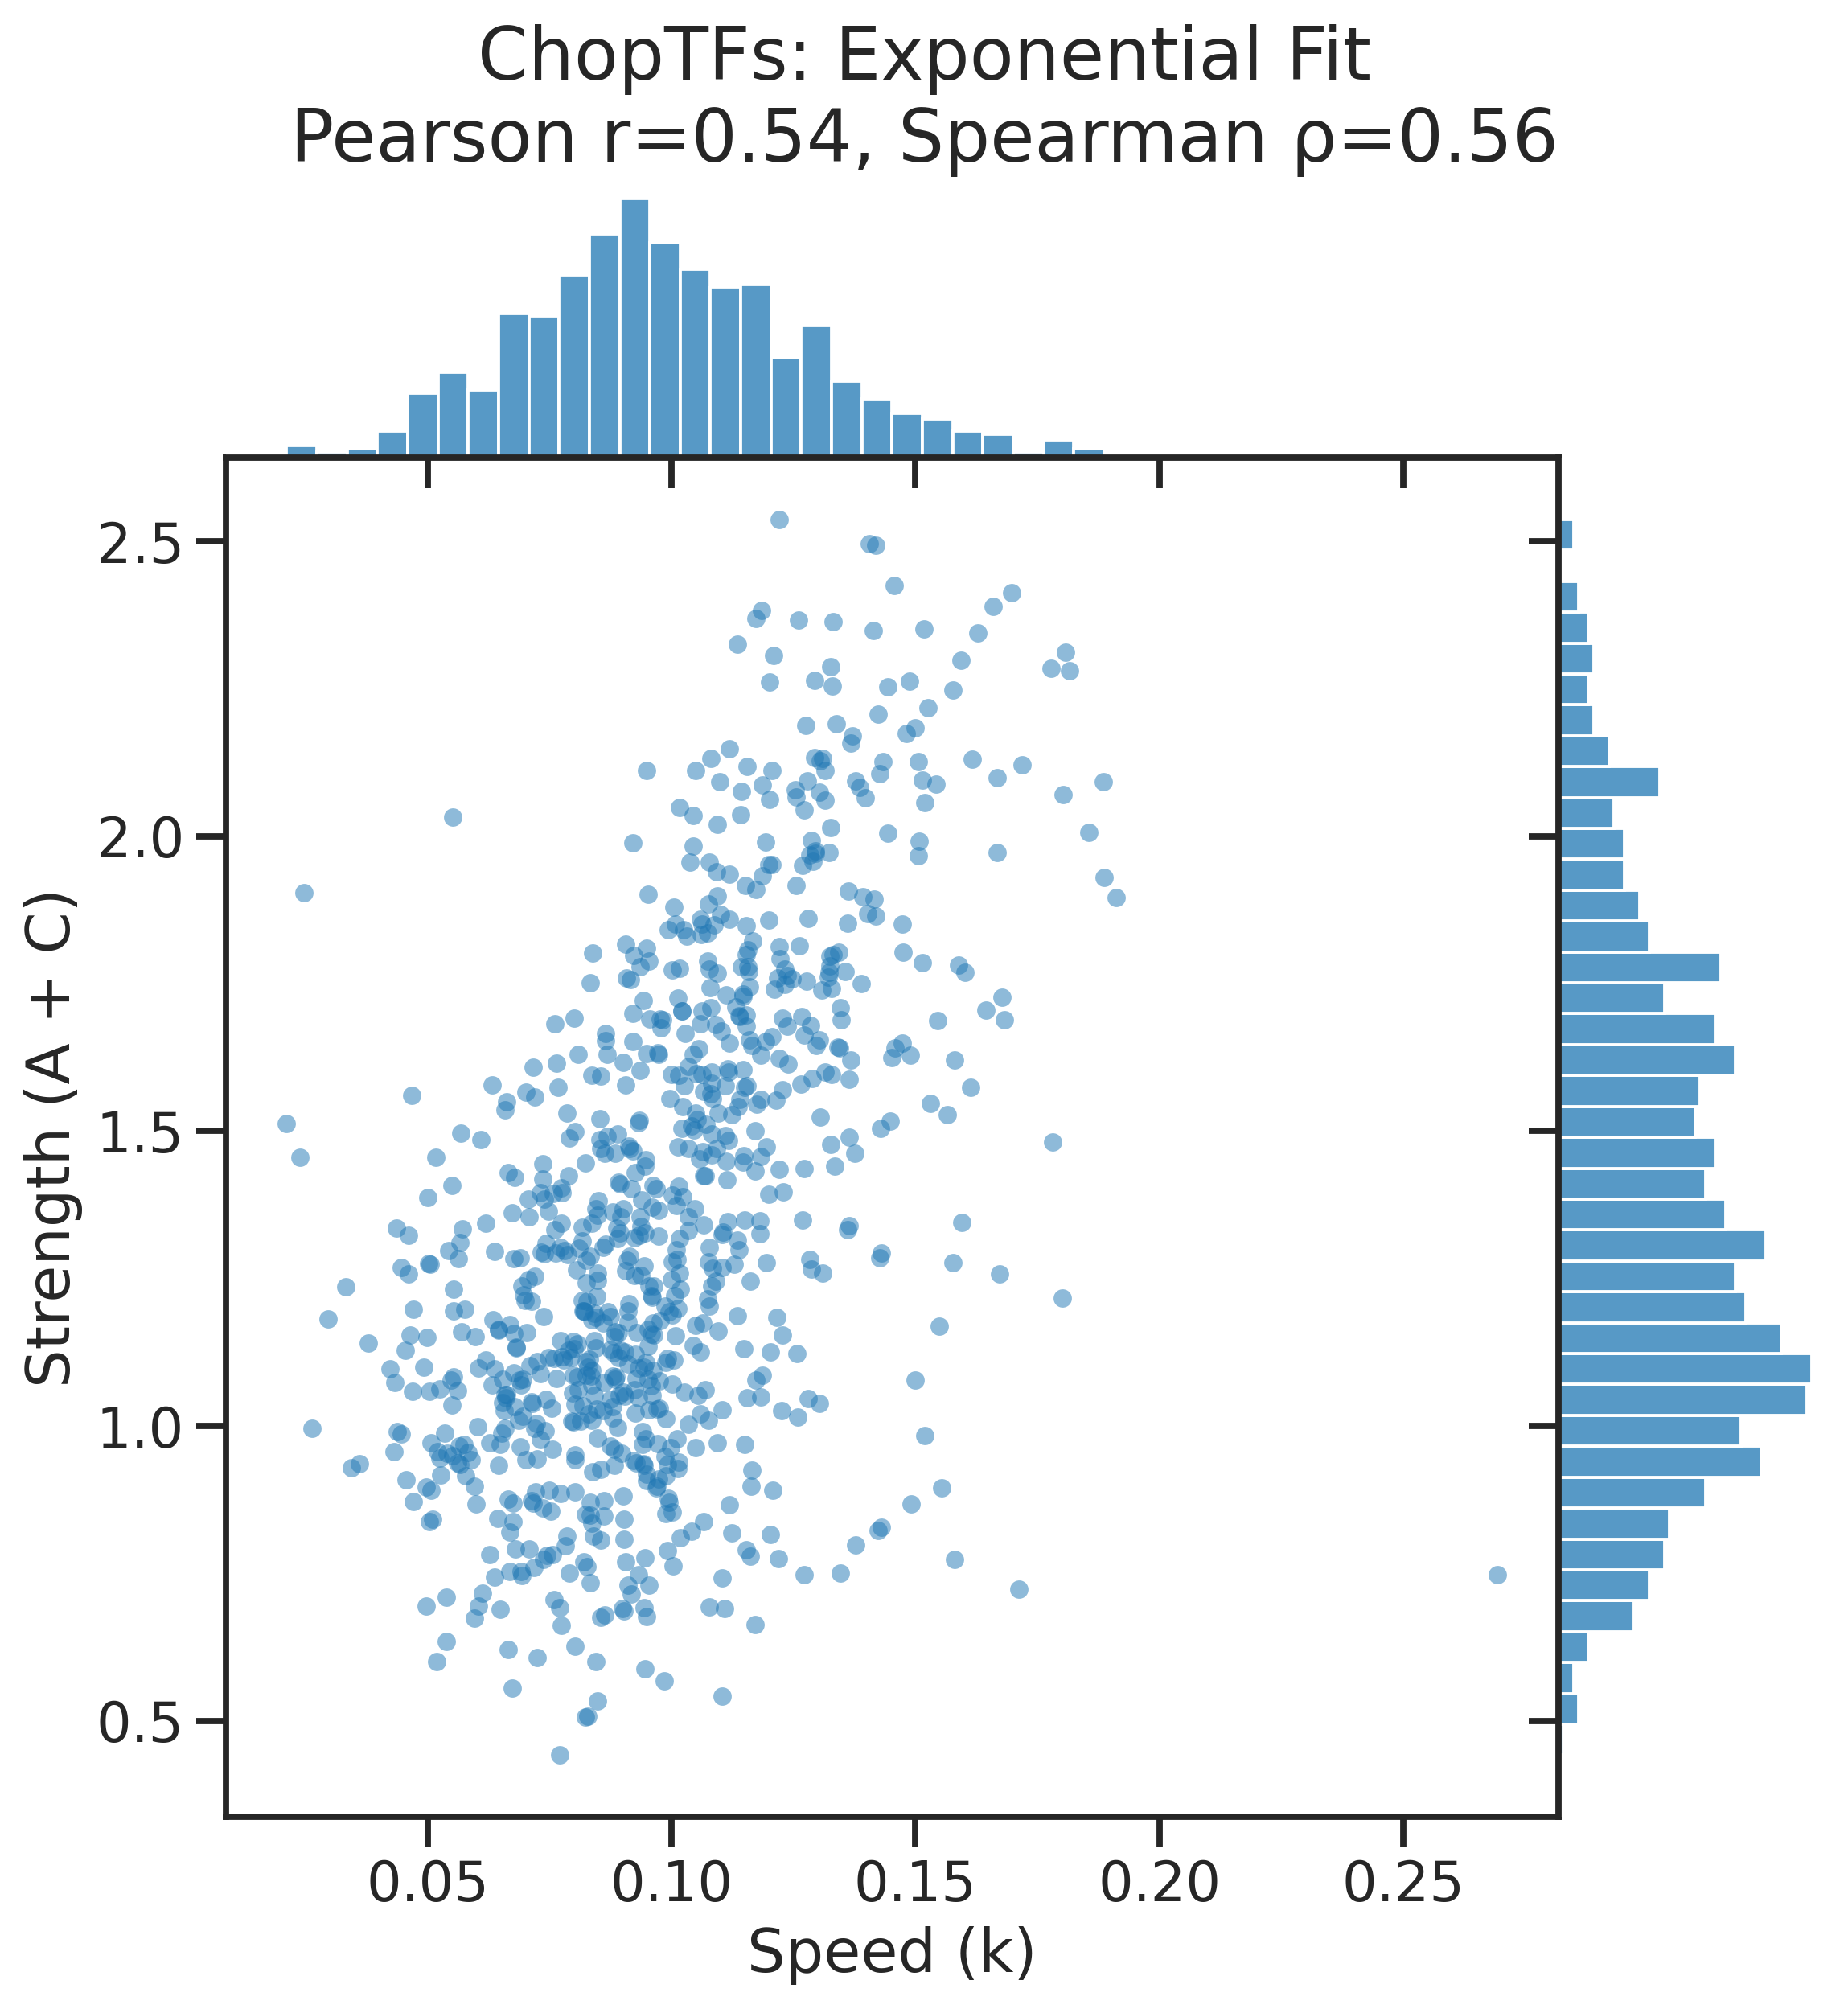

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

sns.set_context('talk')

# --- calculate correlations ---
pearson_corr, pearson_p = pearsonr(ok['k'], ok['A+C'])
spearman_corr, spearman_p = spearmanr(ok['k'], ok['A+C'])

print(f"Pearson r = {pearson_corr:.3f}, p = {pearson_p:.3g}")
print(f"Spearman rho = {spearman_corr:.3f}, p = {spearman_p:.3g}")

# --- joint scatter + marginal histograms ---
g = sns.JointGrid(
    data=ok,
    x='k',
    y='A+C',
    height=8,
    ratio=5,
    space=0
)

# scatter
g.plot_joint(
    plt.scatter,
    alpha=0.5,
    s=30,
    linewidths=0
)

# marginal histograms
g.plot_marginals(
    sns.histplot,
    bins=40,
    kde=False
)

# labels + title
g.ax_joint.set_xlabel('Speed (k)')
g.ax_joint.set_ylabel('Strength (A + C)')

g.fig.suptitle(
    f'ChopTFs: Exponential Fit\n'
    f'Pearson r={pearson_corr:.2f}, '
    f'Spearman ρ={spearman_corr:.2f}',
    y=1.05
)

# optional limits
# g.ax_joint.set_xlim(-0.01, 0.2)
# g.ax_joint.set_ylim(0.5, 2.7)
g.fig.set_dpi(300)

sns.despine()
sns.despine(ax=g.ax_marg_x, left=True)
sns.despine(ax=g.ax_marg_y, bottom=True)

plt.show()

Pearson r = 0.785, p = 3.57e-179
Spearman rho = 0.788, p = 1.89e-181


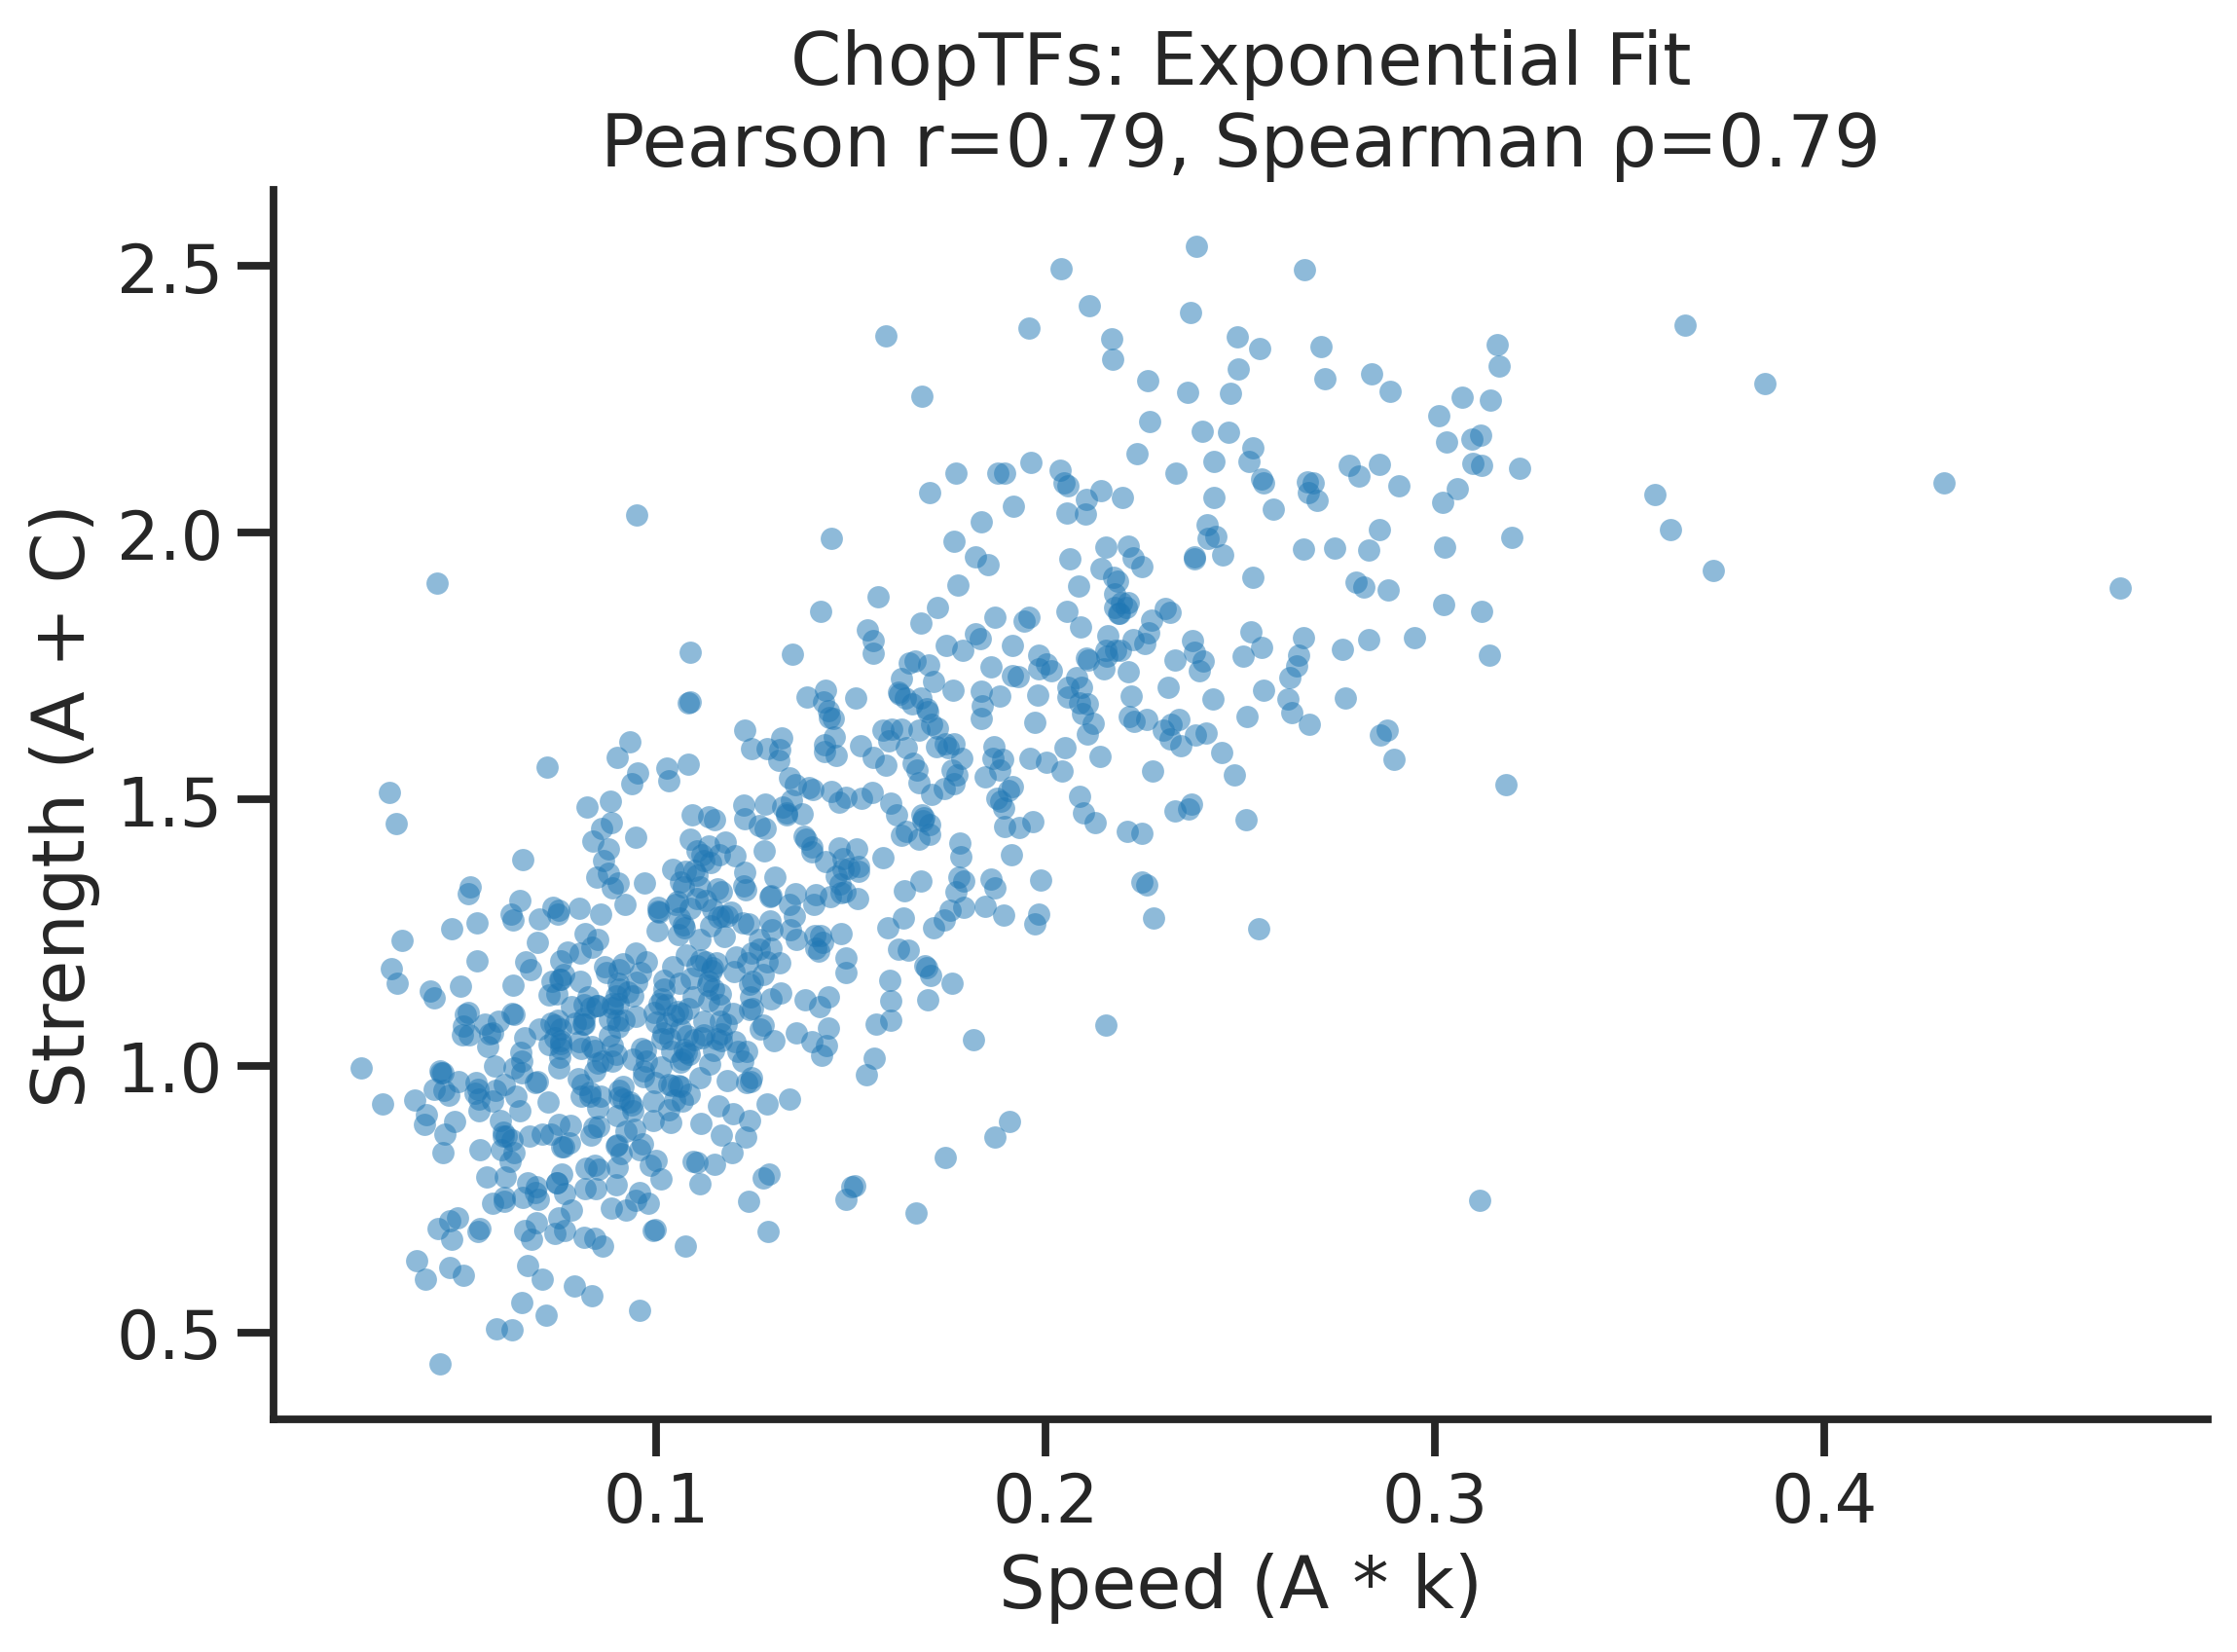

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

sns.set_context('talk')

# --- calculate correlations ---
pearson_corr, pearson_p = pearsonr(ok['A*k'], ok ['A+C'])
spearman_corr, spearman_p = spearmanr(ok['A*k'], ok ['A+C'])

print(f"Pearson r = {pearson_corr:.3f}, p = {pearson_p:.3g}")
print(f"Spearman rho = {spearman_corr:.3f}, p = {spearman_p:.3g}")

# --- plot ---
fig, ax = plt.subplots(figsize=(8, 6), dpi = 300)

sc = ax.scatter(
    ok['A*k'], ok['A+C'],
    alpha=0.5,
    s=30,
    linewidths=0
)


ax.set_xlabel('Speed (A * k)')
ax.set_ylabel('Strength (A + C)')
ax.set_title(f'ChopTFs: Exponential Fit\nPearson r={pearson_corr:.2f}, Spearman ρ={spearman_corr:.2f}')

#ax.set_xlim(-0.01, 0.2)
#ax.set_ylim(0.5,2.7)

plt.tight_layout()
sns.despine()
plt.show()

Pearson r = 0.885, p = 1.07e-283
Spearman rho = 0.906, p = 0


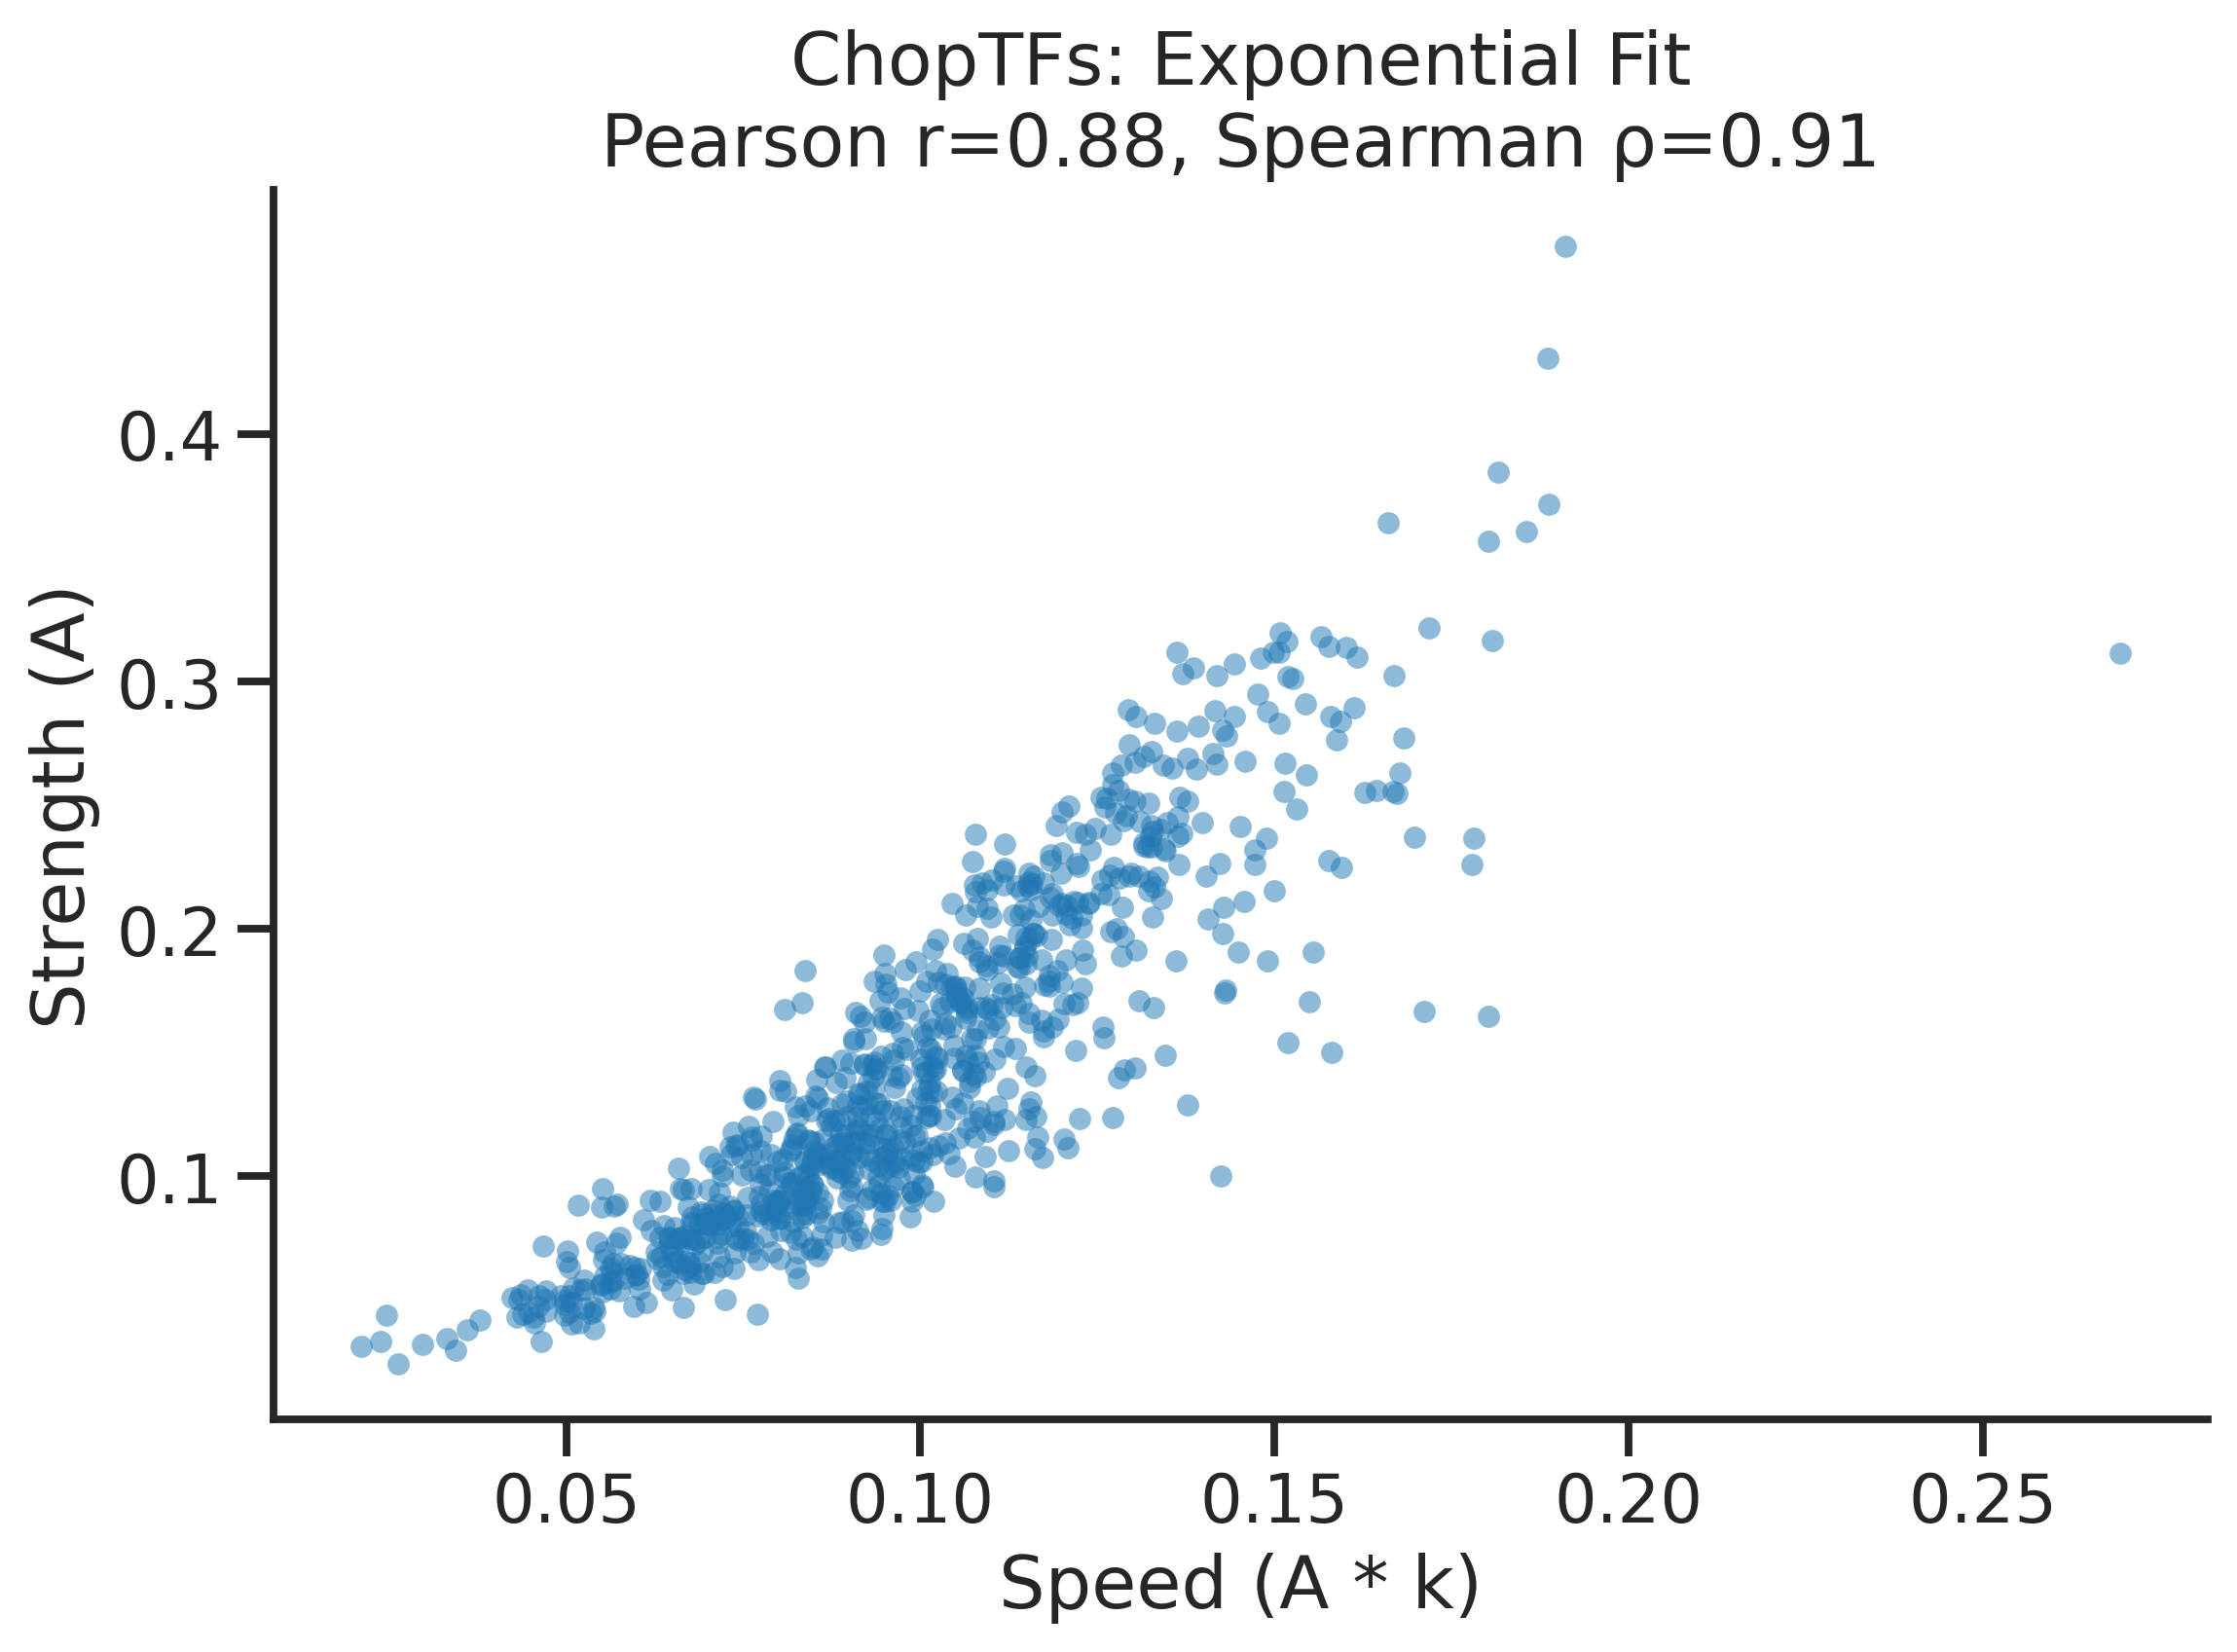

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

sns.set_context('talk')

# --- calculate correlations ---
pearson_corr, pearson_p = pearsonr(ok['k'], ok ['A*k'])
spearman_corr, spearman_p = spearmanr(ok['k'], ok ['A*k'])

print(f"Pearson r = {pearson_corr:.3f}, p = {pearson_p:.3g}")
print(f"Spearman rho = {spearman_corr:.3f}, p = {spearman_p:.3g}")

# --- plot ---
fig, ax = plt.subplots(figsize=(8, 6), dpi = 300)

sc = ax.scatter(
    ok['k'], ok['A*k'],
    alpha=0.5,
    s=30,
    linewidths=0
)


ax.set_xlabel('Speed (A * k)')
ax.set_ylabel('Strength (A)')
ax.set_title(f'ChopTFs: Exponential Fit\nPearson r={pearson_corr:.2f}, Spearman ρ={spearman_corr:.2f}')

#ax.set_xlim(-0.01, 0.2)
#ax.set_ylim(0.5,2.7)

plt.tight_layout()
sns.despine()
plt.show()

Pearson r = -0.718, p = 4.52e-136
Spearman rho = -0.744, p = 1.06e-150


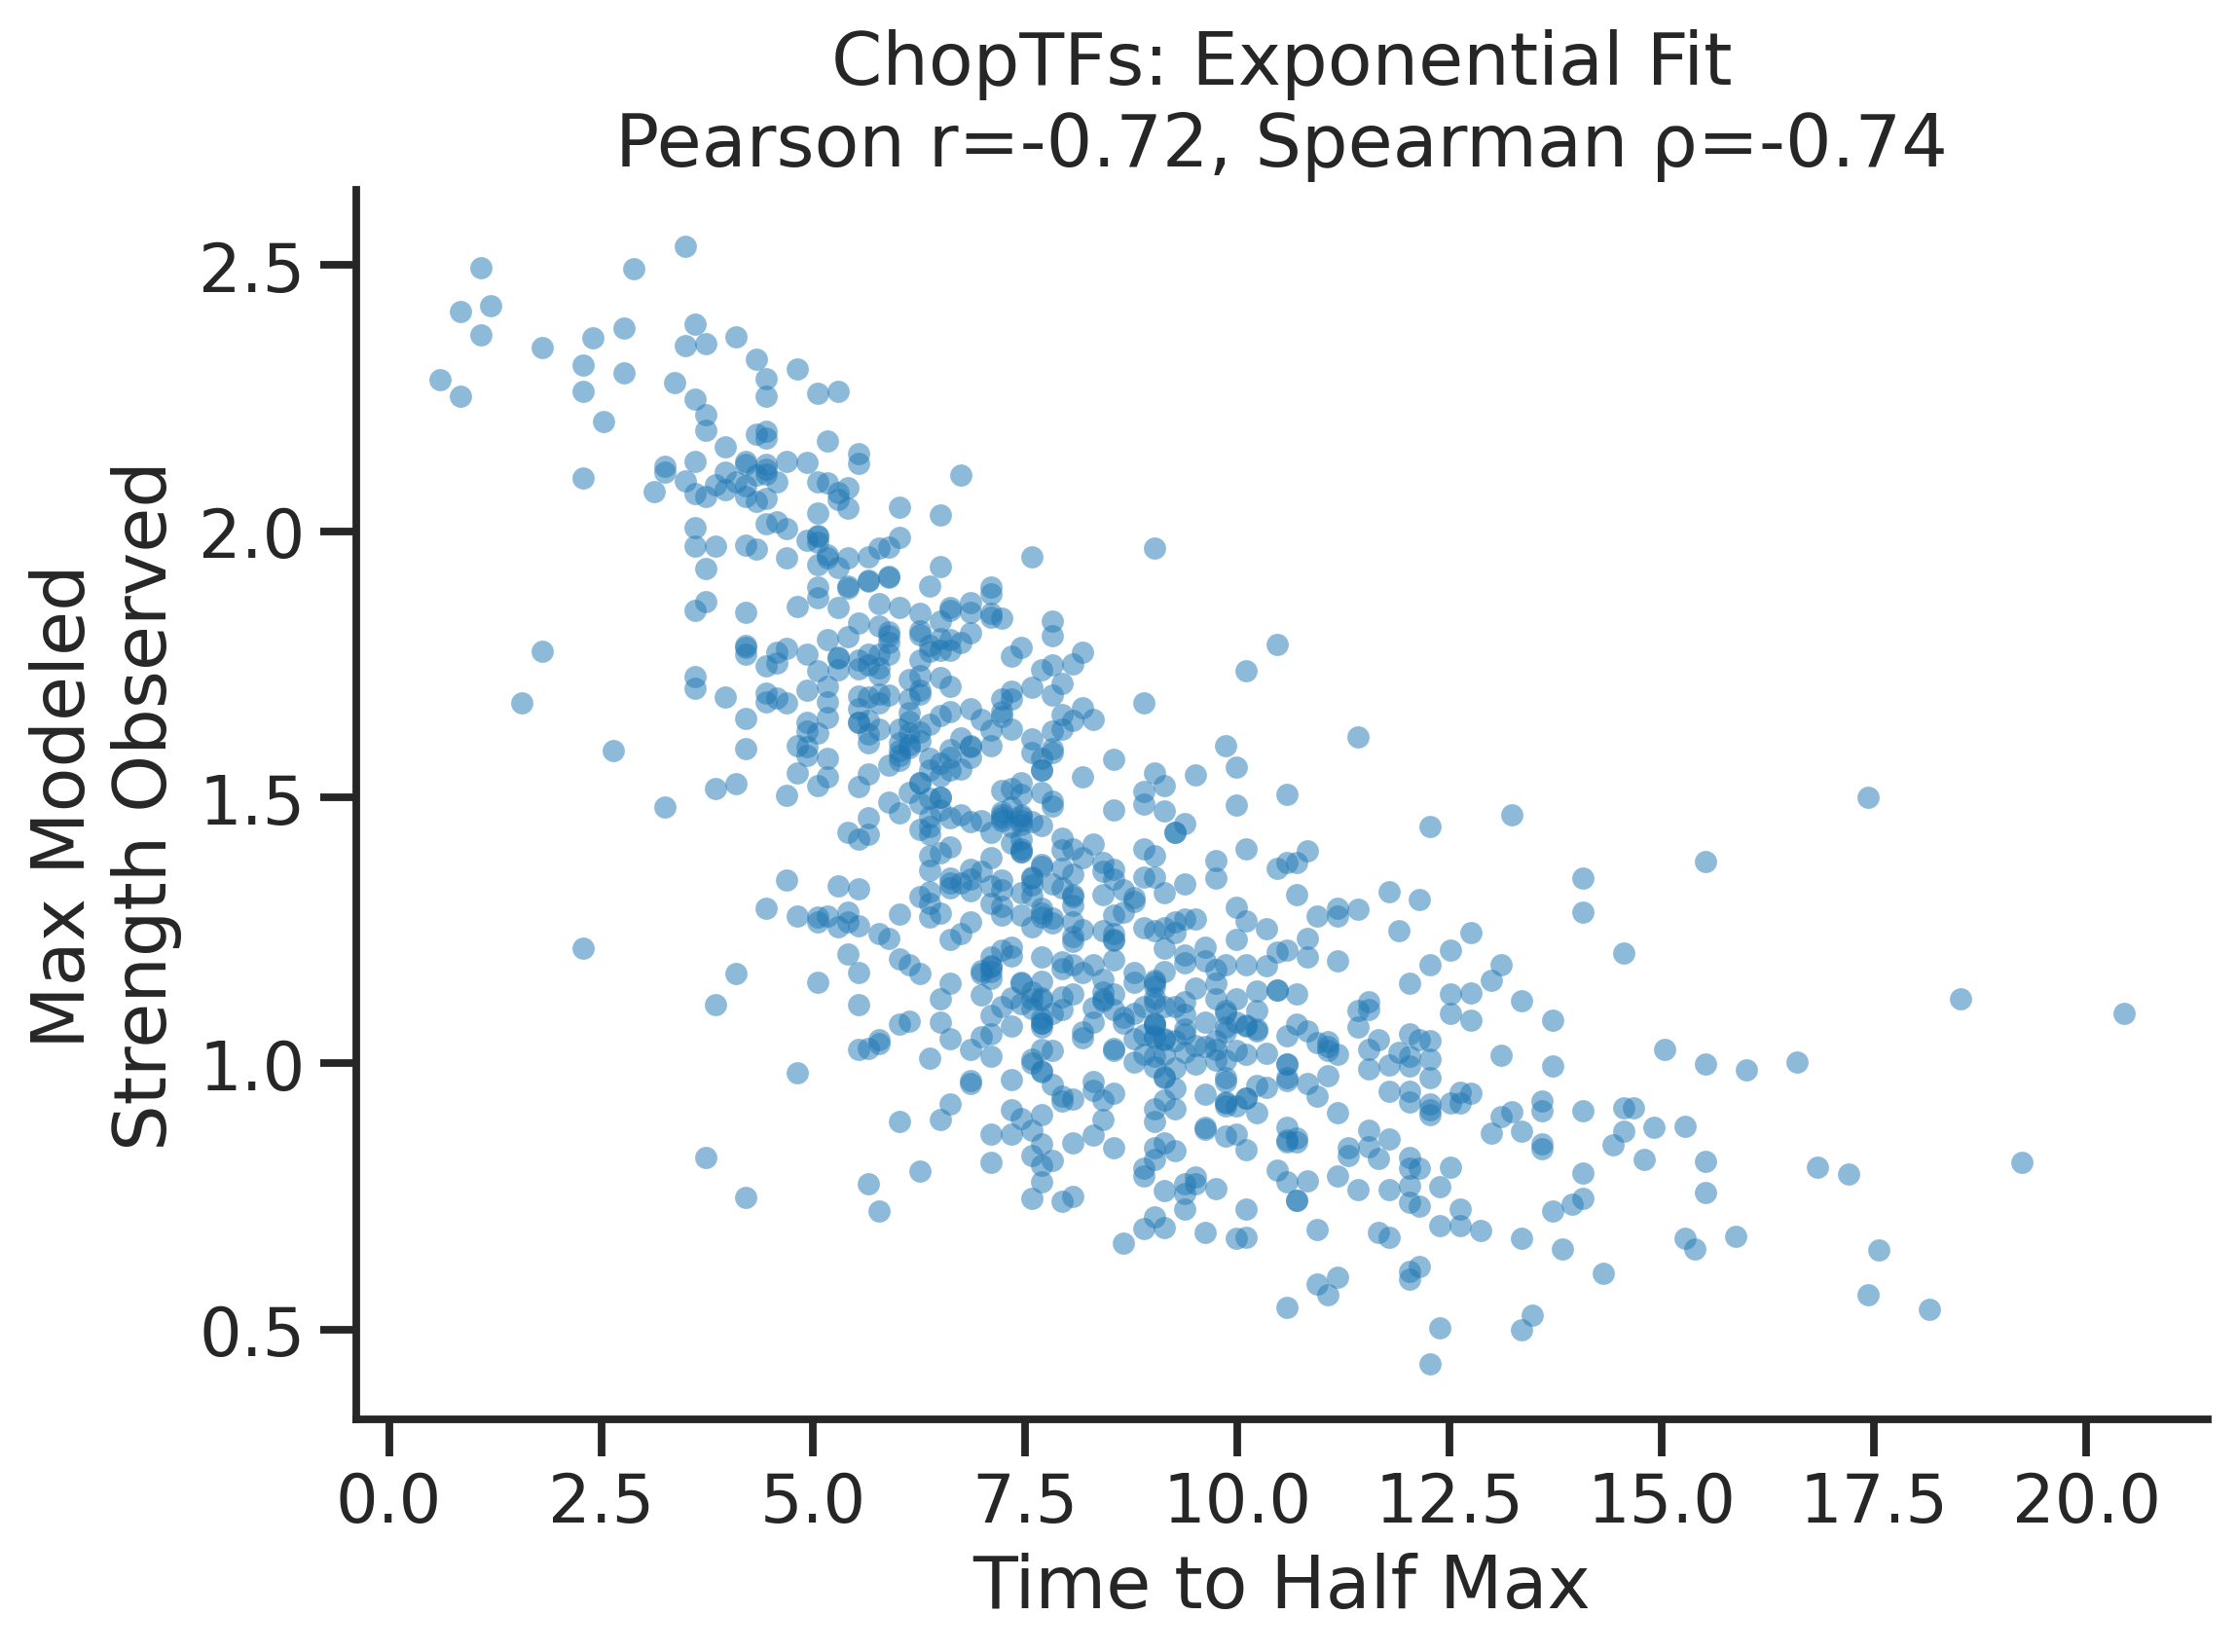

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

sns.set_context('talk')

# --- calculate correlations ---
pearson_corr, pearson_p = pearsonr(ok['t_half_model_empirical'], ok ['obs_max'])
spearman_corr, spearman_p = spearmanr(ok['t_half_model_empirical'], ok ['obs_max'])

print(f"Pearson r = {pearson_corr:.3f}, p = {pearson_p:.3g}")
print(f"Spearman rho = {spearman_corr:.3f}, p = {spearman_p:.3g}")

# --- plot ---
fig, ax = plt.subplots(figsize=(8, 6), dpi = 300)

sc = ax.scatter(
    ok['t_half_model_empirical'], ok['obs_max'],
    alpha=0.5,
    s=30,
    linewidths=0
)


ax.set_xlabel('Time to Half Max')
ax.set_ylabel('Max Modeled\nStrength Observed')
ax.set_title(f'ChopTFs: Exponential Fit\nPearson r={pearson_corr:.2f}, Spearman ρ={spearman_corr:.2f}')

#ax.set_xlim(-0.01, 0.2)
# ax.set_ylim(0,5)

plt.tight_layout()
sns.despine()
plt.show()

Pearson r = 0.573, p = 2.1e-75
Spearman rho = 0.590, p = 7.01e-81


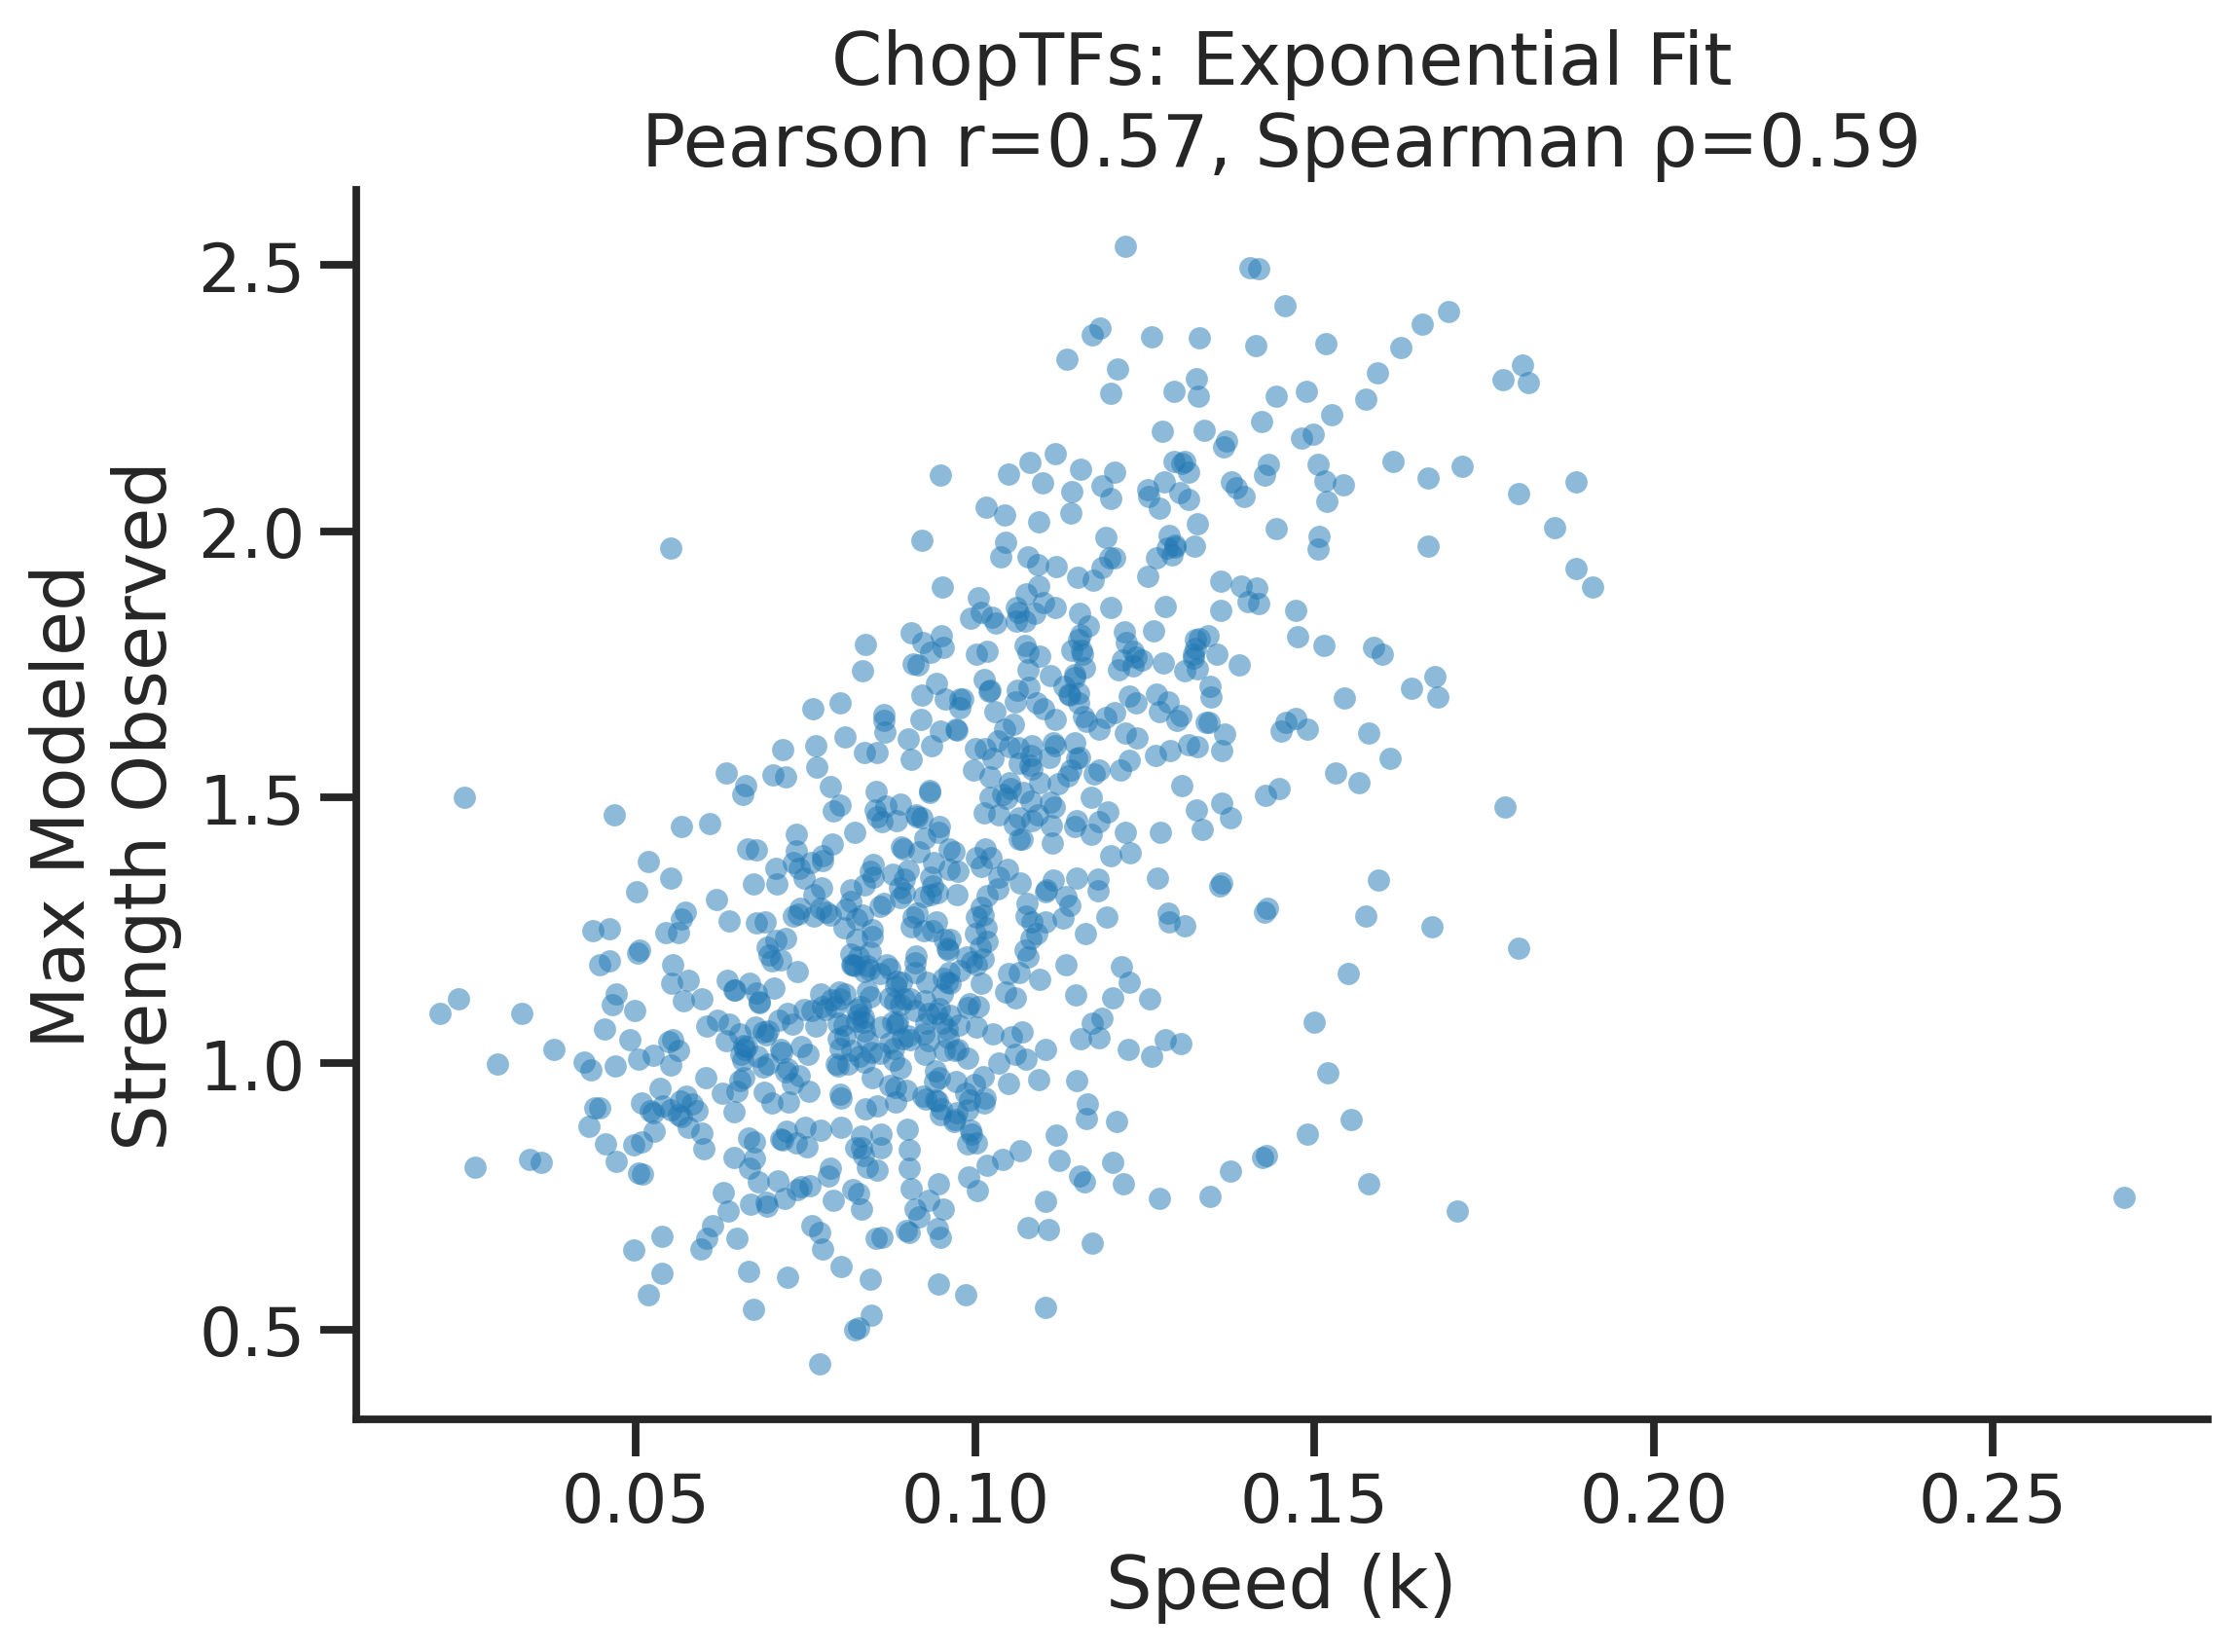

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

sns.set_context('talk')

# --- calculate correlations ---
pearson_corr, pearson_p = pearsonr(ok['k'], ok ['obs_max'])
spearman_corr, spearman_p = spearmanr(ok['k'], ok ['obs_max'])

print(f"Pearson r = {pearson_corr:.3f}, p = {pearson_p:.3g}")
print(f"Spearman rho = {spearman_corr:.3f}, p = {spearman_p:.3g}")

# --- plot ---
fig, ax = plt.subplots(figsize=(8, 6), dpi = 300)

sc = ax.scatter(
    ok['k'], ok['obs_max'],
    alpha=0.5,
    s=30,
    linewidths=0
)


ax.set_xlabel('Speed (k)')
ax.set_ylabel('Max Modeled\nStrength Observed')
ax.set_title(f'ChopTFs: Exponential Fit\nPearson r={pearson_corr:.2f}, Spearman ρ={spearman_corr:.2f}')

#ax.set_xlim(-0.01, 0.2)
# ax.set_ylim(0,5)

plt.tight_layout()
sns.despine()
plt.show()

Pearson r = 0.573, p = 2.1e-75
Spearman rho = 0.590, p = 7.01e-81


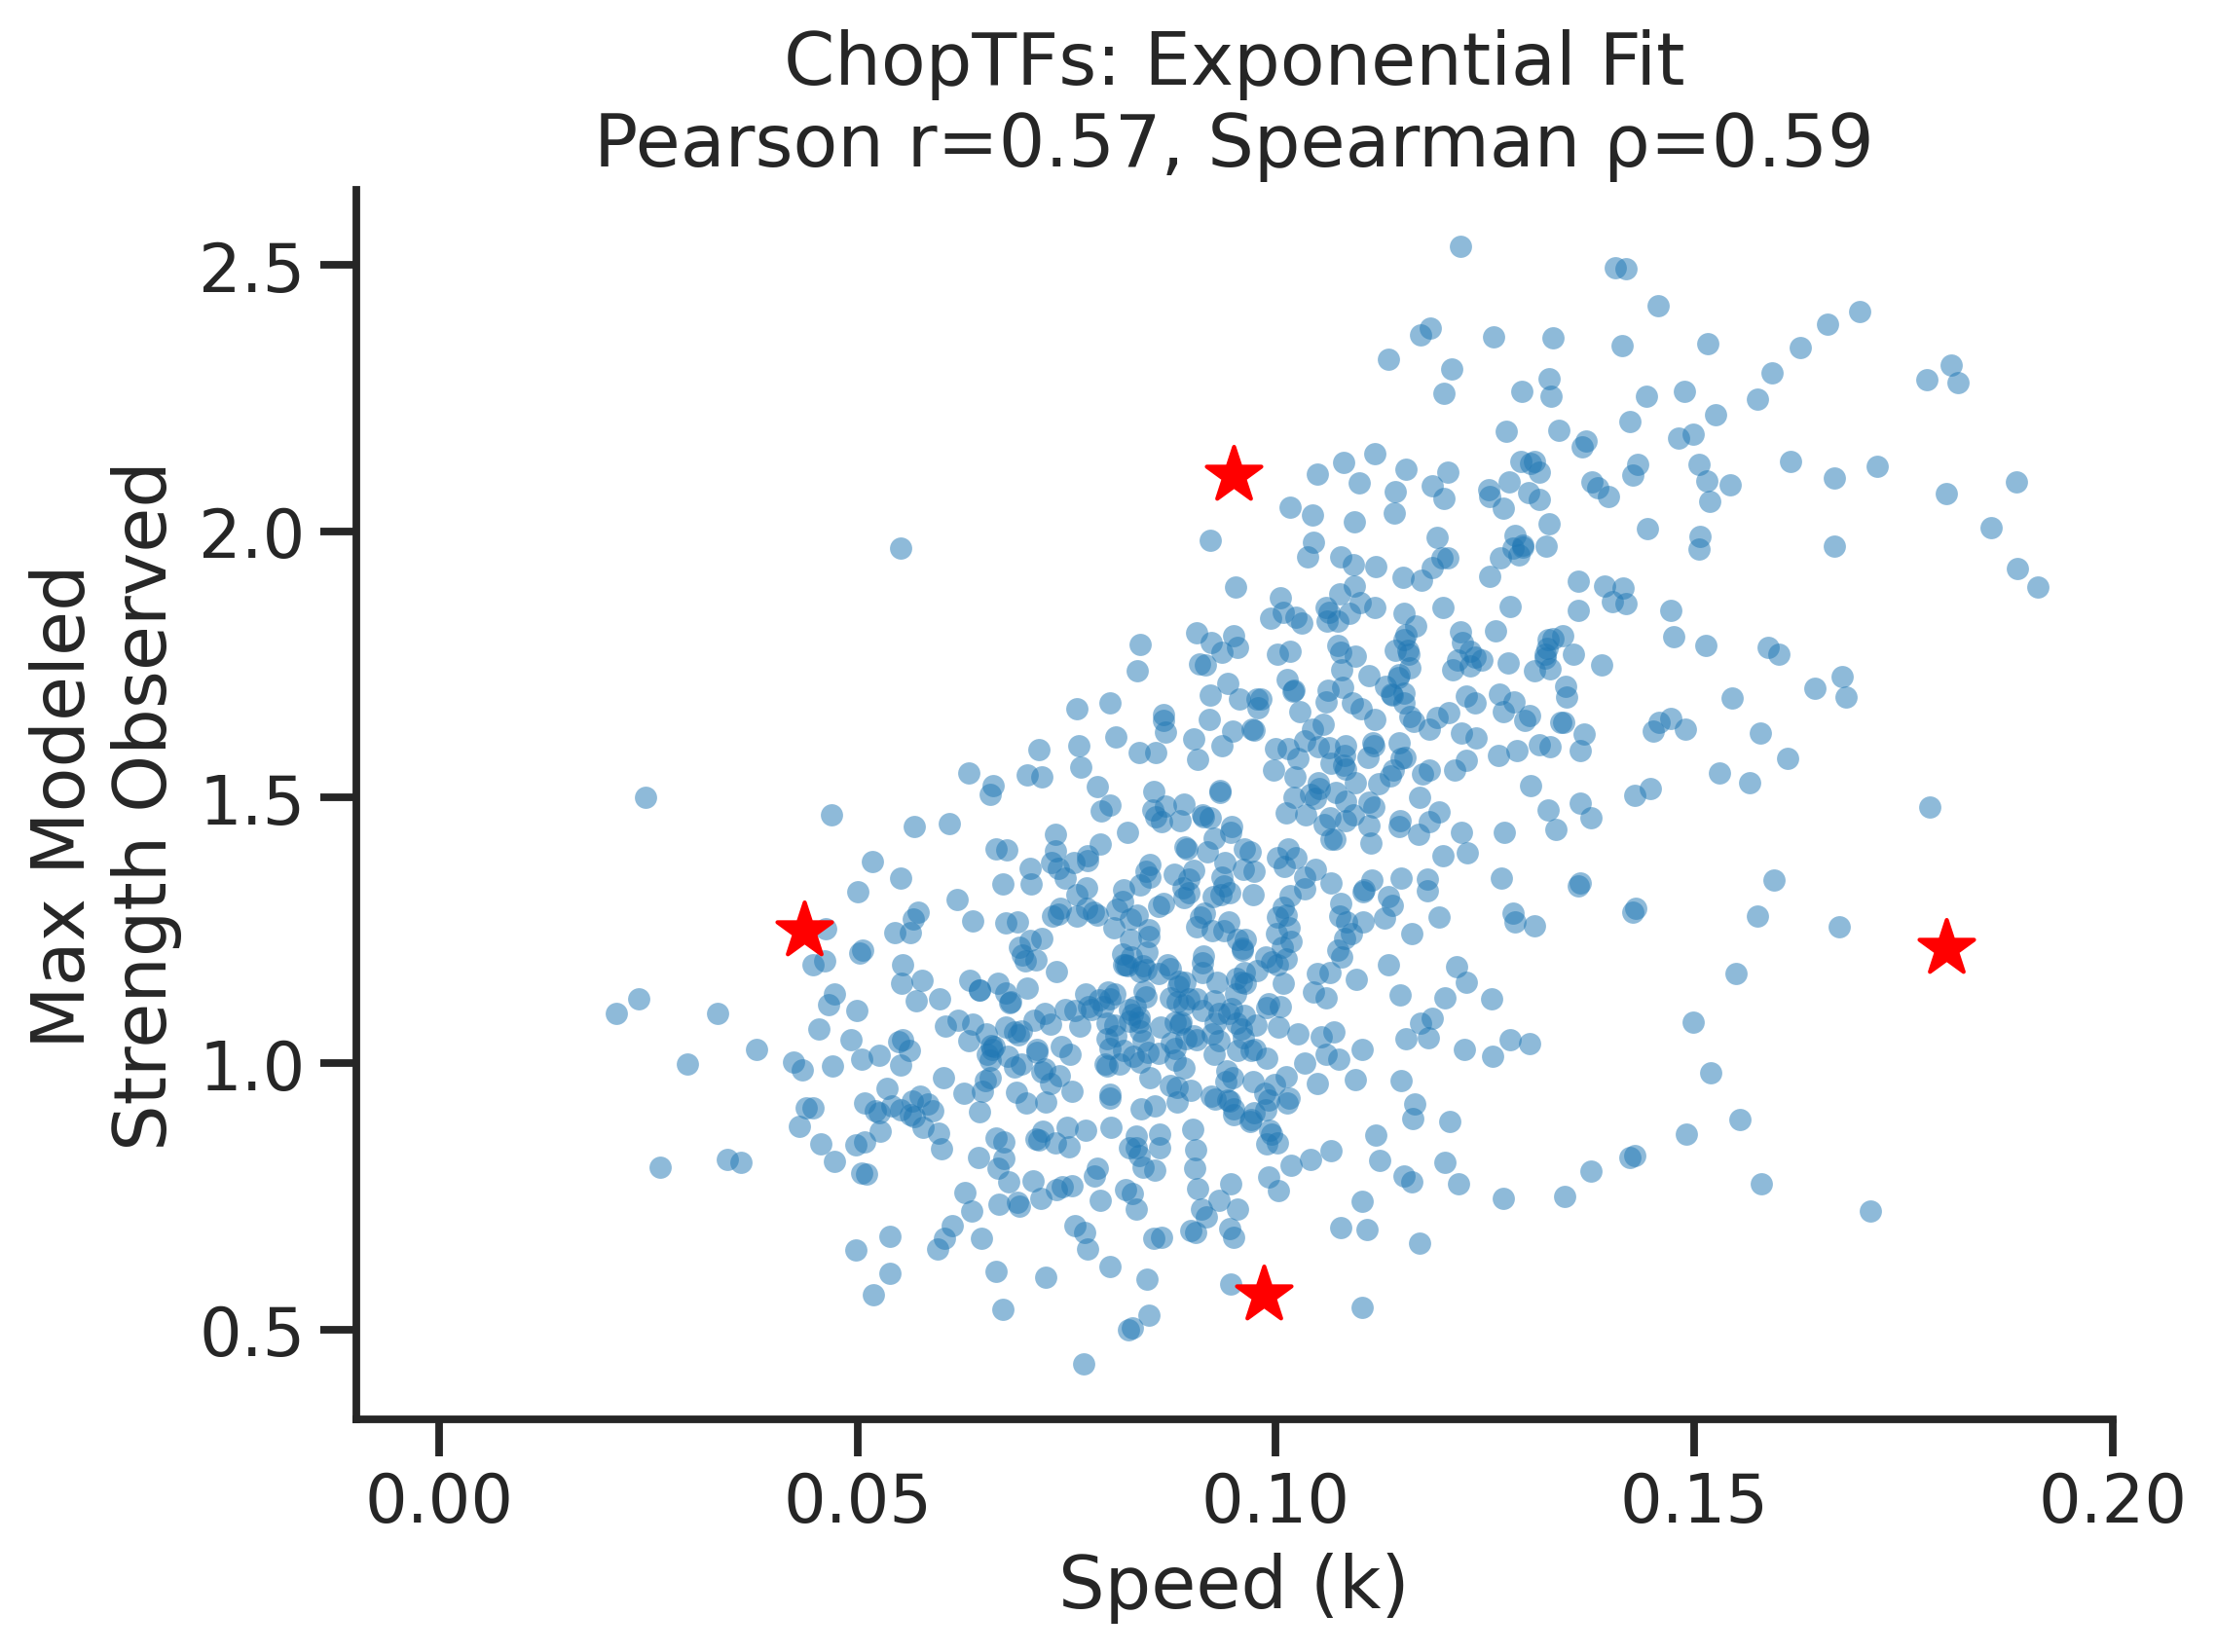

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

sns.set_context('talk')

# --- calculate correlations ---
pearson_corr, pearson_p = pearsonr(ok['k'], ok ['obs_max'])
spearman_corr, spearman_p = spearmanr(ok['k'], ok ['obs_max'])

print(f"Pearson r = {pearson_corr:.3f}, p = {pearson_p:.3g}")
print(f"Spearman rho = {spearman_corr:.3f}, p = {spearman_p:.3g}")

# --- plot ---
fig, ax = plt.subplots(figsize=(8, 6), dpi = 300)

sc = ax.scatter(
    ok['k'], ok['obs_max'],
    alpha=0.5,
    s=30,
    linewidths=0
)

ax.scatter(
    to_plot['k'], to_plot['obs_max'],
    alpha=1,
    s=200,
    linewidths=1,
    edgecolors='red',
    color='red',
    marker = '*'
)
ax.set_xlabel('Speed (k)')
ax.set_ylabel('Max Modeled\nStrength Observed')
ax.set_title(f'ChopTFs: Exponential Fit\nPearson r={pearson_corr:.2f}, Spearman ρ={spearman_corr:.2f}')

ax.set_xlim(-0.01, 0.2)
# ax.set_ylim(0,5)

plt.tight_layout()
sns.despine()
plt.show()

In [23]:
 sns.color_palette('colorblind', n_colors=len(to_plot))

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0)]

In [24]:
max_time = 60

<Figure size 1920x1440 with 0 Axes>

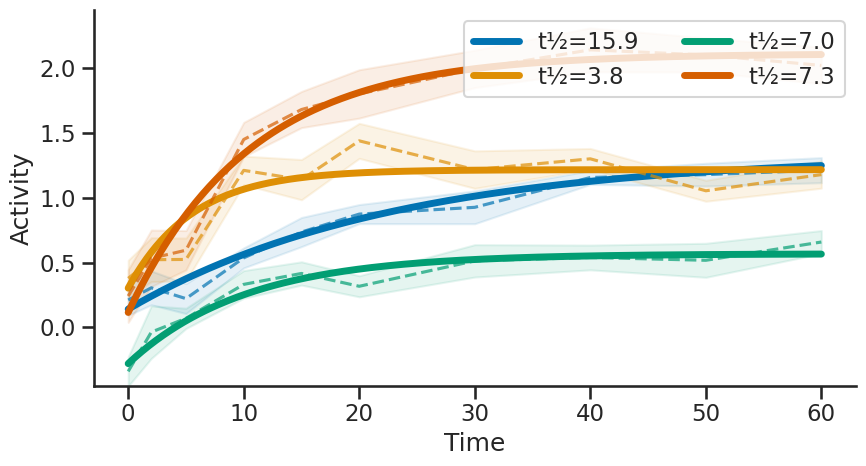

In [25]:
plt.figure(dpi=300)

def rising_exponential(t, A, k, C):
    return A * (1 - np.exp(-k * t)) + C

t_fine = np.linspace(0, max_time, 300)
fig, ax = plt.subplots(figsize=(9,5))

colors = sns.color_palette('colorblind', n_colors=len(to_plot))

for (_, row), color in zip(to_plot.iterrows(), colors):
    grp = active_tile_activities_count_filtered[active_tile_activities_count_filtered['ADseq'] == row['ADseq']].sort_values('time')
    t = grp['time'].values
    y = grp['activity'].values
    sigma = grp['error'].values

    ax.fill_between(t, y - sigma, y + sigma, color=color, alpha=0.1)
    ax.plot(t, y, color=color, markersize=4, alpha=0.7, linestyle='dashed')
    ax.plot(t_fine, rising_exponential(t_fine, row['A'], row['k'], row['C']),
            color=color, linewidth=5, alpha=1,
            label=f"t½={row['t_half']:.1f}")

ax.set_xlabel('Time')
ax.set_ylabel('Activity')

# get lowest observed value across all plotted sequences
grps = active_tile_activities_count_filtered[active_tile_activities_count_filtered['ADseq'].isin(to_plot['ADseq'])]
y_min = (grps['activity'] - grps['error']).min()
ax.set_ylim(bottom=y_min)

# Add legend outside the plot
ax.legend(bbox_to_anchor=(1,1), loc='upper right', ncols = 2)
sns.despine()
plt.tight_layout()
plt.show()

<Figure size 1920x1440 with 0 Axes>

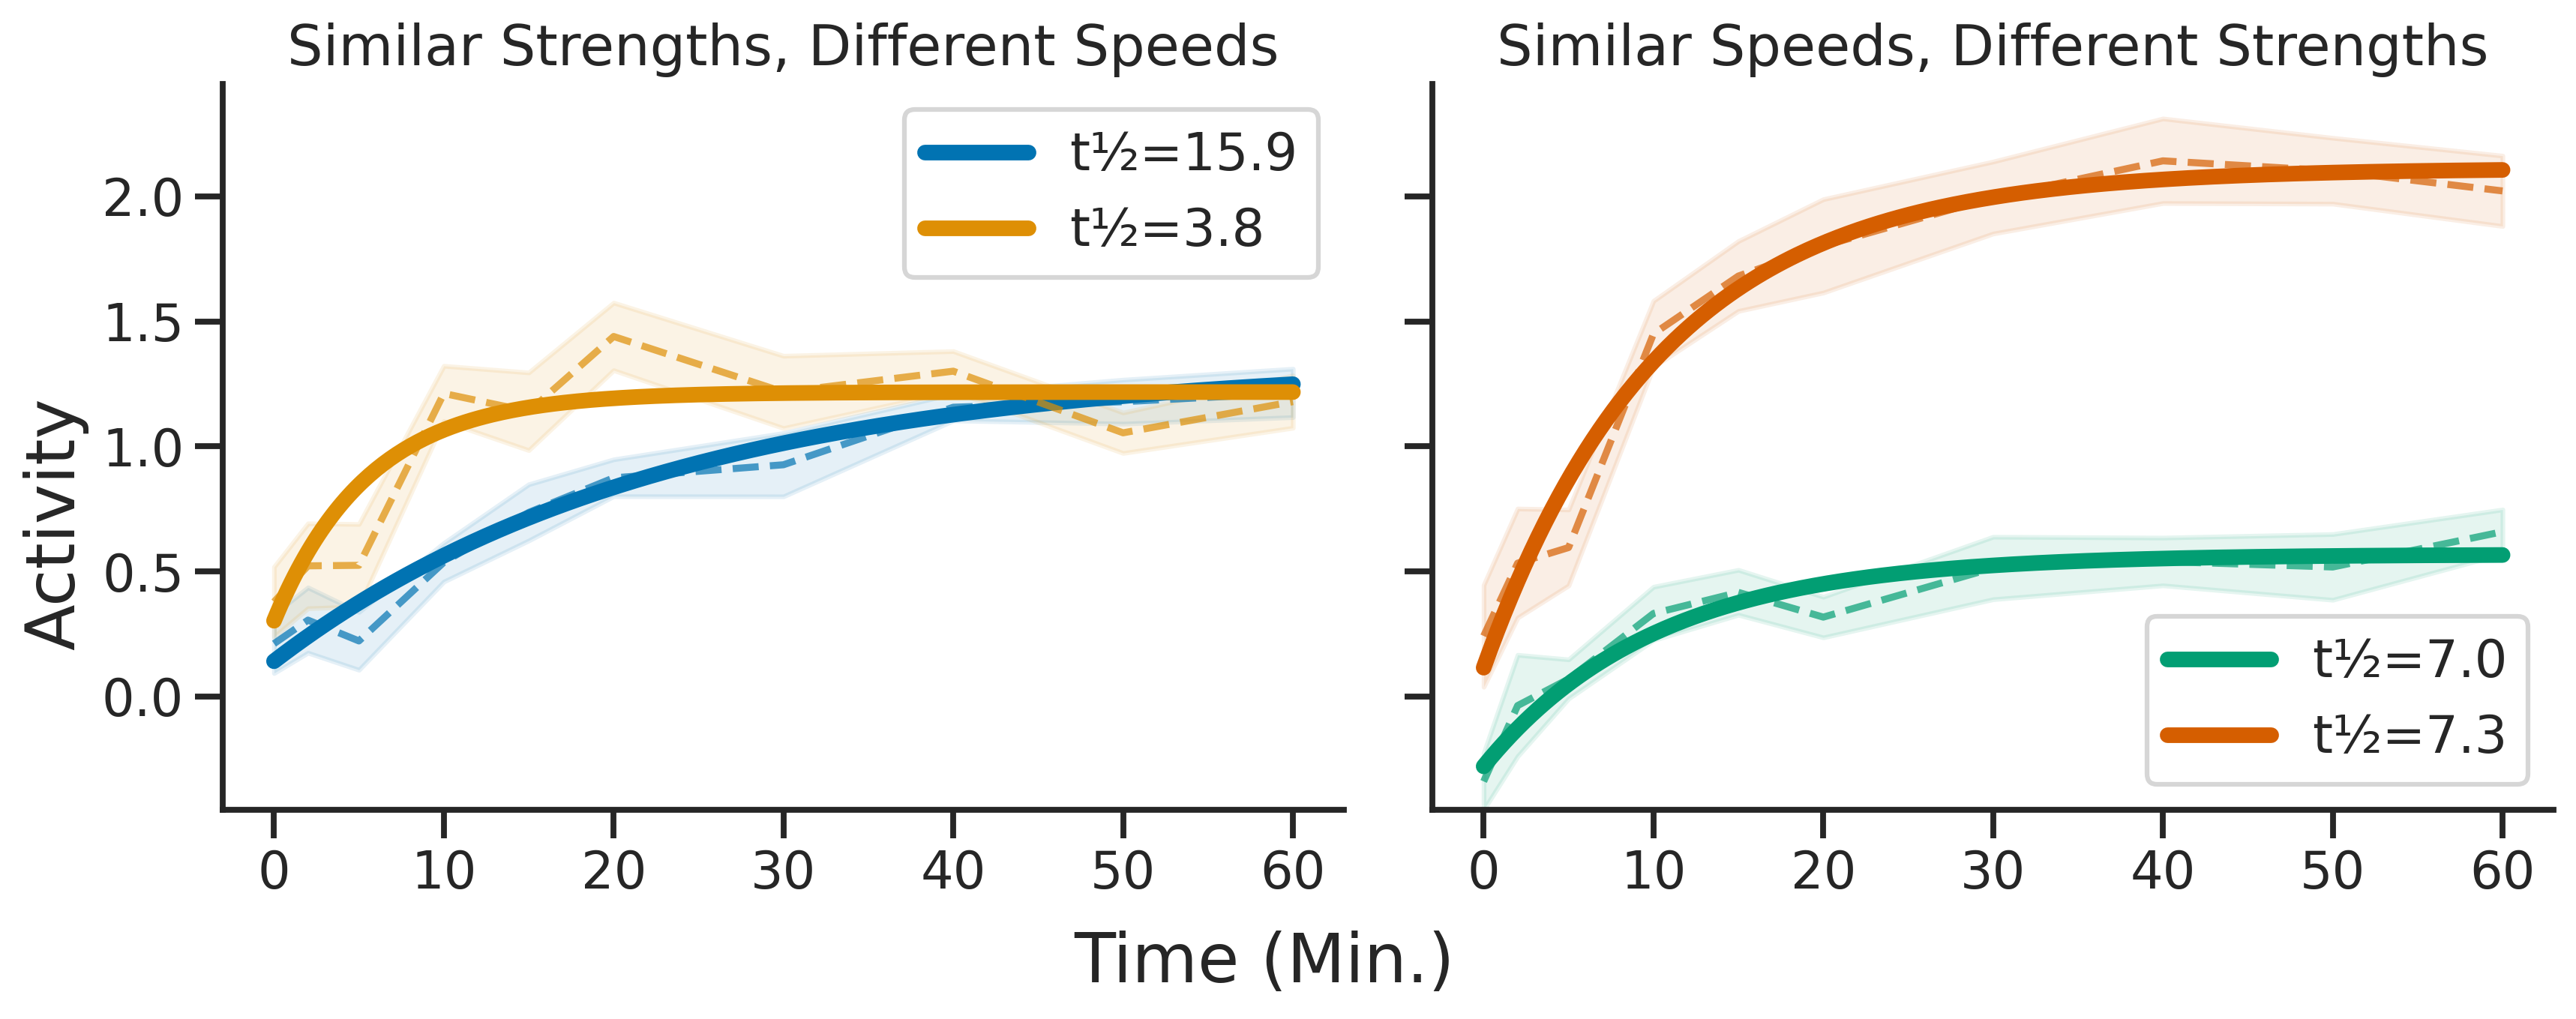

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(dpi=300)

def rising_exponential(t, A, k, C):
    return A * (1 - np.exp(-k * t)) + C

t_fine = np.linspace(0, max_time, 300)

fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True, dpi = 300)

# Colors for 4 sequences
colors = sns.color_palette('colorblind', n_colors=len(to_plot))

# --- first subplot: sequences 1 and 3 ---
for idx in [0, 1]:
    row = to_plot.iloc[idx]
    grp = active_tile_activities_count_filtered[active_tile_activities_count_filtered['ADseq'] == row['ADseq']].sort_values('time')
    t = grp['time'].values
    y = grp['activity'].values
    sigma = grp['error'].values

    axs[0].fill_between(t, y - sigma, y + sigma, color=colors[idx], alpha=0.1)
    axs[0].plot(t, y, color=colors[idx], markersize=4, alpha=0.7, linestyle='dashed')
    axs[0].plot(t_fine, rising_exponential(t_fine, row['A'], row['k'], row['C']),
                color=colors[idx], linewidth=5, alpha=1,
                label=f"t½={row['t_half']:.1f}")

axs[0].set_xlabel('Time')
axs[0].set_ylabel('Activity')
axs[0].legend()
sns.despine(ax=axs[0])
axs[0].set_title("Similar Strengths, Different Speeds")

# --- second subplot: sequences 2 and 4 ---
for idx in [2, 3]:
    row = to_plot.iloc[idx]
    grp = active_tile_activities_count_filtered[active_tile_activities_count_filtered['ADseq'] == row['ADseq']].sort_values('time')
    t = grp['time'].values
    y = grp['activity'].values
    sigma = grp['error'].values

    axs[1].fill_between(t, y - sigma, y + sigma, color=colors[idx], alpha=0.1)
    axs[1].plot(t, y, color=colors[idx], markersize=4, alpha=0.7, linestyle='dashed')
    axs[1].plot(t_fine, rising_exponential(t_fine, row['A'], row['k'], row['C']),
                color=colors[idx], linewidth=5, alpha=1,
                label=f"t½={row['t_half']:.1f}", zorder = 0)

axs[1].set_xlabel('Time')
axs[1].legend()
sns.despine(ax=axs[1])

# Set shared y-axis minimum
grps = active_tile_activities_count_filtered[active_tile_activities_count_filtered['ADseq'].isin(to_plot['ADseq'])]
y_min = (grps['activity'] - grps['error']).min()
for ax in axs:
    ax.set_ylim(bottom=y_min)
    ax.set_xlabel("")
    ax.set_ylabel("")

fig.supxlabel("Time (Min.)", y = 0.08)
fig.supylabel("Activity", x = 0.04)

axs[1].set_title("Similar Speeds, Different Strengths")

plt.tight_layout()
plt.show()

# Subtracting t = 0 from everything

In [41]:
# Make a copy to avoid modifying original
activities_norm = active_tile_activities_count_filtered.copy()

# Get the time=0 activity for each ADseq
baseline = activities_norm[activities_norm["time"] == 0][["ADseq", "activity"]].set_index("ADseq")

# Subtract baseline from all time points
activities_norm = activities_norm.join(baseline, on="ADseq", rsuffix="_0")
activities_norm["activity_norm"] = activities_norm["activity"] - activities_norm["activity_0"]

# Optional: remove negative values if your exponential fit cannot handle them
activities_norm["activity_norm"] = activities_norm["activity_norm"].clip(lower=0)

# Now activities_norm["activity_norm"] is ready for exponential fitting
activities_norm = activities_norm.drop(columns = "activity_0")
activities_norm

,ADseq,time,activity,ci_low,ci_hi,class,mean_diff,pval_fdr,error,activity_norm,ci_low_norm,ci_hi_norm
142,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,0,-0.402631,-0.569555,-0.165864,ns,NaN,NaN,0.102982,0.000000,-0.166925,0.236767
143,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,2,0.067719,-0.086268,0.196101,ns,0.470349,0.009113,0.072033,0.470349,0.316362,0.598732
144,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,10,0.423909,0.019486,0.796737,activator,0.826539,0.001168,0.198278,0.826539,0.422117,1.199367
145,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,15,0.786642,0.691610,0.871152,activator,1.189273,0.000881,0.045801,1.189273,1.094241,1.273783
146,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,20,0.567249,0.388742,0.736468,activator,0.969880,0.000730,0.088706,0.969880,0.791373,1.139099
...,...,...,...,...,...,...,...,...,...,...,...,...
118600,YVPTRNTFNYDVKISNDFFDNGDNLYGNDEEVLFYEDNYN,20,1.560700,1.399946,1.635293,activator,1.430020,0.000730,0.060037,1.430020,1.269266,1.504612
118601,YVPTRNTFNYDVKISNDFFDNGDNLYGNDEEVLFYEDNYN,30,1.707046,1.668821,1.736109,activator,1.576366,0.000621,0.017165,1.576366,1.538140,1.605428
118602,YVPTRNTFNYDVKISNDFFDNGDNLYGNDEEVLFYEDNYN,40,1.721909,1.702173,1.740391,activator,1.591228,0.000550,0.009749,1.591228,1.571493,1.609710
118603,YVPTRNTFNYDVKISNDFFDNGDNLYGNDEEVLFYEDNYN,50,1.650853,1.592250,1.699947,activator,1.520173,0.000548,0.027474,1.520173,1.461570,1.569266


In [42]:
last_activity = (
    activities_norm.sort_values("time")
      .groupby("ADseq", as_index=False)
      .tail(1)[["ADseq", "activity"]]
)
min(last_activity["activity"])

0.5123228

In [43]:
fit_results_norm = fit_rising_exponentials(
    activities_norm,
    time_col="time",
    activity_col="activity_norm",
    error_col="error",
    min_points=5,
    subtract_baseline=False,
    verbose=True
)

fit_results_norm

Fitting: 100%|██████████| 857/857 [00:03<00:00, 245.80it/s]


,ADseq,A,A_err,k,k_err,C,C_err,t_half,t_half_err,obs_max,t_half_model_empirical,r_squared,flag
0,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,1.156830,0.101060,0.269285,0.069876,-0.006333,0.100999,2.574025,0.667927,1.150497,2.645291,0.924506,ok
1,AASNSYAIPENELLDEDTMNFISSLKNDLSNISNSLPFEY,1.629568,0.079913,0.132274,0.015466,-0.077405,0.078549,5.240241,0.612717,1.551581,5.651303,0.988783,ok
2,AAVPQQNIAPPFLNTNSSATDSNPNTNLEDSLFFDHDLLS,1.533139,0.098494,0.128593,0.012426,-0.140583,0.100362,5.390225,0.520850,1.391873,6.132265,0.983280,ok
3,AELHNWEPPLYDSVGNHNHAGTMESHPHTNIHEELKEFLS,1.083249,0.101249,0.095808,0.021261,-0.106040,0.095986,7.234779,1.605477,0.973756,8.296593,0.960759,ok
4,AELPRRFMDLESWRIETYNELERWFQVDVPKNFEMMNCKF,1.508101,0.108744,0.117486,0.022559,-0.100613,0.095994,5.899836,1.132839,1.406179,6.492986,0.954109,ok
...,...,...,...,...,...,...,...,...,...,...,...,...,...
852,YNFQNARLLIRKIWQNEADGISEHDLVHMIDELDYNINFA,1.563304,0.073382,0.093508,0.008916,-0.131117,0.073789,7.412734,0.706836,1.426466,8.296593,0.966920,ok
853,YPQDLVSSPAMSHLTANNDDFDDLLSVASMNSNYLLPVNS,1.111708,0.082814,0.079604,0.017816,-0.119915,0.080415,8.707494,1.948791,0.982423,9.979960,0.971080,ok
854,YSLVTGKQPLIPHEMTSCLFPKDVVGLGVDDSMDCFTLIN,1.598856,0.100220,0.111316,0.014868,-0.124865,0.102116,6.226831,0.831686,1.471982,6.973948,0.977314,ok
855,YSNARGSDPSSYAIEGEYKTLATDDLGNILNLNYGETNEV,1.245690,0.098534,0.084823,0.012658,-0.094567,0.104688,8.171657,1.219457,1.143447,9.018036,0.970036,ok


In [44]:
ok_norm = fit_results_norm[
    (fit_results_norm['flag'] == 'ok') &
    (fit_results_norm['r_squared'] > 0.7) 
].copy()

print(f"Keeping {len(ok_norm)} / {len(fit_results_norm)} sequences ({100*len(ok_norm)/len(fit_results_norm):.1f}%)")

Keeping 856 / 857 sequences (99.9%)


In [45]:
ok_norm.to_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/ChopTFs_pipeline/speed/exponential_fit_baseline_norm.csv")

In [46]:
not_ok_norm = fit_results_norm[~fit_results_norm["ADseq"].isin(ok_norm["ADseq"])]
not_ok_norm

,ADseq,A,A_err,k,k_err,C,C_err,t_half,t_half_err,obs_max,t_half_model_empirical,r_squared,flag
314,ILNEYNMNFNDNLGTSTSGKNKSACPSSFDANAMTKINPS,0.75835,0.569439,0.028479,0.045705,0.199495,0.139471,24.339026,39.060752,0.820511,11.422846,0.284402,ok


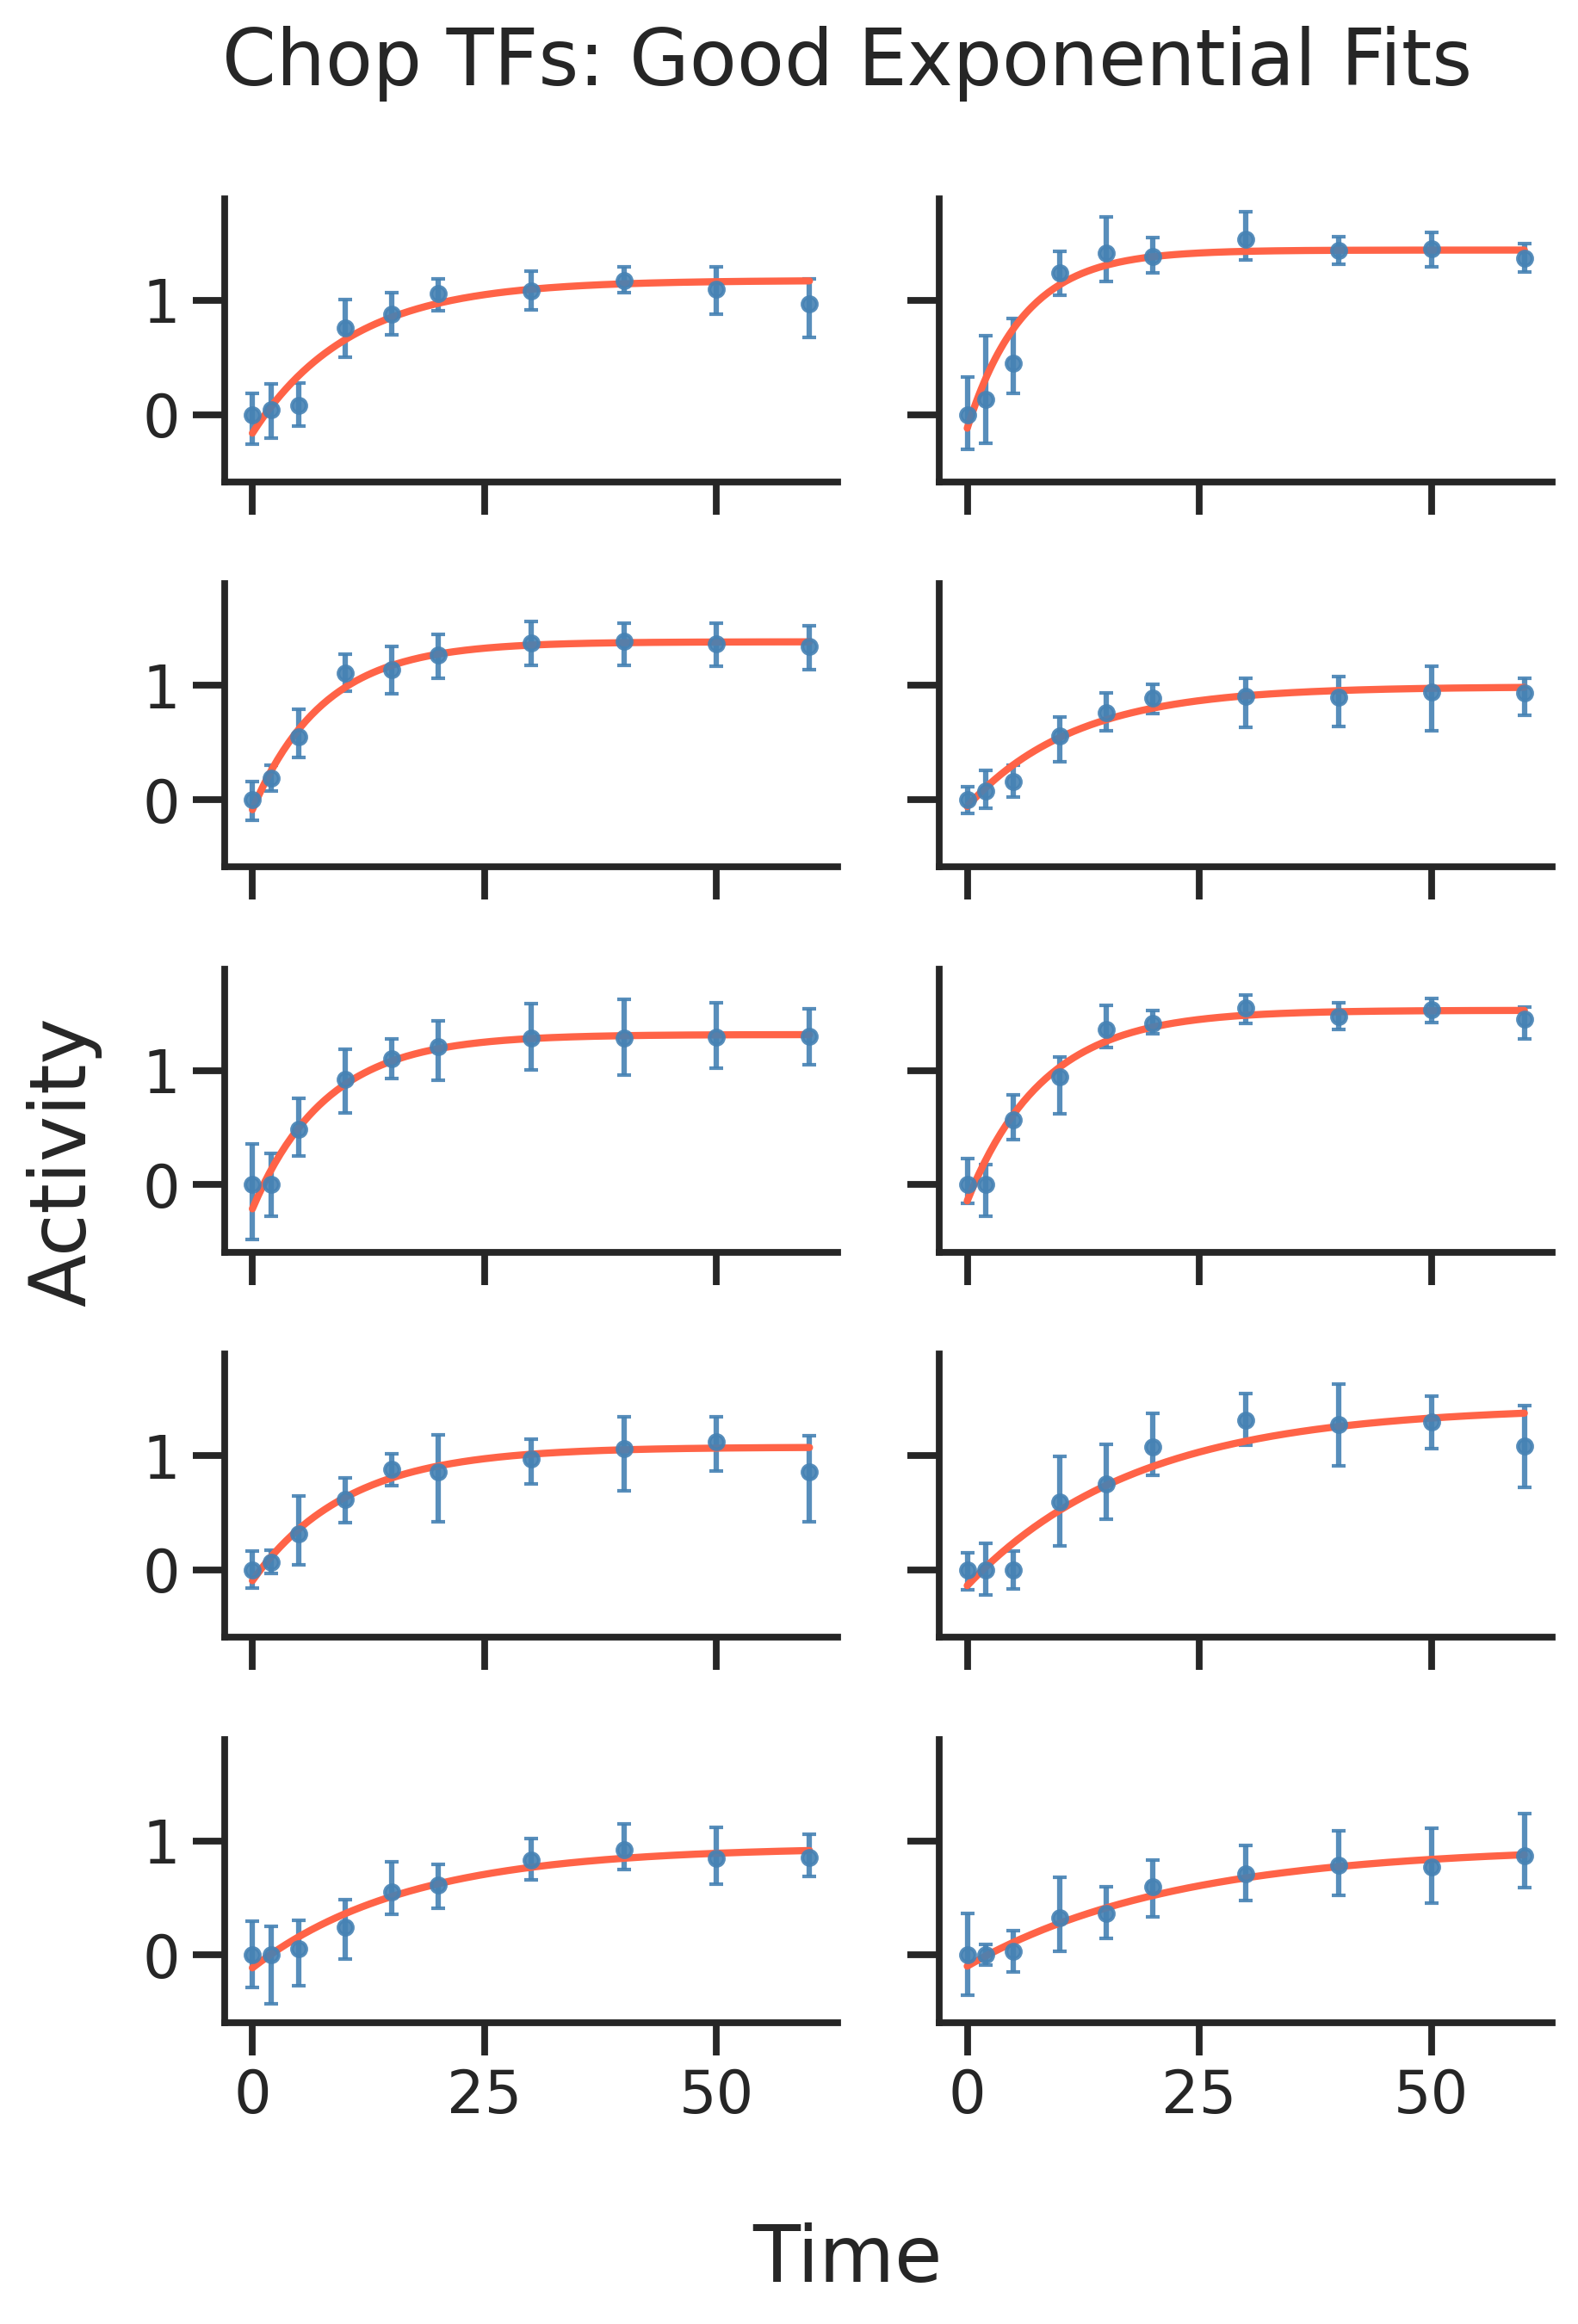

In [47]:
for df, title in zip([ok_norm], ["Good"]):
    sample_adseqs = df.sample(16, random_state=42)['ADseq'].values

    speed_plotting_helpers.plot_model_fits(
        activities=activities_norm,
        fit_results=fit_results_norm,
        sample_adseqs=sample_adseqs,
        model_fn=rising_exponential,
        model_params=['A', 'k', 'C'],
        y_col='activity_norm',
        ci_low_col="ci_low_norm",
        ci_hi_col="ci_hi_norm",
        title=f'Chop TFs: {title} Exponential Fits',
    )

Pearson r = 0.597, p = 7.88e-84
Spearman rho = 0.626, p = 2.34e-94


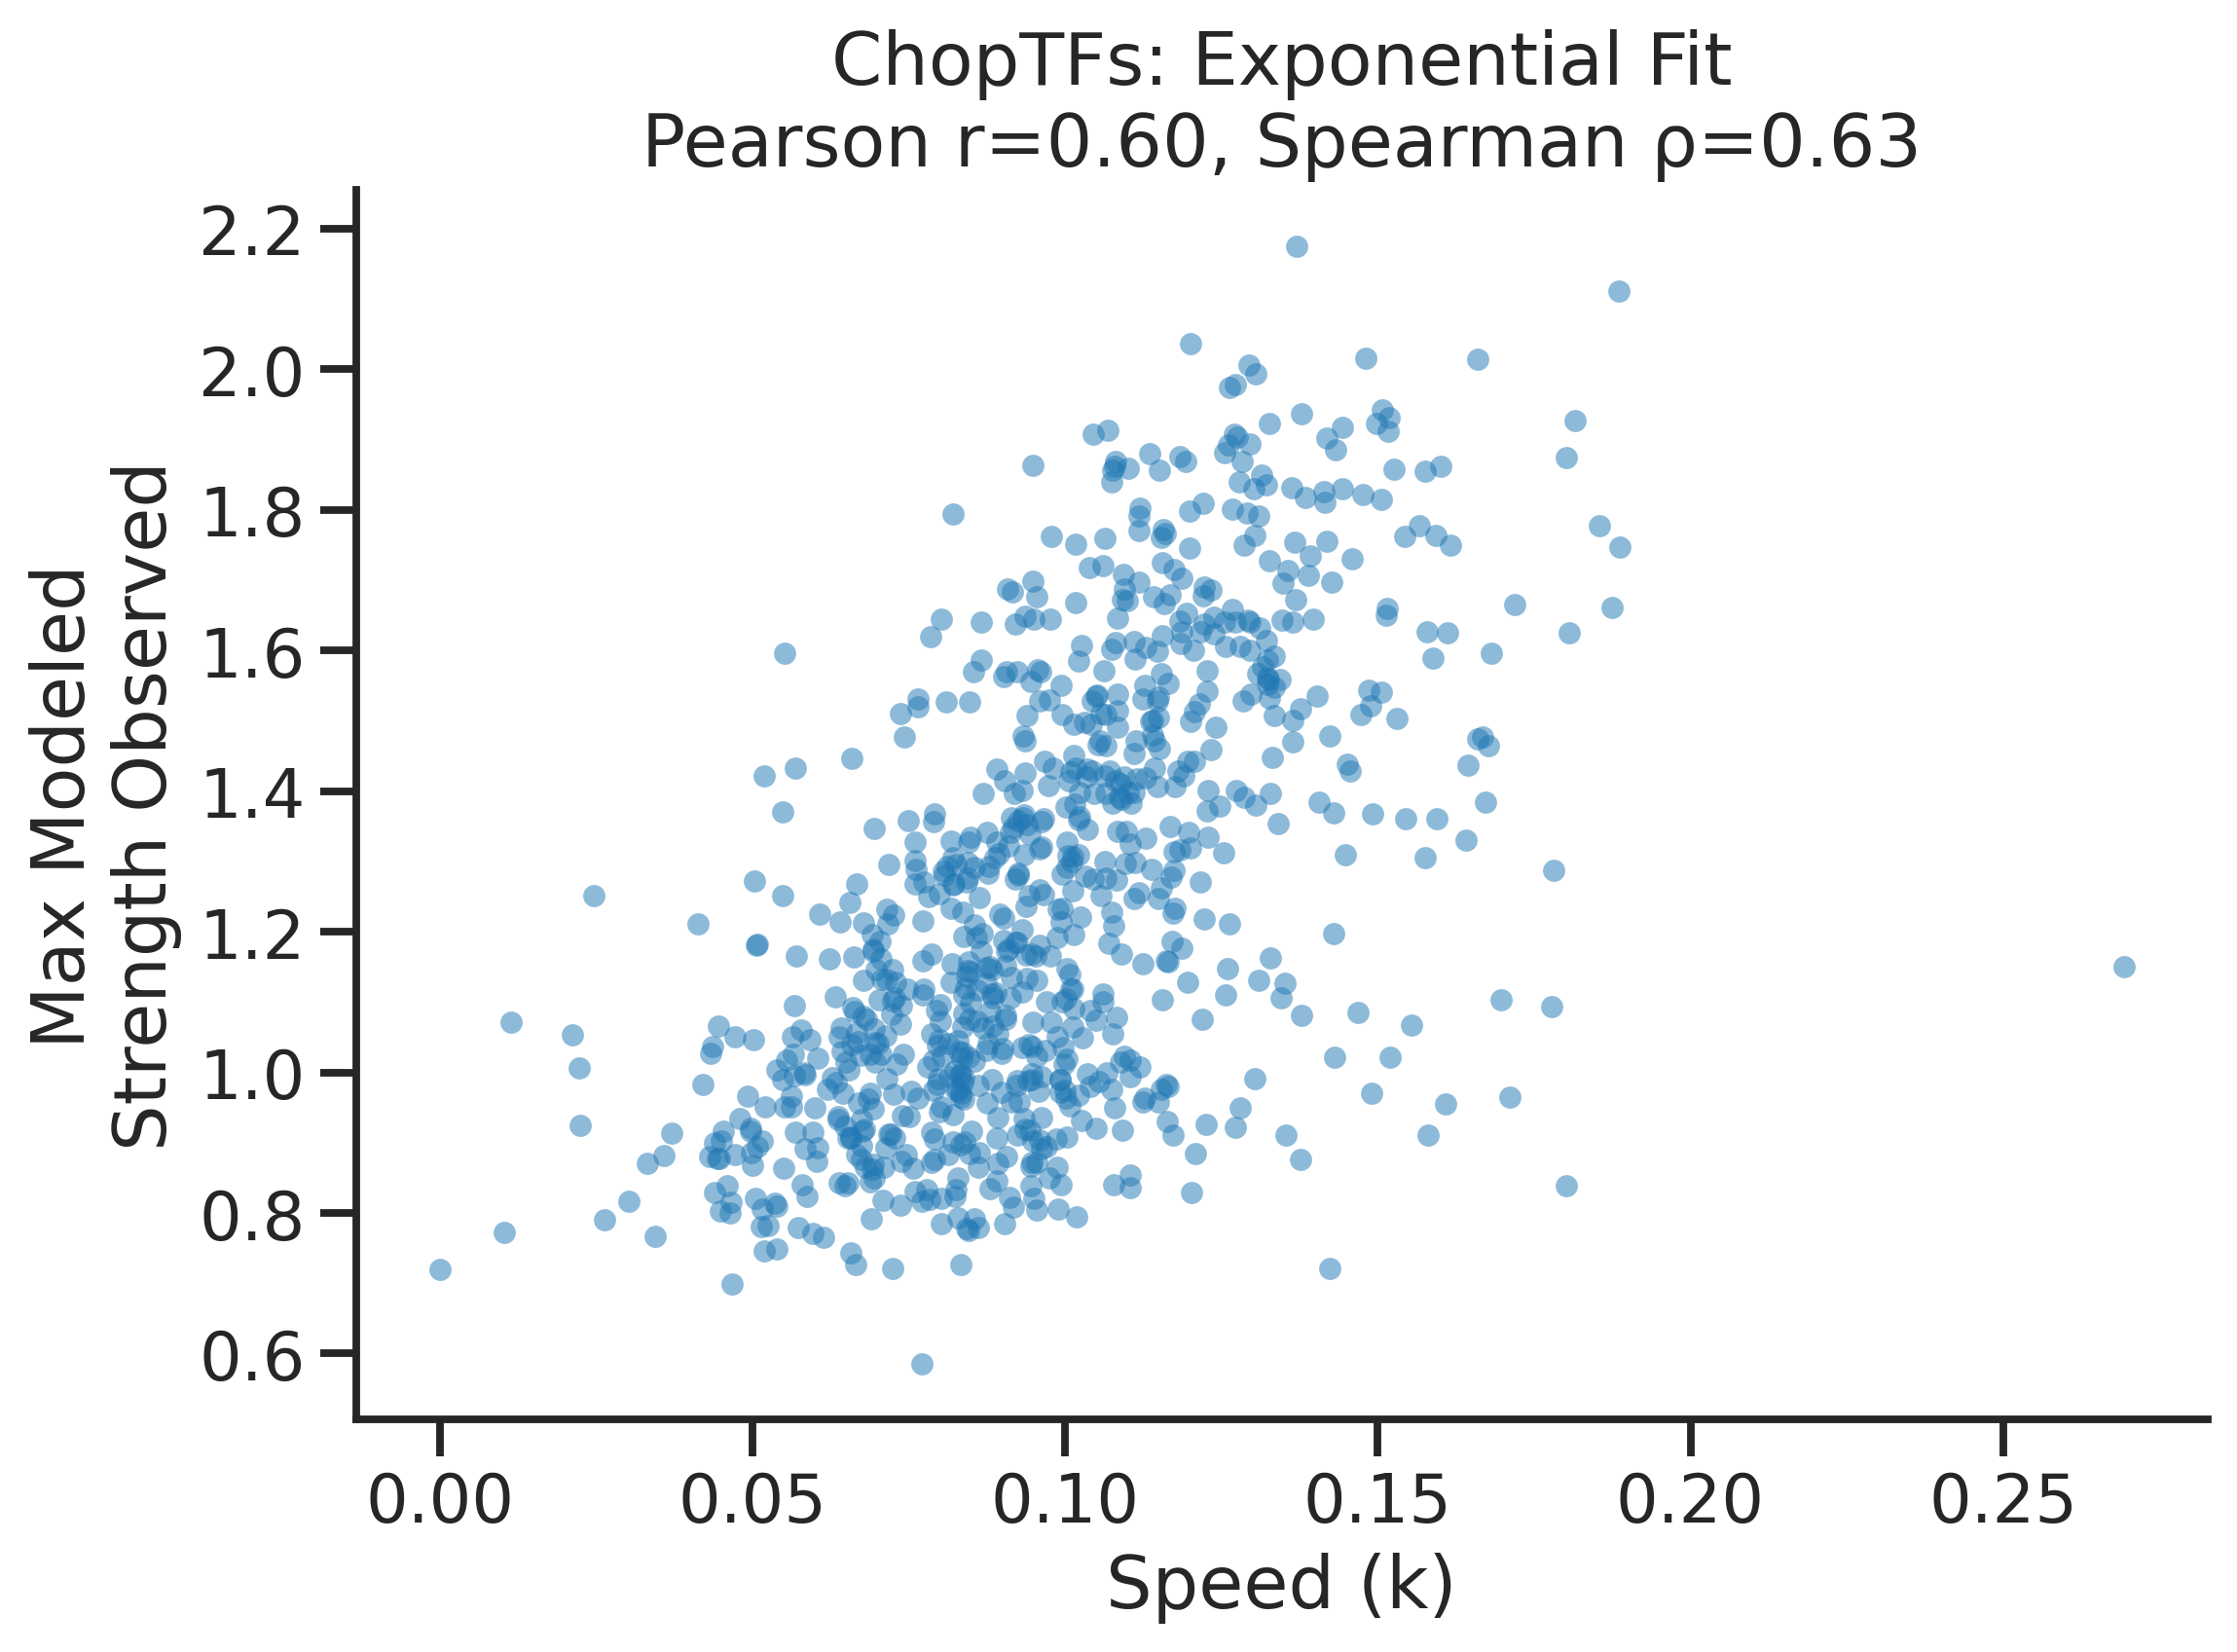

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

sns.set_context('talk')

# --- calculate correlations ---
pearson_corr, pearson_p = pearsonr(ok_norm['k'], ok_norm['obs_max'])
spearman_corr, spearman_p = spearmanr(ok_norm['k'], ok_norm['obs_max'])

print(f"Pearson r = {pearson_corr:.3f}, p = {pearson_p:.3g}")
print(f"Spearman rho = {spearman_corr:.3f}, p = {spearman_p:.3g}")

# --- plot ---
fig, ax = plt.subplots(figsize=(8, 6), dpi = 300)

sc = ax.scatter(
    ok_norm['k'], ok_norm['obs_max'],
    alpha=0.5,
    s=30,
    linewidths=0
)


ax.set_xlabel('Speed (k)')
ax.set_ylabel('Max Modeled\nStrength Observed')
ax.set_title(f'ChopTFs: Exponential Fit\nPearson r={pearson_corr:.2f}, Spearman ρ={spearman_corr:.2f}')

# ax.set_xlim(-0.01, 0.2)
# ax.set_ylim(0,5)

plt.tight_layout()
sns.despine()
plt.show()

In [49]:
import numpy as np
import pandas as pd

# --- filter the valid range first ---
filtered = ok_norm[
    (ok_norm['k'] >= 0) & (ok['k'] <= 0.2) &
    (ok_norm['obs_max'] >= 0) & (ok_norm['obs_max'] <= 5)
].copy()

# --- 1. Similar A, different k ---
A_target = filtered['obs_max'].median()
A_tol = filtered['obs_max'].std() * 0.2  # ±0.3 SD around median

similar_A = filtered[(filtered['obs_max'] >= A_target - A_tol) & (filtered['obs_max'] <= A_target + A_tol)].copy()
similar_A_sorted = similar_A.sort_values('k')

# Pick two sequences with widely separated k
seq_simA_diffk = similar_A_sorted.iloc[[1, -2]]  # first and last k

# --- 2. Similar k, different A ---
k_target = filtered['k'].median()
k_tol = filtered['k'].std() * 0.2  # ±0.3 SD around median

similar_k = filtered[(filtered['k'] >= k_target - k_tol) & (filtered['k'] <= k_target + k_tol)].copy()
similar_k_sorted = similar_k.sort_values('obs_max')

# Pick two sequences with widely separated A
seq_simk_diffA = similar_k_sorted.iloc[[1, -2]]  # lowest and highest A

# --- Combine for inspection ---
to_plot = pd.concat([seq_simA_diffk, seq_simk_diffA])
to_plot

,ADseq,A,A_err,k,k_err,C,C_err,t_half,t_half_err,obs_max,t_half_model_empirical,r_squared,flag
438,LSILDDFFNDGACNEINVILDKAKVRRDFLDYFMPEKEVK,1.480112,0.147082,0.041237,0.010620,-0.143771,0.090807,16.808924,4.328973,1.211671,17.074148,0.948311,ok
718,STDYTPMFEYETYEDNFKEWTSLFDNDIPVTTDDVSLADR,1.266093,0.077032,0.132880,0.016883,-0.102756,0.075974,5.216325,0.662745,1.162900,5.891784,0.977056,ok
717,STDSTPMFEYENLQNNSKEWTSLFDNNIPVTTNNVSLANK,0.900709,0.083201,0.095413,0.018608,-0.093872,0.079582,7.264675,1.416832,0.803897,8.416834,0.976930,ok
410,LKLKNFESSFNIDDFEQFRTEYTIDLSDFQNTERLKFLEE,1.878955,0.089761,0.097806,0.012078,-0.111241,0.084720,7.086979,0.875197,1.762401,7.695391,0.990982,ok


In [50]:
to_plot.to_csv("../../../output/ChopTFs_speed_strength_diff_examples_for_CC.csv")

Pearson r = 0.597, p = 7.88e-84
Spearman rho = 0.626, p = 2.34e-94


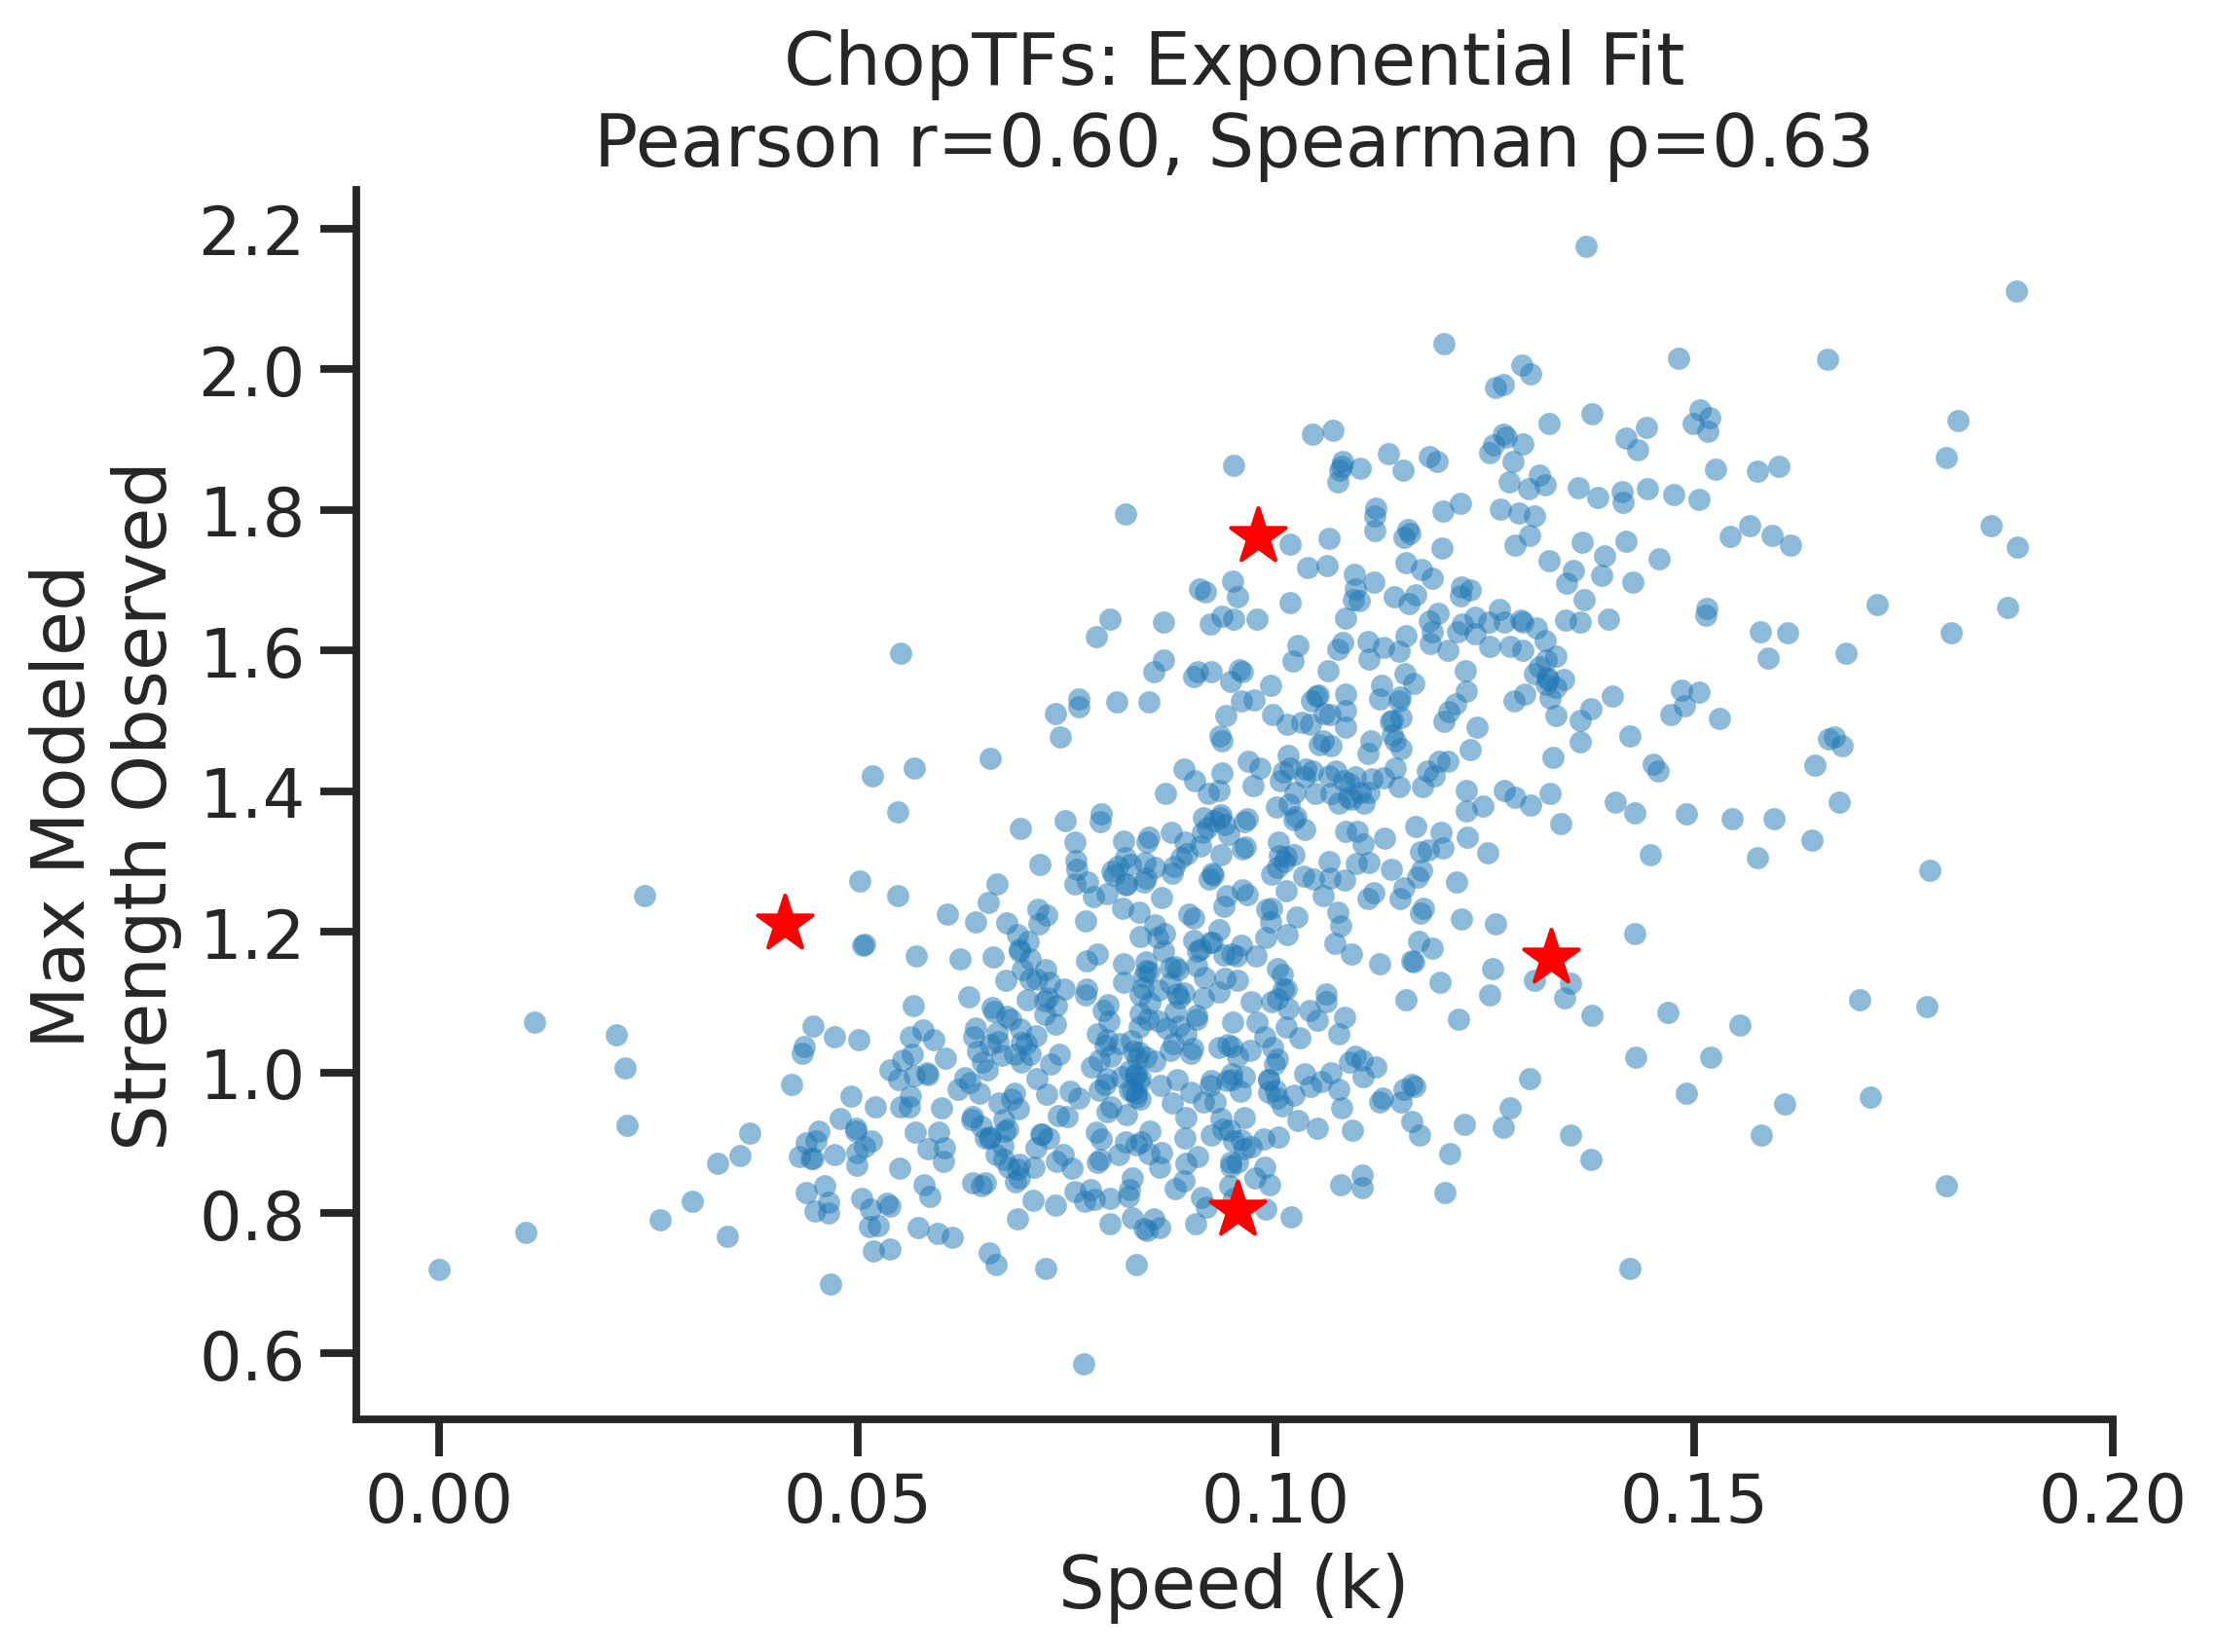

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

sns.set_context('talk')

# --- calculate correlations ---
pearson_corr, pearson_p = pearsonr(ok_norm['k'], ok_norm ['obs_max'])
spearman_corr, spearman_p = spearmanr(ok_norm['k'], ok_norm ['obs_max'])

print(f"Pearson r = {pearson_corr:.3f}, p = {pearson_p:.3g}")
print(f"Spearman rho = {spearman_corr:.3f}, p = {spearman_p:.3g}")

# --- plot ---
fig, ax = plt.subplots(figsize=(8, 6), dpi = 300)

sc = ax.scatter(
    ok_norm['k'], ok_norm['obs_max'],
    alpha=0.5,
    s=30,
    linewidths=0
)

ax.scatter(
    to_plot['k'], to_plot['obs_max'],
    alpha=1,
    s=200,
    linewidths=1,
    edgecolors='red',
    color='red',
    marker = '*'
)
ax.set_xlabel('Speed (k)')
ax.set_ylabel('Max Modeled\nStrength Observed')
ax.set_title(f'ChopTFs: Exponential Fit\nPearson r={pearson_corr:.2f}, Spearman ρ={spearman_corr:.2f}')

ax.set_xlim(-0.01, 0.2)
# ax.set_ylim(0,5)

plt.tight_layout()
sns.despine()
plt.show()

In [52]:
 sns.color_palette('colorblind', n_colors=len(to_plot))

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0)]

<Figure size 1920x1440 with 0 Axes>

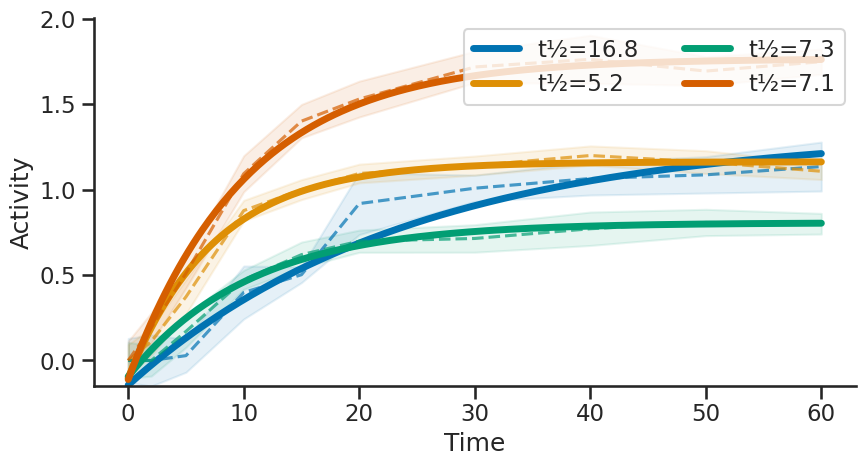

In [53]:
plt.figure(dpi=300)

def rising_exponential(t, A, k, C):
    return A * (1 - np.exp(-k * t)) + C

t_fine = np.linspace(0, max_time, 300)
fig, ax = plt.subplots(figsize=(9,5))

colors = sns.color_palette('colorblind', n_colors=len(to_plot))

for (_, row), color in zip(to_plot.iterrows(), colors):
    grp = activities_norm[activities_norm['ADseq'] == row['ADseq']].sort_values('time')
    t = grp['time'].values
    y = grp['activity_norm'].values
    sigma = grp['error'].values

    ax.fill_between(t, y - sigma, y + sigma, color=color, alpha=0.1)
    ax.plot(t, y, color=color, markersize=4, alpha=0.7, linestyle='dashed')
    ax.plot(t_fine, rising_exponential(t_fine, row['A'], row['k'], row['C']),
            color=color, linewidth=5, alpha=1,
            label=f"t½={row['t_half']:.1f}")

ax.set_xlabel('Time')
ax.set_ylabel('Activity')

# get lowest observed value across all plotted sequences
grps = activities_norm[activities_norm['ADseq'].isin(to_plot['ADseq'])]
y_min = (grps['activity_norm'] - grps['error']).min()
ax.set_ylim(bottom=y_min)

# Add legend outside the plot
ax.legend(bbox_to_anchor=(1,1), loc='upper right', ncols = 2)
sns.despine()
plt.tight_layout()
plt.show()

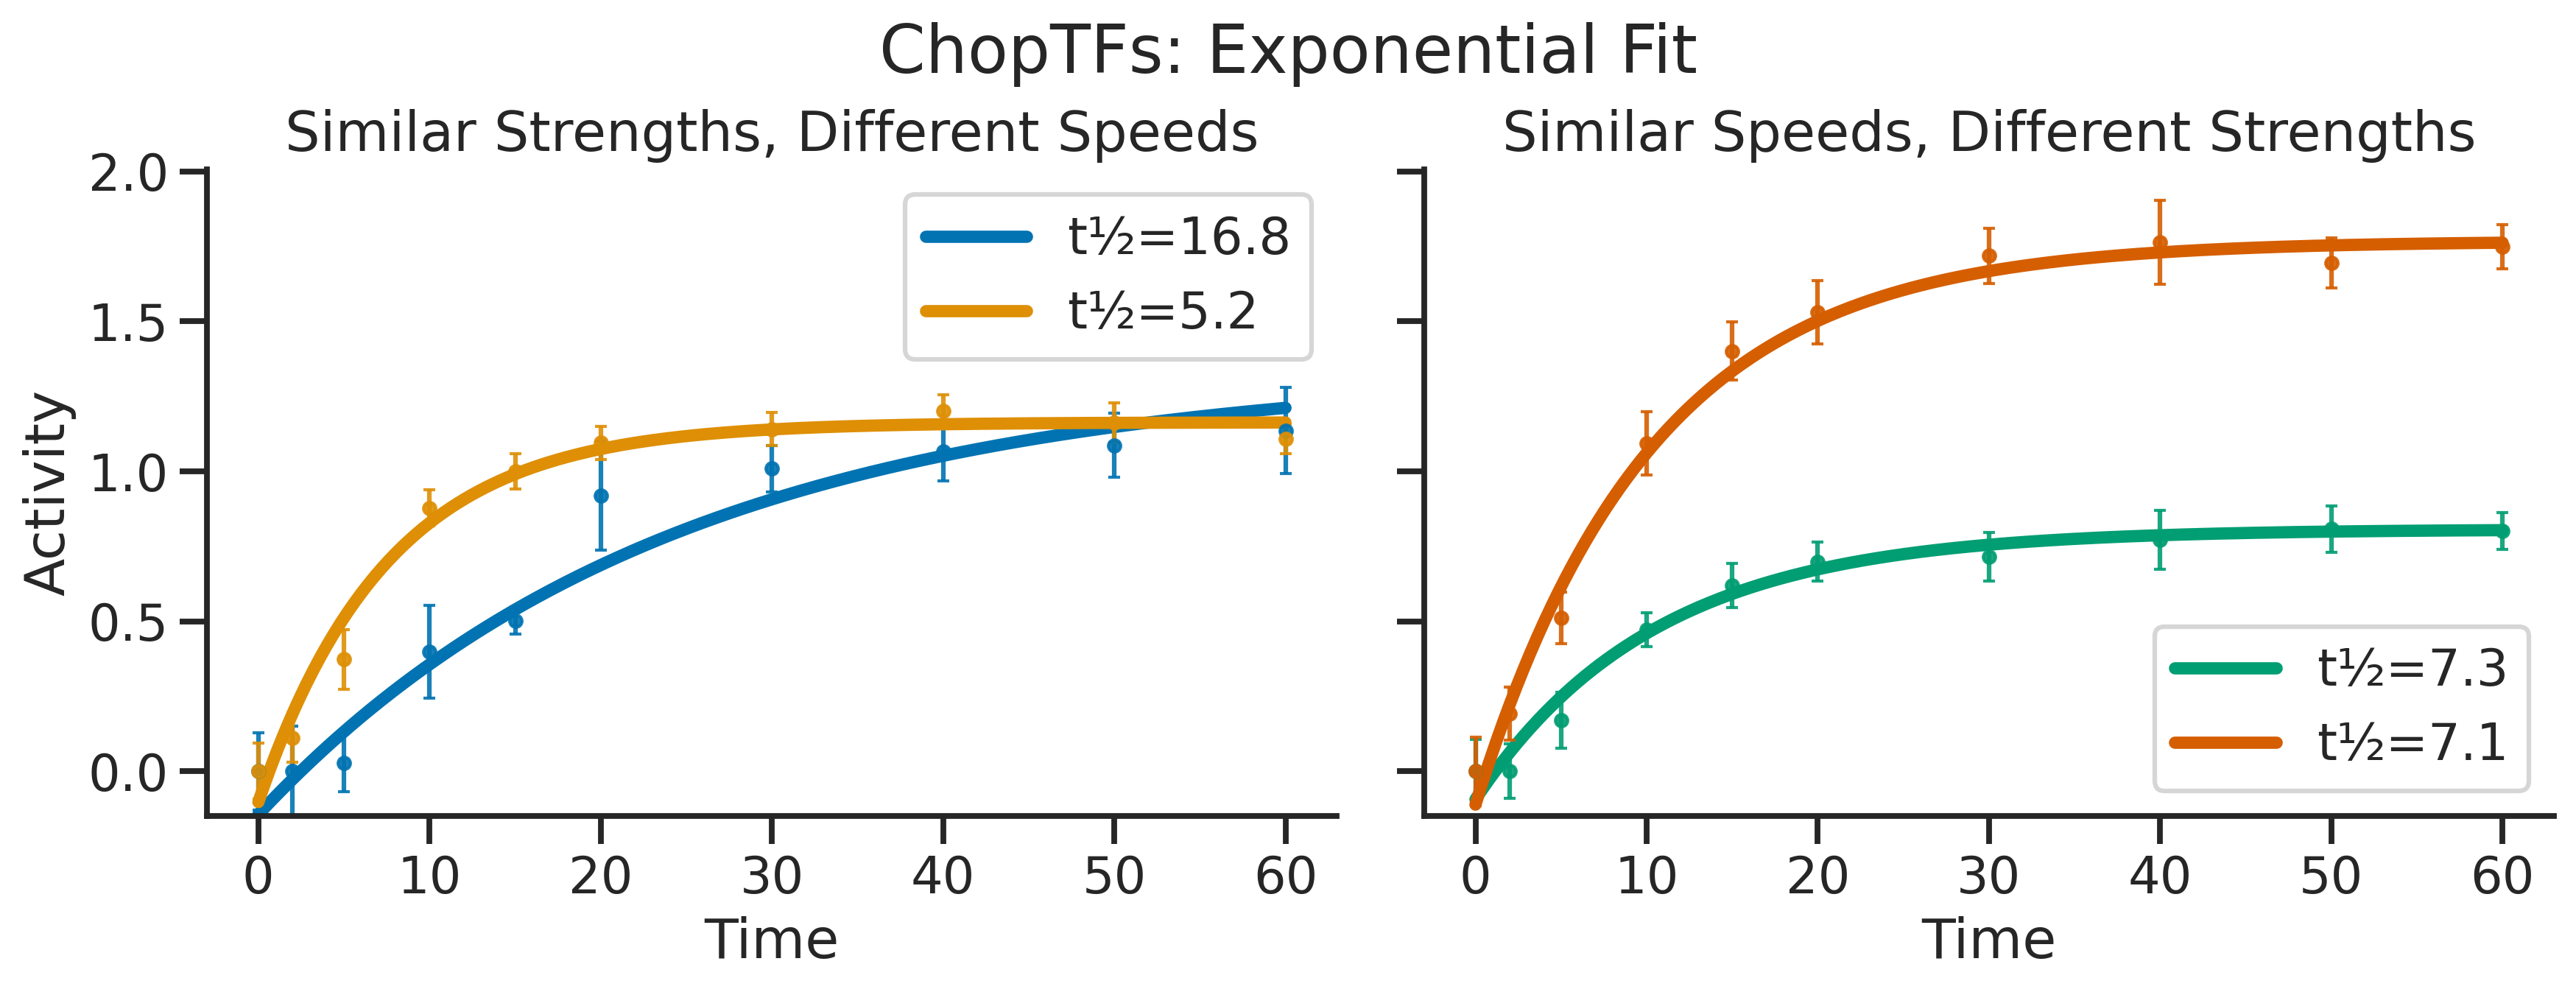

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def rising_exponential(t, A, k, C):
    return A * (1 - np.exp(-k * t)) + C

t_fine = np.linspace(0, max_time, 300)

fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True, dpi=300)

colors = sns.color_palette('colorblind', n_colors=len(to_plot))

# --- first subplot: sequences 1 and 3 ---
for idx in [0, 1]:

    row = to_plot.iloc[idx]
    grp = activities_norm[activities_norm['ADseq'] == row['ADseq']].sort_values('time')

    t = grp['time'].values
    y = grp['activity_norm'].values
    sigma = grp['error'].values

    axs[0].errorbar(
        t, y, yerr=sigma,
        fmt='o',
        color=colors[idx],
        ecolor=colors[idx],
        elinewidth=1.5,
        capsize=2,
        markersize=4,
        alpha=0.9
    )

    axs[0].plot(
        t_fine,
        rising_exponential(t_fine, row['A'], row['k'], row['C']),
        color=colors[idx],
        linewidth=4,
        alpha=1,
        label=f"t½={row['t_half']:.1f}"
    )

axs[0].set_xlabel('Time')
axs[0].set_ylabel('Activity')
axs[0].legend()
sns.despine(ax=axs[0])
axs[0].set_title("Similar Strengths, Different Speeds")

# --- second subplot: sequences 2 and 4 ---
for idx in [2, 3]:

    row = to_plot.iloc[idx]
    grp = activities_norm[activities_norm['ADseq'] == row['ADseq']].sort_values('time')

    t = grp['time'].values
    y = grp['activity_norm'].values
    sigma = grp['error'].values

    axs[1].errorbar(
        t, y, yerr=sigma,
        fmt='o',
        color=colors[idx],
        ecolor=colors[idx],
        elinewidth=1.5,
        capsize=2,
        markersize=4,
        alpha=0.9
    )

    axs[1].plot(
        t_fine,
        rising_exponential(t_fine, row['A'], row['k'], row['C']),
        color=colors[idx],
        linewidth=4,
        alpha=1,
        label=f"t½={row['t_half']:.1f}"
    )

axs[1].set_xlabel('Time')
axs[1].legend()
sns.despine(ax=axs[1])

# --- shared y-axis scaling ---
grps = activities_norm[activities_norm['ADseq'].isin(to_plot['ADseq'])]
y_min = (grps['activity_norm'] - grps['error']).min()

for ax in axs:
    ax.set_ylim(bottom=y_min)

axs[1].set_title("Similar Speeds, Different Strengths")

plt.suptitle("ChopTFs: Exponential Fit", y=0.912)
plt.tight_layout()
plt.show()

/tmp/ipykernel_175777/3182108259.py:118: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.1)


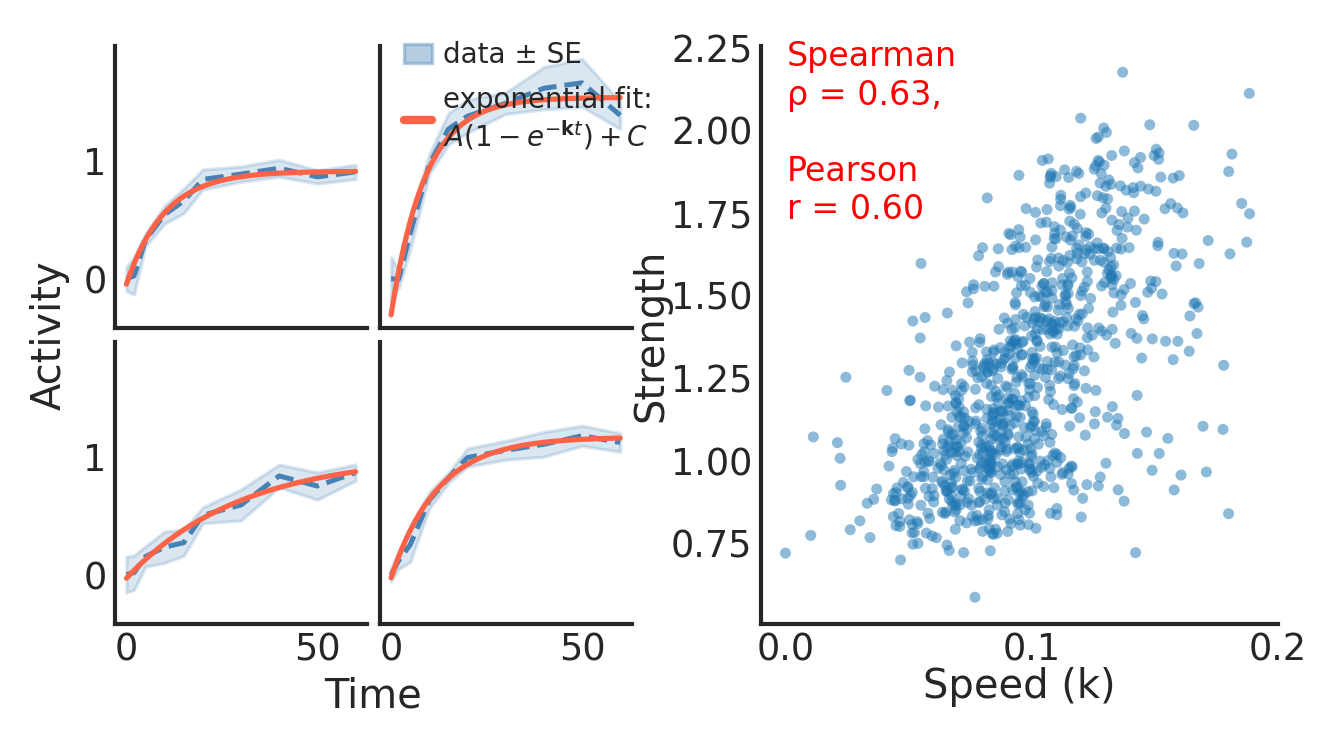

In [55]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
from scipy.stats import pearsonr, spearmanr

sns.set_context('paper')
sns.set_style('white')

def rising_exponential(t, A, k, C):
    return A * (1 - np.exp(-k * t)) + C

sample_adseqs = ok_norm.sample(4, random_state=92)['ADseq'].values
t_fine = np.linspace(0, activities_norm['time'].max(), 200)

pearson_corr, pearson_p   = pearsonr(ok_norm['k'], ok_norm['obs_max'])
spearman_corr, spearman_p = spearmanr(ok_norm['k'], ok_norm['obs_max'])

fig = plt.figure(figsize=(5,2.5), dpi=300)
outer_gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1], wspace=0.25, figure=fig)

inner_gs = gridspec.GridSpecFromSubplotSpec(
    2, 2, subplot_spec=outer_gs[0], wspace=0.05, hspace=0.05
)

axes_left = []
ax0 = fig.add_subplot(inner_gs[0, 0])
axes_left.append(ax0)
for r in range(2):
    for c in range(2):
        if r == 0 and c == 0:
            continue
        ax = fig.add_subplot(inner_gs[r, c], sharex=ax0, sharey=ax0)
        axes_left.append(ax)

for ax, adseq in zip(axes_left, sample_adseqs):
    grp = activities_norm[activities_norm['ADseq'] == adseq].sort_values('time')
    t     = grp['time'].values
    y     = grp['activity_norm'].values
    sigma = grp['error'].values
    row_fit = fit_results_norm[fit_results_norm['ADseq'] == adseq].iloc[0]
    A, k, C = row_fit['A'], row_fit['k'], row_fit['C']

    ax.fill_between(t, y - sigma, y + sigma, color='steelblue', alpha=0.2)
    ax.plot(t, y, color='steelblue', linestyle='dashed')
    ax.plot(t_fine, rising_exponential(t_fine, A, k, C), color='tomato', linewidth=1.25)
    
# hide inner tick labels
for ax in [axes_left[0], axes_left[1]]:
    ax.tick_params(labelbottom=False)
for ax in [axes_left[1], axes_left[3]]:
    ax.tick_params(labelleft=False)

# sup axis labels scoped to left block
left_bbox = outer_gs[0].get_position(fig)
fig.text(left_bbox.x0 + left_bbox.width / 2, left_bbox.y0 - 0.07,
         'Time', ha='center', va='top',
         fontsize=plt.rcParams['axes.labelsize'])
fig.text(left_bbox.x0 - 0.03, left_bbox.y0 + left_bbox.height / 2,
         'Activity', ha='right', va='center', rotation='vertical',
         fontsize=plt.rcParams['axes.labelsize'])

# legend
# data_patch = mpatches.Patch(color='steelblue', alpha=0.4, label='data ± SE')
# fit_line = mlines.Line2D([], [], color='tomato', linewidth=2,
#                           label='exponential fit:\n' + r'$A(1-e^{-\mathbf{k}t})+C$')
# axes_left[1].legend(handles=[data_patch, fit_line],
#                     loc='upper right', fontsize='small', bbox_to_anchor = (1.1,1.15), ncols = 2)

data_patch = mpatches.Patch(color='steelblue', alpha=0.4, label='data ± SE')
fit_line   = mlines.Line2D([], [], color='tomato', linewidth=2,
                            label='exponential fit:\n' + r'$A(1-e^{-\mathbf{k}t})+C$')

fig.legend(handles=[data_patch, fit_line],
           loc='upper right',
           bbox_to_anchor=(0.5,0.92),  # centered under 2x2
           fontsize='x-small',
           frameon=False,
           handlelength=1,
           columnspacing=0,
           handletextpad=0.4,
          labelspacing = 0.6)

# right scatter
ax_right = fig.add_subplot(outer_gs[1])
ax_right.scatter(ok_norm['k'], ok_norm['obs_max'], alpha=0.5, s=7, edgecolor='none')
ax_right.set_xlabel('Speed (k)', labelpad = -0.5)
ax_right.set_ylabel('Strength', labelpad = 0)

ax_right.text(0.05, 1.01,
              f'Spearman\nρ = {spearman_corr:.2f},\n\nPearson\nr = {pearson_corr:.2f}',
              transform=ax_right.transAxes, ha='left', va='top',
              fontsize='small', color = 'red')

# on one panel only (e.g. top-left), show the model equation
# axes_left[0].text(0.1,1,          # center of the panel
#     r'$\mathbf{A(1-e^{-kt})+C}$',
#     transform=axes_left[0].transAxes,
#     ha='left', va='top', fontsize='small', color='tomato')

# # on all panels, label k from the fit
# ax.text(0.05, 0.95, f'k = {k:.3f}',
#         transform=ax.transAxes, ha='left', va='top',
#         fontsize='x-small', color='tomato', fontweight='bold')

# tighten ticks on all left axes
for ax in axes_left:
    ax.tick_params(axis='x', pad=2, length=0)
    ax.tick_params(axis='y', pad=2, length=0)

# also on right
ax_right.tick_params(axis='x', pad=2, length=0)
ax_right.tick_params(axis='y', pad=2, length=0)
ax_right.set_xlim(-0.01, 0.2)
sns.despine(fig=fig)
plt.tight_layout(pad=0.1)
plt.show()